In [ ]:
# УСТАНОВКА БИБЛИОТЕК

!pip install -q py7zr imbalanced-learn PyWavelets xgboost scikit-posthocs statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.3/71.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.3/494.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 5.4 MB/s eta 0:00:00


In [ ]:
# ИМПОРТЫ

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Работа с Google Drive и архивами
from google.colab import drive
import py7zr
import os

# Вейвлеты (для дискретного вейвлет-преобразования)
import pywt

# Статистика (для сравнения моделей)
from scipy import stats
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Предобработка и масштабирование
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold

# Балансировка классов
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Модели
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Метрики
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, confusion_matrix,
                             classification_report)

# Монтируем Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ЗАГРУЗКА ДАННЫХ И ФИЛЬТРАЦИЯ ТОЛЬКО A2

# Путь к архиву (укажите свой)
archive_path = '/content/drive/MyDrive/eeg_dataset.7z'
extract_path = '/content/eeg_dataset_extracted'

if not os.path.exists(extract_path):
    with py7zr.SevenZipFile(archive_path, mode='r') as z:
        z.extractall(extract_path)
    print("Распаковано")
else:
    print("Папка уже есть")

csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]
csv_path = os.path.join(extract_path, csv_files[0])
df = pd.read_csv(csv_path)
print(f"Датасет загружен: {df.shape}")

Распаковано
Датасет загружен: (292930, 294)


# EDA

In [ ]:
# Список всех колонок
print("\nСписок всех колонок:")
print(df.columns.tolist())

# Типы данных и количество ненулевых значений
print("\nИнформация о датасете:")
df.info()


Список всех колонок:
['EEG F3-A2_delta_power', 'EEG F3-A2_theta_power', 'EEG F3-A2_alpha_power', 'EEG F3-A2_beta_power', 'EEG F3-A2_gamma_power', 'EEG F3-A2_delta_ratio', 'EEG F3-A2_theta_ratio', 'EEG F3-A2_alpha_ratio', 'EEG F3-A2_beta_ratio', 'EEG F3-A2_gamma_ratio', 'EEG F3-A2_slow_fast_ratio', 'EEG F3-A2_shannon_entropy', 'EEG F3-A2_mean', 'EEG F3-A2_std', 'EEG F3-A2_min', 'EEG F3-A2_max', 'EEG F3-A2_range', 'EEG F3-A2_rms', 'EEG F3-A2_cv', 'EEG F3-A2_skewness', 'EEG F3-A2_zc_rate', 'EEG F3-A2_mobility', 'EEG C3-A2_delta_power', 'EEG C3-A2_theta_power', 'EEG C3-A2_alpha_power', 'EEG C3-A2_beta_power', 'EEG C3-A2_gamma_power', 'EEG C3-A2_delta_ratio', 'EEG C3-A2_theta_ratio', 'EEG C3-A2_alpha_ratio', 'EEG C3-A2_beta_ratio', 'EEG C3-A2_gamma_ratio', 'EEG C3-A2_slow_fast_ratio', 'EEG C3-A2_shannon_entropy', 'EEG C3-A2_mean', 'EEG C3-A2_std', 'EEG C3-A2_min', 'EEG C3-A2_max', 'EEG C3-A2_range', 'EEG C3-A2_rms', 'EEG C3-A2_cv', 'EEG C3-A2_skewness', 'EEG C3-A2_zc_rate', 'EEG C3-A2_mobi

In [ ]:
# Получаем названия колонок типа object
object_columns = df.select_dtypes(include=['object']).columns.tolist()

# Получаем названия колонок типа int64
int64_columns = df.select_dtypes(include=['int64']).columns.tolist()

# Выводим результаты
print("Колонки типа object:", object_columns)
print("Колонки типа int64:", int64_columns)


Колонки типа object: ['filename']
Колонки типа int64: ['patient_id']


Основная часть колонок имеют тип float64

In [ ]:
# Базовая статистика для всех числовых колонок
df.describe()

,EEG F3-A2_delta_power,EEG F3-A2_theta_power,EEG F3-A2_alpha_power,EEG F3-A2_beta_power,EEG F3-A2_gamma_power,EEG F3-A2_delta_ratio,EEG F3-A2_theta_ratio,EEG F3-A2_alpha_ratio,EEG F3-A2_beta_ratio,EEG F3-A2_gamma_ratio,...,EEG O2-A2_mean,EEG O2-A2_std,EEG O2-A2_min,EEG O2-A2_max,EEG O2-A2_range,EEG O2-A2_rms,EEG O2-A2_cv,EEG O2-A2_skewness,EEG O2-A2_zc_rate,EEG O2-A2_mobility
count,2.727170e+05,2.727170e+05,2.727170e+05,2.727170e+05,2.727170e+05,272717.000000,272717.000000,272717.000000,272717.000000,2.727170e+05,...,1.233500e+04,1.233500e+04,1.233500e+04,1.233500e+04,1.233500e+04,1.233500e+04,1.233500e+04,12335.000000,12335.000000,12335.000000
mean,2.387968e-09,3.921994e-10,1.299295e-10,1.294843e-10,5.645213e-12,0.625244,0.162914,0.099853,0.104732,7.257644e-03,...,4.750564e-10,3.651046e-05,-2.256742e-04,2.084833e-04,4.341575e-04,3.651201e-05,4.101669e+04,-0.158750,0.078147,0.236982
std,1.911444e-08,3.332416e-09,1.062081e-09,1.049676e-09,4.224839e-11,0.194701,0.081700,0.072678,0.091822,1.307715e-02,...,9.045230e-07,9.362874e-05,6.027424e-04,6.061209e-04,1.166014e-03,9.363250e-05,1.776628e+06,1.813249,0.113784,0.262947
min,8.765517e-41,3.983034e-41,3.801111e-41,1.546376e-40,8.140679e-41,0.013436,0.000010,0.000009,0.000022,2.409179e-07,...,-1.919998e-05,1.410201e-17,-6.739148e-03,2.966463e-17,5.942621e-17,1.410201e-17,7.780741e+00,-27.892559,0.003733,0.008758
25%,1.792023e-11,6.014792e-12,3.225162e-12,2.900914e-12,7.941303e-14,0.510751,0.109285,0.051625,0.042054,1.201300e-03,...,-3.331577e-08,5.874080e-06,-9.898875e-05,2.640270e-05,4.984640e-05,5.874274e-06,1.514614e+02,-0.154731,0.039467,0.134955
50%,3.933315e-11,9.746952e-12,5.455621e-12,4.563749e-12,1.517113e-13,0.654149,0.152576,0.084762,0.078334,2.731610e-03,...,1.052396e-22,8.894380e-06,-3.818457e-05,3.987743e-05,7.844546e-05,8.894441e-06,3.129118e+02,0.063272,0.055600,0.192560
75%,9.097857e-11,1.737321e-11,9.967058e-12,8.442465e-12,4.894889e-13,0.771615,0.202080,0.127578,0.135842,7.060566e-03,...,3.256471e-08,1.997312e-05,-2.246498e-05,9.123269e-05,1.922695e-04,1.997318e-05,8.224656e+02,0.287621,0.078800,0.252316
max,8.630515e-07,2.986740e-07,6.021783e-08,3.918553e-08,1.795252e-09,0.999903,0.734258,0.737904,0.749145,6.096980e-01,...,1.943835e-05,1.276921e-03,-2.976158e-17,6.953142e-03,1.261060e-02,1.276921e-03,1.903131e+08,48.663999,0.800400,1.902228


Базовую сатитстику сложно интерпретировать из за большого количества колонок

In [ ]:
# Количество пропусков в каждой колонке
nan_counts = df.isnull().sum()
print("Колонки с пропусками (NaN):")
print(nan_counts[nan_counts > 0])

# Процент пропусков
nan_percent = (nan_counts / len(df)) * 100
print("\nПроцент пропусков в этих колонках:")
print(nan_percent[nan_percent > 0])

Колонки с пропусками (NaN):
EEG F3-A2_delta_power     20213
EEG F3-A2_theta_power     20213
EEG F3-A2_alpha_power     20213
EEG F3-A2_beta_power      20213
EEG F3-A2_gamma_power     20213
                          ...  
EEG O2-A2_rms            280595
EEG O2-A2_cv             280595
EEG O2-A2_skewness       280595
EEG O2-A2_zc_rate        280595
EEG O2-A2_mobility       280595
Length: 292, dtype: int64

Процент пропусков в этих колонках:
EEG F3-A2_delta_power     6.900283
EEG F3-A2_theta_power     6.900283
EEG F3-A2_alpha_power     6.900283
EEG F3-A2_beta_power      6.900283
EEG F3-A2_gamma_power     6.900283
                           ...    
EEG O2-A2_rms            95.789096
EEG O2-A2_cv             95.789096
EEG O2-A2_skewness       95.789096
EEG O2-A2_zc_rate        95.789096
EEG O2-A2_mobility       95.789096
Length: 292, dtype: float64


Колонки с -A1 заполнены только для ~4% эпох (14 файлов).  Колонки с -A2 заполнены для остальных 96% эпох (300 файлов). Однако в некоторых файлах (как в примере выше) одна половина отведений может быть с A2, другая — с A1. Соответственно попуски связаны с референсами, удалим колонки А1, так как их мало, на анализ не повлияет


In [ ]:
if 'artefact_count' in df.columns:
    artefact_epochs = df[df['artefact_count'] > 0].shape[0]
    total = df.shape[0]
    print(f"Эпох с артефактами: {artefact_epochs} из {total} ({artefact_epochs/total*100:.1f}%)")
else:
    print("Колонка 'artefact_count' не найдена.")

Эпох с артефактами: 7169 из 292930 (2.4%)


Удалим эпохи с артефактами - 2,4% на анализ не повляет, но улучшит чистоту, уберт выбросы и шум

Распределение has_apnea:
has_apnea
0.0    230607
1.0     54445
Name: count, dtype: int64
Доля апноэ: 19.1%


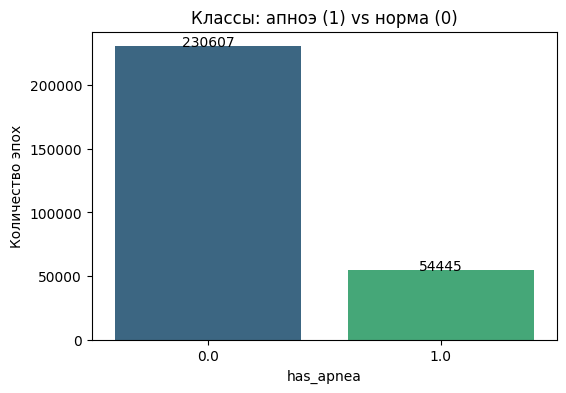

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['has_apnea'].value_counts()
print("Распределение has_apnea:")
print(counts)
print(f"Доля апноэ: {counts[1]/counts.sum()*100:.1f}%")

# График
plt.figure(figsize=(6,4))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.title('Классы: апноэ (1) vs норма (0)')
plt.xlabel('has_apnea')
plt.ylabel('Количество эпох')
for i, v in enumerate(counts.values):
    plt.text(i, v+100, str(v), ha='center')
plt.show()

При обучении на уровне эпох модель будет «видеть» много эпох без апноэ и мало с апноэ – дисбаланс. Дисбаланс умеренный, применим SMOTE или class_weight='balanced'. Необходимо использовать стратификацию при кросс-валидации (чтобы в каждой группе было одинаковое количество тяжёлых и лёгких пациентов).

=== РАСПРЕДЕЛЕНИЕ ПАЦИЕНТОВ ПО СТЕПЕНЯМ ТЯЖЕСТИ ===
severity
Тяжёлая (≥30)      135
Норма (AHI<5)      109
Средняя (15–30)     39
Лёгкая (5–15)       31
Name: count, dtype: int64

Всего пациентов: 314

Основные статистики AHI:
count    314.000000
mean      38.041822
std       45.448063
min        0.000000
25%        1.811095
50%       20.856347
75%       59.859950
max      204.060302
Name: AHI, dtype: float64


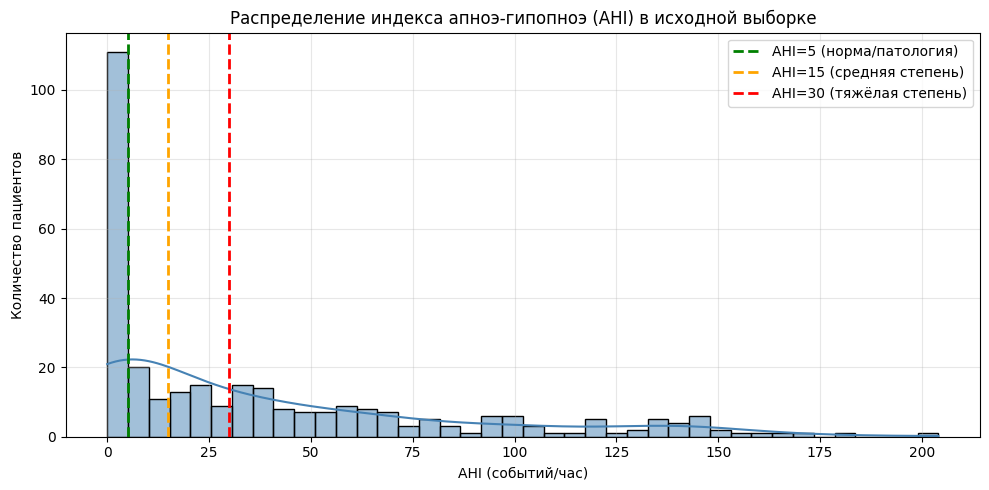

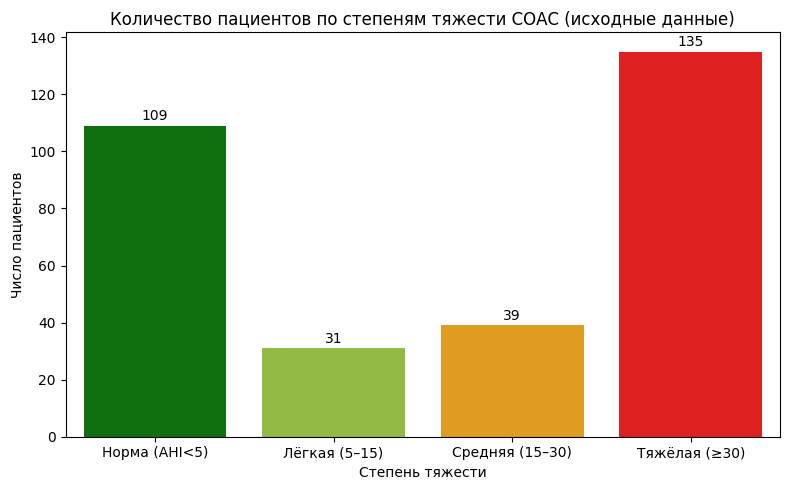

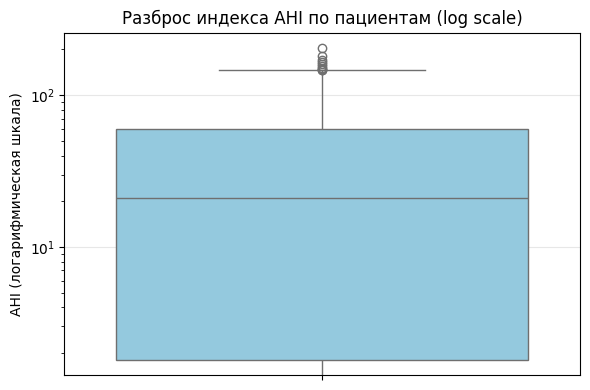


EDA по AHI завершён. Все графики сохранены.


In [ ]:
# =====================================================
# EDA: РАСЧЁТ AHI И РАСПРЕДЕЛЕНИЕ ПО СТЕПЕНЯМ ТЯЖЕСТИ
# (на исходном датасете, до очистки)
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Предполагается, что df уже загружен (как в вашем коде: df = pd.read_csv(csv_path))

# 1. Группируем по файлу (пациенту)
#    Суммируем количество апноэ и гипопноэ, считаем число эпох
patient_data = []
for name, group in df.groupby('filename'):
    # Используем сумму событий (апноэ + гипопноэ) – стандартный AHI
    total_apnea = group['apnea_count'].sum()
    total_hypopnea = group['hypopnea_count'].sum()
    total_events = total_apnea + total_hypopnea

    # Время сна в часах: число эпох (каждая 30 сек) / 3600 * 30? Уточним:
    # каждая эпоха = 30 сек => число эпох * 30 / 3600 = число эпох / 120
    n_epochs = len(group)
    sleep_hours = n_epochs * 30 / 3600.0
    if sleep_hours < 0.5:
        sleep_hours = 0.5  # минимальное время для корректного AHI (защита)

    ahi = total_events / sleep_hours
    patient_data.append({
        'filename': name,
        'AHI': ahi,
        'n_epochs': n_epochs,
        'n_apnea': total_apnea,
        'n_hypopnea': total_hypopnea
    })

df_ahi_eda = pd.DataFrame(patient_data)

# 2. Категории тяжести (по AHI)
def severity_cat(ahi):
    if ahi < 5:
        return 'Норма (AHI<5)'
    elif ahi < 15:
        return 'Лёгкая (5–15)'
    elif ahi < 30:
        return 'Средняя (15–30)'
    else:
        return 'Тяжёлая (≥30)'

df_ahi_eda['severity'] = df_ahi_eda['AHI'].apply(severity_cat)

# 3. Вывод статистики
print("=== РАСПРЕДЕЛЕНИЕ ПАЦИЕНТОВ ПО СТЕПЕНЯМ ТЯЖЕСТИ ===")
print(df_ahi_eda['severity'].value_counts())
print(f"\nВсего пациентов: {len(df_ahi_eda)}")
print("\nОсновные статистики AHI:")
print(df_ahi_eda['AHI'].describe())

# 4. Гистограмма AHI с порогами
plt.figure(figsize=(10,5))
sns.histplot(df_ahi_eda['AHI'], bins=40, kde=True, color='steelblue')
plt.axvline(5, color='green', linestyle='--', linewidth=2, label='AHI=5 (норма/патология)')
plt.axvline(15, color='orange', linestyle='--', linewidth=2, label='AHI=15 (средняя степень)')
plt.axvline(30, color='red', linestyle='--', linewidth=2, label='AHI=30 (тяжёлая степень)')
plt.xlabel('AHI (событий/час)')
plt.ylabel('Количество пациентов')
plt.title('Распределение индекса апноэ-гипопноэ (AHI) в исходной выборке')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ahi_histogram_eda.png', dpi=150)
plt.show()

# 5. Столбчатая диаграмма категорий
plt.figure(figsize=(8,5))
counts = df_ahi_eda['severity'].value_counts()
colors = {'Норма (AHI<5)': 'green',
          'Лёгкая (5–15)': 'yellowgreen',
          'Средняя (15–30)': 'orange',
          'Тяжёлая (≥30)': 'red'}
order = ['Норма (AHI<5)', 'Лёгкая (5–15)', 'Средняя (15–30)', 'Тяжёлая (≥30)']
sns.barplot(x=order, y=[counts.get(cat,0) for cat in order], palette=[colors[cat] for cat in order])
plt.title('Количество пациентов по степеням тяжести СОАС (исходные данные)')
plt.xlabel('Степень тяжести')
plt.ylabel('Число пациентов')
for i, v in enumerate([counts.get(cat,0) for cat in order]):
    plt.text(i, v+2, str(v), ha='center')
plt.tight_layout()
plt.savefig('severity_barplot_eda.png', dpi=150)
plt.show()

# 6. Дополнительно: ящик с усами для AHI (логарифмическая шкала, чтобы видеть распределение)
plt.figure(figsize=(6,4))
sns.boxplot(y=df_ahi_eda['AHI'], color='skyblue')
plt.yscale('log')
plt.ylabel('AHI (логарифмическая шкала)')
plt.title('Разброс индекса AHI по пациентам (log scale)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ahi_boxplot_log.png', dpi=150)
plt.show()

print("\nEDA по AHI завершён. Все графики сохранены.")

Разведывательный анализ распределения индекса AHI выявил сильную положительную асимметрию (среднее 38.0, медиана 20.9), наличие экстремальных выбросов (макс. 204) и дисбаланс категорий тяжести: лёгкая и средняя степени составили лишь 22% выборки. Эти факты обосновывают использование робастного масштабирования (RobustScaler), балансировки классов и объединение лёгкой и средней степеней в одну группу для мультиклассовой задачи, а также переход от классификации эпох к классификации пациентов как основного результата работы.

In [ ]:
# Шаг 1. Очистка данных: оставляем только A2-колонки, удаляем эпохи без A2 (нули) и эпохи с артефактами

# Список всех A2-колонок
a2_cols = [col for col in df.columns if '-A2_' in col]

# Служебные колонки (не признаки ЭЭГ)
non_eeg_cols = ['sleep_stage', 'apnea_count', 'hypopnea_count', 'snore_count', 'desaturation_count',
                'tachycardia_count', 'leg_movement_count', 'periodic_leg_movement_count', 'bruxism_count',
                'activation_count', 'k_complex_count', 'sleep_spindle_count', 'artefact_count',
                'has_apnea', 'has_hypopnea', 'has_desaturation', 'has_snore', 'has_bruxism',
                'has_activation', 'epoch_idx', 'start_time', 'end_time', 'patient_id', 'has_k_complex',
                'has_leg_movement', 'has_periodic_leg_movement', 'has_sleep_spindle', 'has_artefact',
                'filename', 'has_tachycardia']

# Оставляем только A2-колонки и служебные
keep_cols = a2_cols + [col for col in non_eeg_cols if col in df.columns]
df_a2 = df[keep_cols].copy()
print(f"После выбора A2-колонок и служебных: {df_a2.shape}")

# Проверяем, какие A2-колонки полностью пустые (NaN)
nan_counts = df_a2[a2_cols].isna().sum()
full_nan_cols = nan_counts[nan_counts == len(df_a2)].index.tolist()
print(f"Колонки A2 с 100% пропусков: {len(full_nan_cols)}")
# Удаляем такие колонки (их нет, но на всякий случай)
df_a2.drop(columns=full_nan_cols, inplace=True, errors='ignore')

# Заменяем оставшиеся NaN на 0 (это файлы, где A2-каналы не были записаны)
df_a2[a2_cols] = df_a2[a2_cols].fillna(0)

# Удаляем эпохи, у которых все A2-признаки равны 0 (это те 14 файлов с A1)
non_zero_mask = (df_a2[a2_cols] != 0).any(axis=1)
df_a2_clean = df_a2[non_zero_mask].copy()
print(f"После удаления нулевых эпох (без A2): {df_a2_clean.shape}")

# Удаляем эпохи с артефактами
if 'artefact_count' in df_a2_clean.columns:
    before = len(df_a2_clean)
    df_a2_clean = df_a2_clean[df_a2_clean['artefact_count'] == 0].copy()
    after = len(df_a2_clean)
    removed = before - after
    print(f"Удалено эпох с артефактами: {removed} ({removed/before*100:.2f}%)")
else:
    print("Колонка artefact_count не найдена, пропускаем удаление")

print(f"Итоговый чистый датасет: {df_a2_clean.shape}")

После выбора A2-колонок и служебных: (292930, 162)
Колонки A2 с 100% пропусков: 0
После удаления нулевых эпох (без A2): (285052, 162)
Удалено эпох с артефактами: 7169 (2.51%)
Итоговый чистый датасет: (277883, 162)


In [ ]:
# Распределение классов после очистки
counts = df_a2_clean['has_apnea'].value_counts()
print("Распределение has_apnea:")
print(counts)
print(f"Соотношение: {counts[0]/counts[1]:.2f}:1")
print(f"Уникальных файлов (пациентов): {df_a2_clean['filename'].nunique()}")

Распределение has_apnea:
has_apnea
0.0    224542
1.0     53341
Name: count, dtype: int64
Соотношение: 4.21:1
Уникальных файлов (пациентов): 305


In [ ]:
# Проверяем, есть ли пропуски в целевой переменной 'has_apnea'
nan_count = df_a2_clean['has_apnea'].isna().sum()
print(f"Количество эпох с NaN в 'has_apnea': {nan_count}")

if nan_count > 0:
    print("Удаляем эти строки...")
    df_a2_clean = df_a2_clean.dropna(subset=['has_apnea']).copy()
    print(f"Размер после удаления: {df_a2_clean.shape}")
else:
    print("Пропусков нет, всё чисто.")

Количество эпох с NaN в 'has_apnea': 0
Пропусков нет, всё чисто.


Признаков ЭЭГ: 132


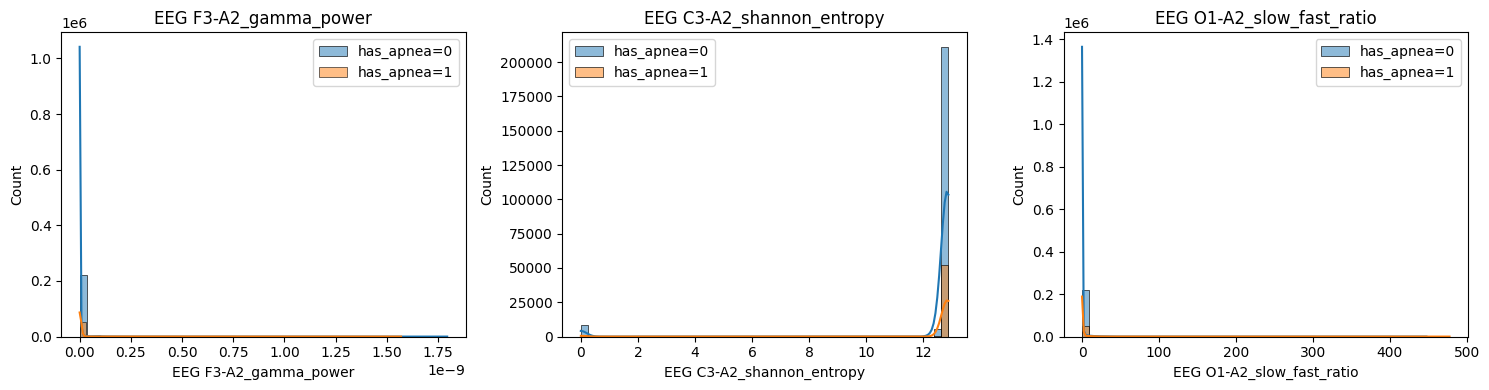

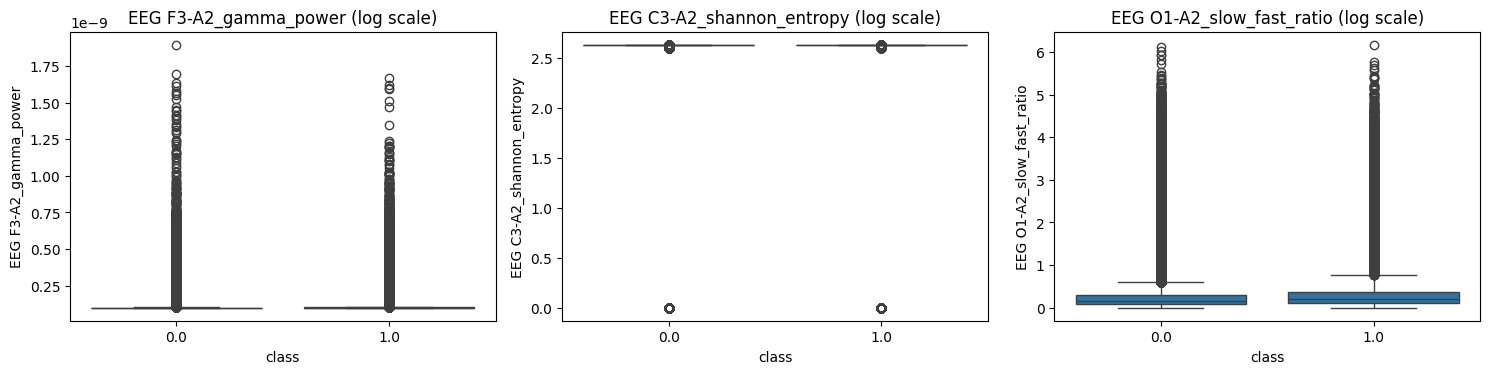


Топ-20 признаков по абсолютной корреляции с has_apnea:
                  feature  correlation  pvalue
EEG O1-A2_shannon_entropy     0.144890     0.0
EEG F3-A2_shannon_entropy     0.144684     0.0
    EEG O1-A2_gamma_power     0.129595     0.0
    EEG F3-A2_gamma_power     0.127092     0.0
    EEG C3-A2_gamma_power     0.120733     0.0
EEG C3-A2_shannon_entropy     0.116085     0.0
          EEG O1-A2_range     0.114117     0.0
     EEG F3-A2_beta_power     0.111301     0.0
            EEG O1-A2_max     0.110948     0.0
            EEG O1-A2_min    -0.109528     0.0
            EEG F3-A2_min    -0.099915     0.0
          EEG F3-A2_range     0.095823     0.0
     EEG O1-A2_beta_power     0.092342     0.0
            EEG F3-A2_max     0.090430     0.0
            EEG O1-A2_rms     0.089565     0.0
            EEG O1-A2_std     0.089559     0.0
            EEG C3-A2_max     0.085397     0.0
          EEG C3-A2_range     0.083370     0.0
    EEG F3-A2_gamma_ratio     0.082109     0.0
    

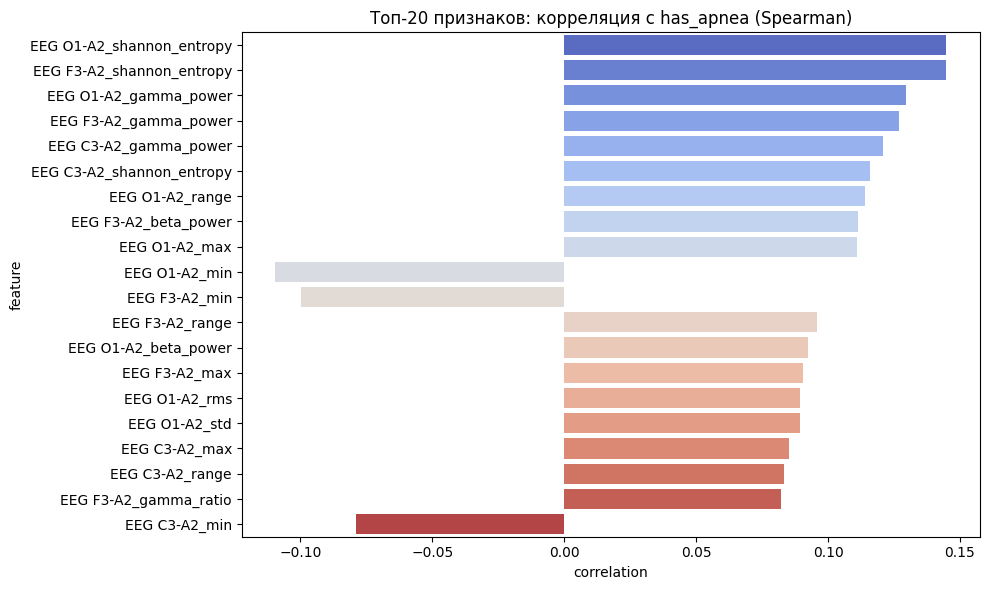

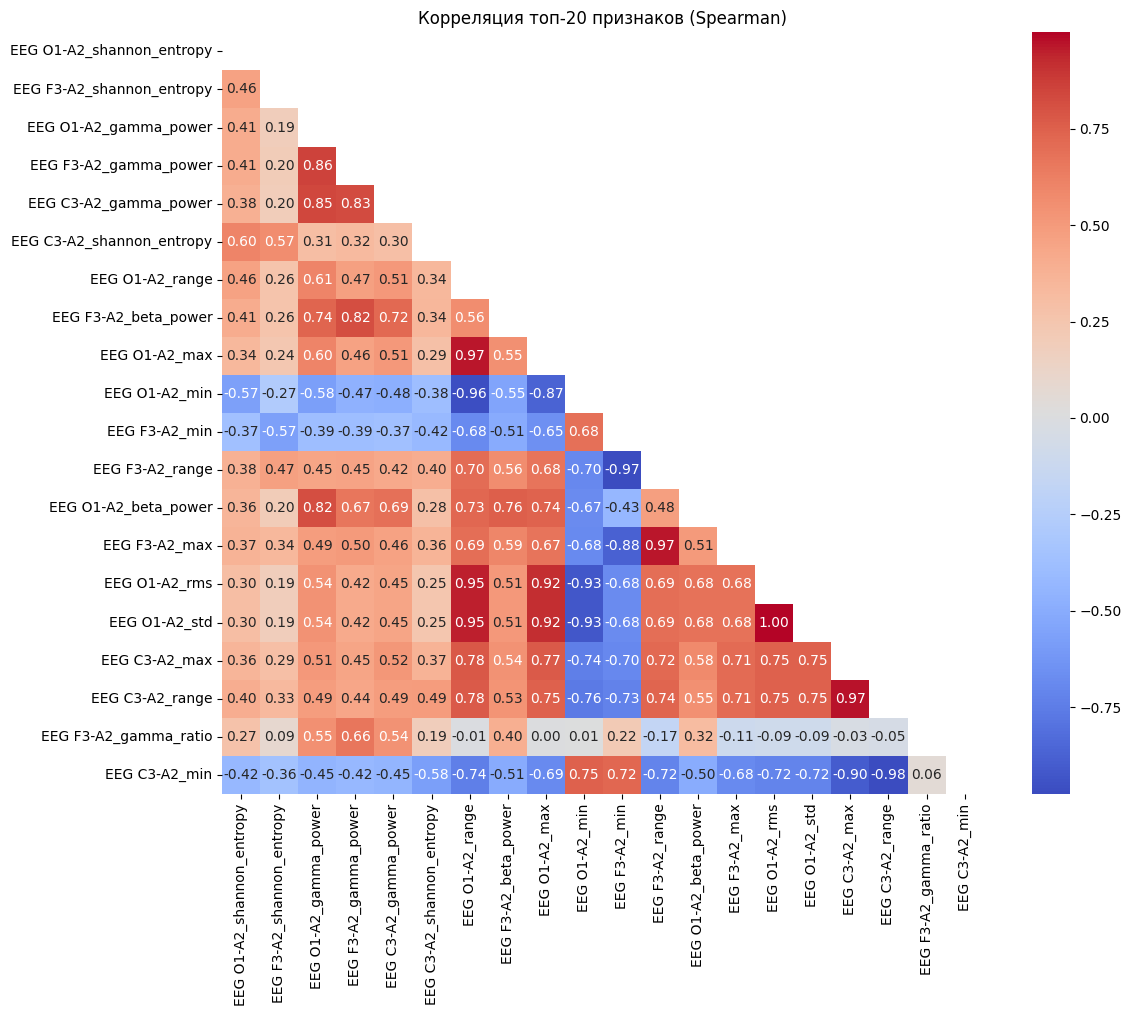


Статистика по файлам (пациентам):
          n_epochs     p_apnea
count   305.000000  305.000000
mean    911.091803    0.196373
std     169.375570    0.242270
min       6.000000    0.000000
25%     850.000000    0.006276
50%     935.000000    0.095281
75%    1019.000000    0.305213
max    1244.000000    0.965829


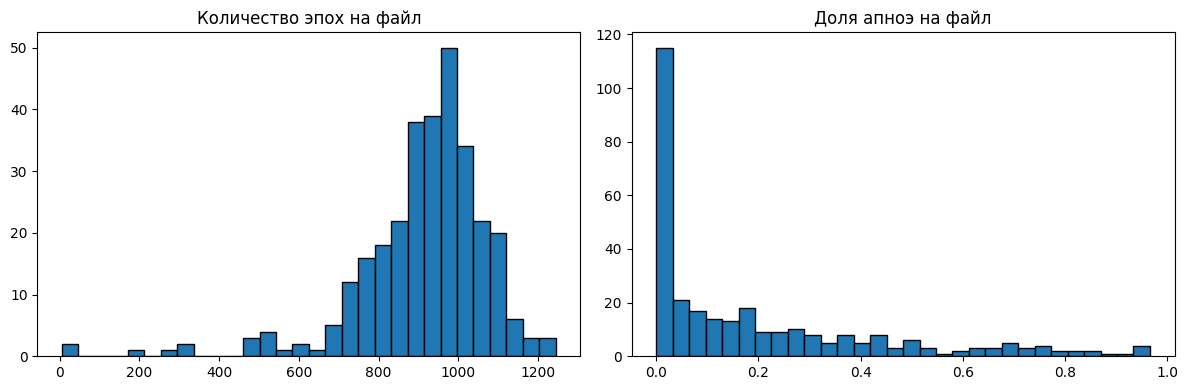

In [ ]:
# АНАЛИЗ ОЧИЩЕННОГО ДАТАСЕТА (БЕЗ АРТЕФАКТОВ И A1)

# Предполагается, что df_a2_clean уже существует (277883 строк)

# 1. Отделяем признаки (все A2-колонки, которые начинаются с 'EEG')
feature_cols = [c for c in df_a2_clean.columns if c.startswith('EEG') and '-A2_' in c]
print(f"Признаков ЭЭГ: {len(feature_cols)}")  # Должно быть 132

# Целевая переменная
y = df_a2_clean['has_apnea'].values

# Служебные колонки (для группировки и анализа)
filename = df_a2_clean['filename'].values
sleep_stage = df_a2_clean['sleep_stage'].values

# Данные признаков
X = df_a2_clean[feature_cols].copy()

# 2. Гистограммы распределения нескольких ключевых признаков по классам
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Выберем 3 признака: гамма (лобная), энтропия (центральная), медленно-быстрое (затылочная)
selected_features = [
    'EEG F3-A2_gamma_power',
    'EEG C3-A2_shannon_entropy',
    'EEG O1-A2_slow_fast_ratio'
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, selected_features):
    for class_val in [0,1]:
        subset = X[y == class_val][feat]
        sns.histplot(subset, bins=50, alpha=0.5, label=f'has_apnea={class_val}', ax=ax, kde=True)
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.show()

# 3. Boxplot для выбросов (на логарифмической шкале, чтобы увидеть различия)
# Логарифмируем значения (добавляем 1e-10, чтобы избежать log(0))
X_log = np.log1p(X[selected_features] + 1e-10)
X_log['class'] = y
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, selected_features):
    sns.boxplot(x='class', y=feat, data=X_log, ax=ax)
    ax.set_title(f'{feat} (log scale)')
plt.tight_layout()
plt.show()

# 4. Корреляция с целевой переменной (Spearman)
from scipy.stats import spearmanr
correlations = []
for col in feature_cols:
    corr, p = spearmanr(X[col], y)
    correlations.append((col, corr, p))
corr_df = pd.DataFrame(correlations, columns=['feature', 'correlation', 'pvalue'])
corr_df = corr_df.sort_values('correlation', key=abs, ascending=False)
print("\nТоп-20 признаков по абсолютной корреляции с has_apnea:")
print(corr_df.head(20).to_string(index=False))

# График топ-20
plt.figure(figsize=(10,6))
top20 = corr_df.head(20)
sns.barplot(y='feature', x='correlation', data=top20, palette='coolwarm')
plt.title('Топ-20 признаков: корреляция с has_apnea (Spearman)')
plt.tight_layout()
plt.show()

# 5. Матрица корреляции для топ-20 признаков (тепловая карта)
top20_features = corr_df.head(20)['feature'].tolist()
X_top20 = X[top20_features]
corr_matrix = X_top20.corr(method='spearman')
plt.figure(figsize=(12,10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляция топ-20 признаков (Spearman)')
plt.tight_layout()
plt.show()

# 6. Анализ групп (файлов): сколько эпох на файл, доля апноэ
group_stats = df_a2_clean.groupby('filename').agg(
    n_epochs=('has_apnea', 'count'),
    n_apnea=('has_apnea', 'sum'),
    p_apnea=('has_apnea', 'mean')
).reset_index()
print("\nСтатистика по файлам (пациентам):")
print(group_stats[['n_epochs', 'p_apnea']].describe())

# Гистограммы
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(group_stats['n_epochs'], bins=30, edgecolor='k')
axes[0].set_title('Количество эпох на файл')
axes[1].hist(group_stats['p_apnea'], bins=30, edgecolor='k')
axes[1].set_title('Доля апноэ на файл')
plt.tight_layout()
plt.show()

In [ ]:
# Для выбранного признака, например, 'EEG O1-A2_shannon_entropy'
feat = 'EEG O1-A2_shannon_entropy'
for class_val in [0,1]:
    subset = X[y == class_val][feat]
    print(f"Класс {class_val}:")
    print(f"  Среднее = {subset.mean():.6f}")
    print(f"  Медиана = {subset.median():.6f}")
    print(f"  Стандартное отклонение = {subset.std():.6f}")
    print(f"  Минимум = {subset.min():.6f}, максимум = {subset.max():.6f}")

Класс 0:
  Среднее = 12.345160
  Медиана = 12.820158
  Стандартное отклонение = 2.406055
  Минимум = 0.000000, максимум = 12.872182
Класс 1:
  Среднее = 12.577999
  Медиана = 12.829727
  Стандартное отклонение = 1.773052
  Минимум = 0.000000, максимум = 12.871974


In [ ]:
feat = 'EEG O1-A2_shannon_entropy'
for class_val in [0,1]:
    subset = X[y == class_val][feat]
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    outliers = sum((subset < lower) | (subset > upper))
    print(f"Класс {class_val}: медиана={subset.median():.4f}, IQR={iqr:.4f}, выбросов={outliers} ({outliers/len(subset)*100:.1f}%)")

Класс 0: медиана=12.8202, IQR=0.0336, выбросов=14192 (6.3%)
Класс 1: медиана=12.8297, IQR=0.0321, выбросов=1662 (3.1%)


In [ ]:
# Вывести матрицу корреляции в виде текстовой таблицы
corr_matrix = X[top20_features].corr(method='spearman')
print(corr_matrix.to_string())

                           EEG O1-A2_shannon_entropy  EEG F3-A2_shannon_entropy  EEG O1-A2_gamma_power  EEG F3-A2_gamma_power  EEG C3-A2_gamma_power  EEG C3-A2_shannon_entropy  EEG O1-A2_range  EEG F3-A2_beta_power  EEG O1-A2_max  EEG O1-A2_min  EEG F3-A2_min  EEG F3-A2_range  EEG O1-A2_beta_power  EEG F3-A2_max  EEG O1-A2_rms  EEG O1-A2_std  EEG C3-A2_max  EEG C3-A2_range  EEG F3-A2_gamma_ratio  EEG C3-A2_min
EEG O1-A2_shannon_entropy                   1.000000                   0.461025               0.407525               0.412066               0.382985                   0.603363         0.463838              0.408685       0.338435      -0.572939      -0.366003         0.377688              0.357666       0.373082       0.298099       0.298091       0.357195         0.399059               0.273487      -0.424459
EEG F3-A2_shannon_entropy                   0.461025                   1.000000               0.185439               0.201969               0.195496                   0.566

Наиболее информативными для детекции апноэ оказались энтропия Шеннона и гамма-мощность в затылочных и лобных отведениях, что согласуется с современными исследованиями [Zaidi et al., 2025; Zaiyu, 2025]. Амплитудные признаки (_min, _max, _range) также вносят вклад, но их диагностическая ценность ниже.Доля апноэ: среднее 0.196 (19.6%) — соответствует общей доле в датасете, огромный разброс- от 0% (пациенты без апноэ) до 96.6% (тяжёлые формы), медиана 0.095 (9.5%) — половина пациентов имеют долю апноэ менее 10%, 25% пациентов имеют долю апноэ менее 0.6% — это лёгкие формы или здоровые.

Вывод: При обучении на уровне эпох модель может сместиться в сторону «нормы», так как большинство эпох — без апноэ. Но при агрегации на пациента (бинарная классификация AHI≥5) этот дисбаланс может быть не таким сильным.

In [ ]:
print(df_a2_clean[[c for c in df_a2_clean.columns if 'EEG' in c]].describe().loc[['mean','std']])

      EEG F3-A2_delta_power  EEG F3-A2_theta_power  EEG F3-A2_alpha_power  \
mean           2.261168e-09           3.713640e-10           1.227161e-10   
std            1.873318e-08           3.259949e-09           1.032907e-09   

      EEG F3-A2_beta_power  EEG F3-A2_gamma_power  EEG F3-A2_delta_ratio  \
mean          1.217066e-10           5.259244e-12               0.605507   
std           1.019932e-09           4.083324e-11               0.219961   

      EEG F3-A2_theta_ratio  EEG F3-A2_alpha_ratio  EEG F3-A2_beta_ratio  \
mean               0.158121               0.096751              0.099580   
std                0.085579               0.073847              0.088794   

      EEG F3-A2_gamma_ratio  ...  EEG O2-A2_mean  EEG O2-A2_std  \
mean               0.006746  ...    5.838130e-11   8.255100e-07   
std                0.012453  ...    1.429367e-07   1.484813e-05   

      EEG O2-A2_min  EEG O2-A2_max  EEG O2-A2_range  EEG O2-A2_rms  \
mean      -0.000005       0.000005    

Размер df_a2_clean: (277883, 162)
Число признаков: 132
Размер подвыборки: (30000, 132)
Первая компонента объясняет 23.6% дисперсии
Первые две компоненты: 39.3%
Для 80% дисперсии нужно 16 компонент


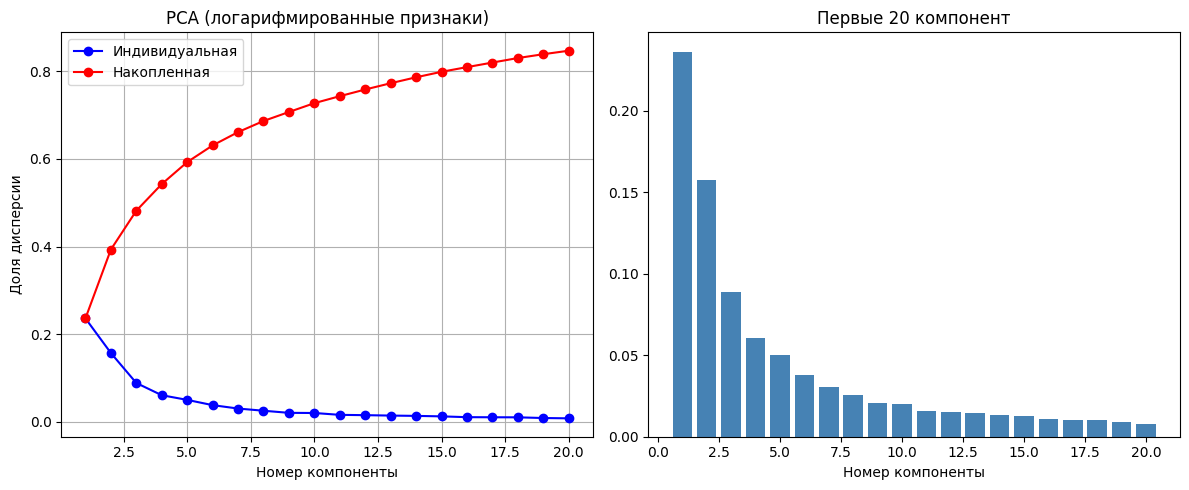

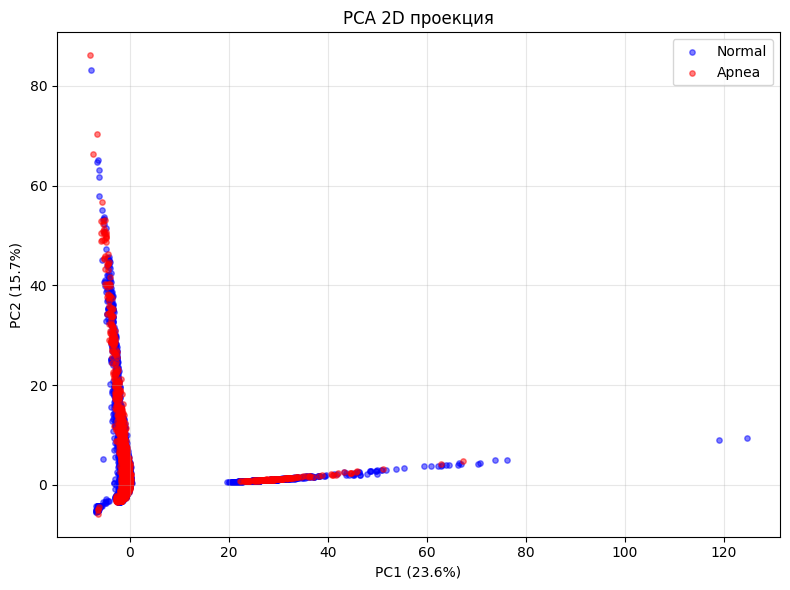


=== ТОП-20 ПРИЗНАКОВ ПО ВКЛАДУ В PC1 ===
                  feature   loading
EEG F4-A2_shannon_entropy  0.171205
EEG O2-A2_shannon_entropy  0.171197
EEG O1-A2_shannon_entropy -0.171196
EEG C4-A2_shannon_entropy  0.171196
EEG F3-A2_shannon_entropy -0.171188
EEG C3-A2_shannon_entropy -0.171186
             EEG C4-A2_cv  0.169367
             EEG O2-A2_cv  0.169343
             EEG F4-A2_cv  0.167966
    EEG F4-A2_delta_ratio  0.164966
    EEG O2-A2_delta_ratio  0.162923
    EEG C4-A2_delta_ratio  0.160632
    EEG C4-A2_theta_ratio  0.152528
    EEG O2-A2_theta_ratio  0.151324
    EEG F4-A2_theta_ratio  0.151042
       EEG O2-A2_mobility  0.148712
       EEG C4-A2_mobility  0.148412
       EEG F4-A2_mobility  0.145451
     EEG O2-A2_beta_ratio  0.142321
     EEG C4-A2_beta_ratio  0.140147


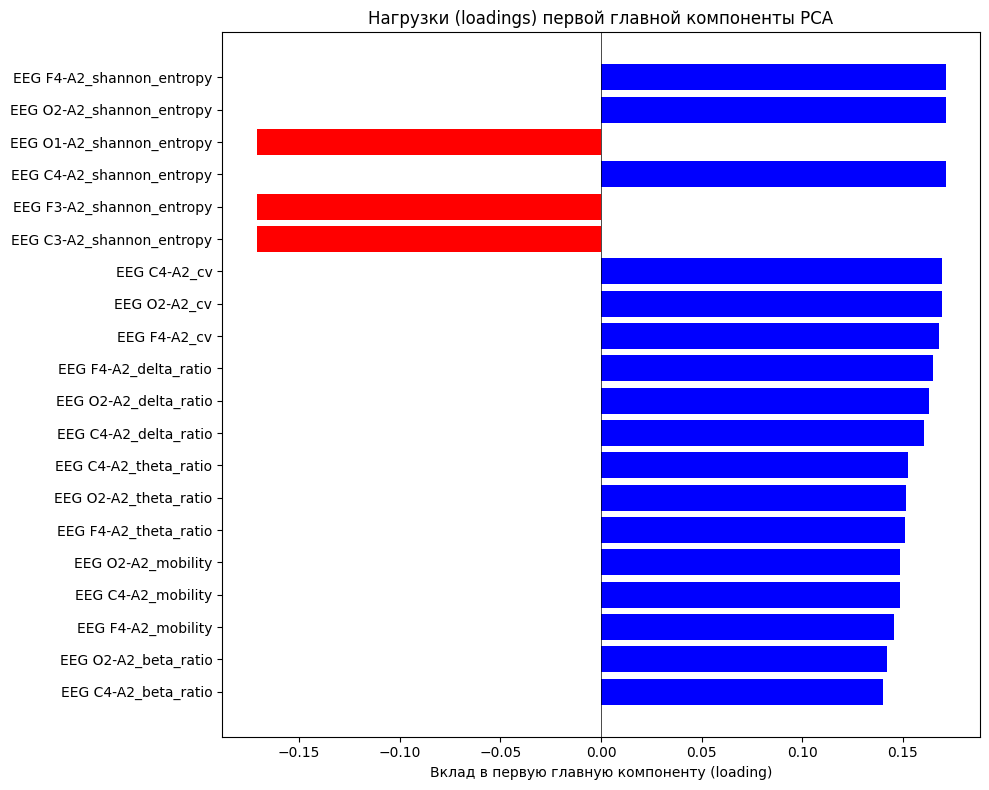


Таблицы и графики сохранены.


In [ ]:
# =====================================================
# ПОЛНЫЙ КОД PCA С LOADINGS (РАБОТАЕТ НА df_a2_clean)
# =====================================================
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Предполагается, что df_a2_clean уже загружен
print(f"Размер df_a2_clean: {df_a2_clean.shape}")

# 1. Отбираем A2-признаки
feature_cols = [c for c in df_a2_clean.columns if c.startswith('EEG') and '-A2_' in c]
X_full = df_a2_clean[feature_cols].copy()
print(f"Число признаков: {X_full.shape[1]}")

# 2. Подвыборка (для ускорения)
sample_size = min(30000, len(X_full))
df_sample = X_full.sample(sample_size, random_state=42)
y_sample = df_a2_clean.loc[df_sample.index, 'has_apnea'].values
print(f"Размер подвыборки: {df_sample.shape}")

# 3. Логарифмирование
X_log = np.log1p(df_sample + 1e-10)

# 4. Импутация (замена NaN медианой)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_log)

# 5. Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 6. PCA (объяснённая дисперсия, проекция)
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_
cumsum = np.cumsum(explained_var)

print(f"Первая компонента объясняет {explained_var[0]*100:.1f}% дисперсии")
print(f"Первые две компоненты: {cumsum[1]*100:.1f}%")
print(f"Для 80% дисперсии нужно {np.argmax(cumsum>=0.8)+1} компонент")

# 7. График дисперсии
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1,21), explained_var[:20], 'bo-', label='Индивидуальная')
plt.plot(range(1,21), cumsum[:20], 'ro-', label='Накопленная')
plt.xlabel('Номер компоненты')
plt.ylabel('Доля дисперсии')
plt.title('PCA (логарифмированные признаки)')
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
plt.bar(range(1,21), explained_var[:20], color='steelblue')
plt.xlabel('Номер компоненты')
plt.title('Первые 20 компонент')
plt.tight_layout()
plt.show()

# 8. 2D проекция
plt.figure(figsize=(8,6))
plt.scatter(X_pca[y_sample==0,0], X_pca[y_sample==0,1],
            c='blue', alpha=0.5, s=15, label='Normal')
plt.scatter(X_pca[y_sample==1,0], X_pca[y_sample==1,1],
            c='red', alpha=0.5, s=15, label='Apnea')
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
plt.title('PCA 2D проекция')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 9. LOADINGS (вклады признаков) для первой компоненты
feature_names = feature_cols  # список имён признаков
loadings = pca.components_[0]      # веса для PC1
loadings_df = pd.DataFrame({'feature': feature_names, 'loading': loadings})
loadings_df['abs_loading'] = np.abs(loadings_df['loading'])
loadings_df = loadings_df.sort_values('abs_loading', ascending=False)

print("\n=== ТОП-20 ПРИЗНАКОВ ПО ВКЛАДУ В PC1 ===")
top20 = loadings_df.head(20)
print(top20[['feature', 'loading']].to_string(index=False))
top20.to_csv('pca_loadings_top20.csv', index=False)

# Горизонтальная диаграмма
plt.figure(figsize=(10,8))
colors = ['red' if x < 0 else 'blue' for x in top20['loading']]
plt.barh(top20['feature'], top20['loading'], color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Вклад в первую главную компоненту (loading)')
plt.title('Нагрузки (loadings) первой главной компоненты PCA')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('pca_loadings_top20.png', dpi=150)
plt.show()

print("\nТаблицы и графики сохранены.")


=== ТОП-20 ПРИЗНАКОВ ПО ВКЛАДУ В PC2 ===
              feature   loading
        EEG F3-A2_rms  0.193439
        EEG F3-A2_std  0.193439
        EEG O1-A2_std  0.185832
        EEG O1-A2_rms  0.185832
      EEG F3-A2_range  0.185774
      EEG O1-A2_range  0.184510
        EEG F3-A2_min -0.183788
        EEG O1-A2_max  0.179320
        EEG O1-A2_min -0.177912
        EEG C3-A2_std  0.177730
        EEG C3-A2_rms  0.177729
      EEG C3-A2_range  0.176539
        EEG F3-A2_max  0.175867
EEG F3-A2_delta_power  0.175705
EEG F3-A2_theta_power  0.172931
        EEG C3-A2_max  0.171938
EEG C3-A2_theta_power  0.170109
EEG C3-A2_delta_power  0.168976
        EEG C3-A2_min -0.168941
EEG C3-A2_alpha_power  0.168827

=== ТОП-20 ПРИЗНАКОВ ПО ВКЛАДУ В PC3 ===
                  feature   loading
            EEG O2-A2_rms  0.206568
            EEG O2-A2_std  0.206567
    EEG O2-A2_delta_power  0.205036
          EEG O2-A2_range  0.194927
            EEG O2-A2_min -0.194646
    EEG O2-A2_theta_power  0

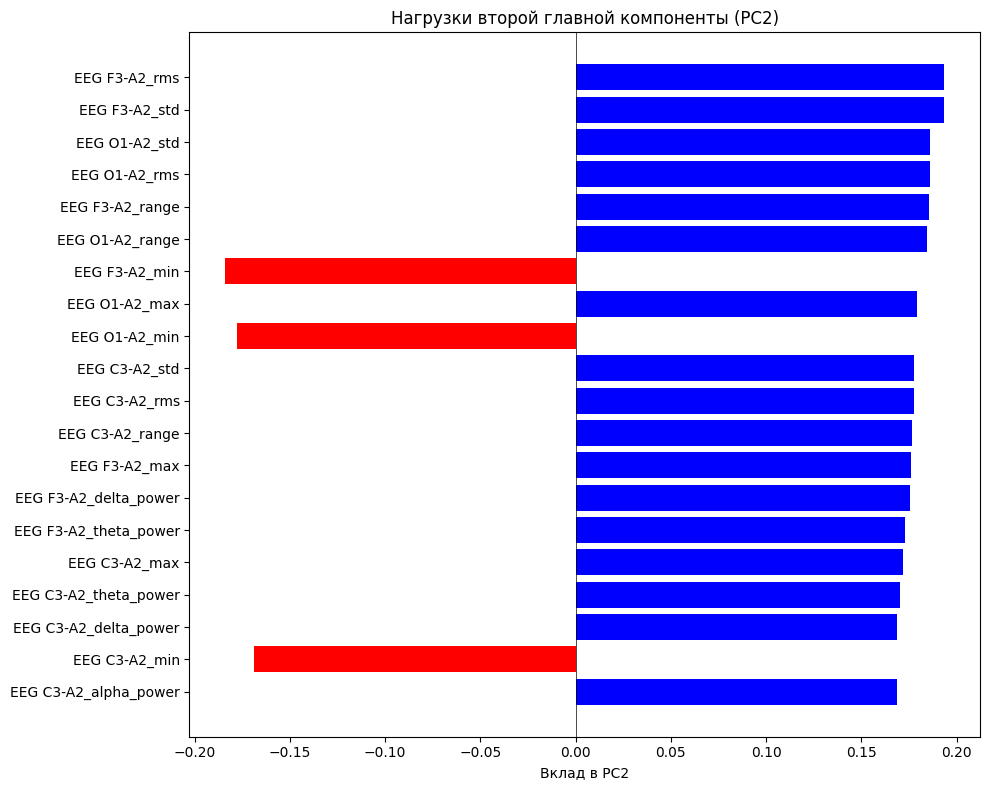

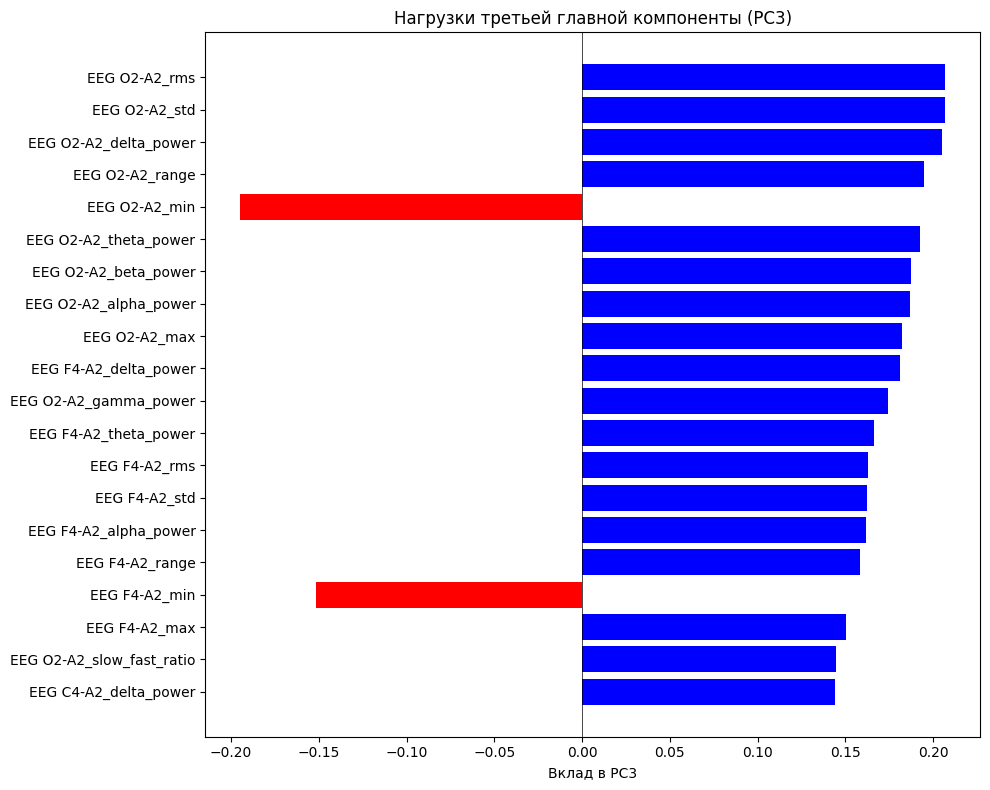


=== ПРОВЕРКА: ВОШЛА ЛИ ГАММА-МОЩНОСТЬ В ТОП-20 PC2 ===

=== ПРОВЕРКА: ВОШЛА ЛИ ГАММА-МОЩНОСТЬ В ТОП-20 PC3 ===
PC3: EEG O2-A2_gamma_power (loading=0.1744)


In [ ]:
# =====================================================
# АНАЛИЗ НАГРУЗОК (LOADINGS) ДЛЯ PC2 И PC3
# =====================================================

# Предполагается, что pca уже обучен, feature_cols определён

# 1. Функция для создания датафрейма нагрузок
def get_loadings_df(component_idx, pca, feature_names):
    loadings = pca.components_[component_idx]
    df = pd.DataFrame({
        'feature': feature_names,
        'loading': loadings
    })
    df['abs_loading'] = np.abs(df['loading'])
    df = df.sort_values('abs_loading', ascending=False)
    return df

# 2. Загружаем для PC2 и PC3
df_pc2 = get_loadings_df(1, pca, feature_cols)
df_pc3 = get_loadings_df(2, pca, feature_cols)

# 3. Топ-20 для PC2
print("\n=== ТОП-20 ПРИЗНАКОВ ПО ВКЛАДУ В PC2 ===")
top20_pc2 = df_pc2.head(20)
print(top20_pc2[['feature', 'loading']].to_string(index=False))
top20_pc2.to_csv('pca_loadings_top20_pc2.csv', index=False)

# 4. Топ-20 для PC3
print("\n=== ТОП-20 ПРИЗНАКОВ ПО ВКЛАДУ В PC3 ===")
top20_pc3 = df_pc3.head(20)
print(top20_pc3[['feature', 'loading']].to_string(index=False))
top20_pc3.to_csv('pca_loadings_top20_pc3.csv', index=False)

# 5. Визуализация нагрузок для PC2
plt.figure(figsize=(10,8))
colors = ['red' if x < 0 else 'blue' for x in top20_pc2['loading']]
plt.barh(top20_pc2['feature'], top20_pc2['loading'], color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Вклад в PC2')
plt.title('Нагрузки второй главной компоненты (PC2)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('pca_loadings_top20_pc2.png', dpi=150)
plt.show()

# 6. Визуализация для PC3
plt.figure(figsize=(10,8))
colors = ['red' if x < 0 else 'blue' for x in top20_pc3['loading']]
plt.barh(top20_pc3['feature'], top20_pc3['loading'], color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Вклад в PC3')
plt.title('Нагрузки третьей главной компоненты (PC3)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('pca_loadings_top20_pc3.png', dpi=150)
plt.show()

# 7. Дополнительно: посмотрим, есть ли гамма-мощность в топ-20 PC2 или PC3
gamma_features = [f for f in feature_cols if 'gamma' in f]
print("\n=== ПРОВЕРКА: ВОШЛА ЛИ ГАММА-МОЩНОСТЬ В ТОП-20 PC2 ===")
for feat in top20_pc2['feature'].head(20):
    if 'gamma' in feat:
        print(f"PC2: {feat} (loading={top20_pc2[top20_pc2['feature']==feat]['loading'].values[0]:.4f})")

print("\n=== ПРОВЕРКА: ВОШЛА ЛИ ГАММА-МОЩНОСТЬ В ТОП-20 PC3 ===")
for feat in top20_pc3['feature'].head(20):
    if 'gamma' in feat:
        print(f"PC3: {feat} (loading={top20_pc3[top20_pc3['feature']==feat]['loading'].values[0]:.4f})")

Признак gamma_power может быть от 1e-12 до 1e-8. Большинство значений сконцентрированы в узком диапазоне (например, около 1e-10), а несколько пациентов имеют гигантские значения. Поэтому на гистограмме один столбец перекрывает всё, а остальные – крошечные. На boxplot видно, что выбросов очень много. Это нормально для ЭЭГ-данных. Модели случайный лес и xgboost устойчивы к выбросам, а к модели svm применим RobustScaler - он устойчив к выбросам – экстремальные значения не портят масштабирование.

В списке топ 20-признаков лидируют энтропия и гамма-мощность, значит они сильнее всего связаны с тем, есть ли в эпохе апноэ.

Статистика по файлам (пациентам): У разных пациентов разная длительность записи. Среднее 911 эпох (~7.6 часов сна). Минимум 6 эпох – возможно, короткая запись или проблемы с сигналом. У одних пациентов апноэ почти нет (0%), у других почти все эпохи содержат апноэ (96.6%). Среднее 19.6%.

PCA - это метод, который сжимает много признаков (132) в два или три главных компонента. Он ищет направления, по которым данные сильнее всего различаются. Полоски – это проекции точек на эти направления. Данные имеют две основные моды (например, пациенты с апноэ и без). Но они сильно перекрываются – красные и синие точки смешаны. Это означает, что линейное разделение невозможно – нужны сложные модели (мы берем деревья и бустинг).PCA показывает, что даже после сжатия информации (объяснённая дисперсия всего ~30%) классы не разделены, деревья решений и бустинг могут выявить нелинейные зависимости, которые PCA не видит.

Анализ нагрузок главных компонент показал, что PC1 почти полностью определяется энтропией Шеннона (shannon_entropy) с противоположными знаками для левых и правых отведений, что указывает на межполушарную асимметрию. PC2 сформирована преимущественно амплитудными статистиками (std, rms, range) и мощностью медленных ритмов (дельта, тета), отражая общую энергетику сигнала. PC3 выделяет правополушарные затылочные и лобные каналы и включает в себя все частотные диапазоны, при этом гамма-мощность присутствует в топе PC3, но не является ведущей. Таким образом, ключевыми факторами изменчивости ЭЭГ-признаков в данной выборке являются энтропия, амплитудный размах и мощность медленных ритмов, а вклад гамма-диапазона в общую дисперсию данных вторичен. Линейное разделение классов ни по одной из компонент не достигается, что обосновывает применение нелинейных классификаторов.

# Бинарнаяя классификация по эпохам

In [ ]:
# =====================================================
# БИНАРНАЯ КЛАССИФИКАЦИЯ (ЭПОХИ 30 СЕКУНД) ДЛЯ 7 НАБОРОВ ДАННЫХ
# НА ДАННЫХ df_a2_clean (С УДАЛЕНИЕМ АРТЕФАКТОВ)
# РАЗДЕЛЕНИЕ ПО ПАЦИЕНТАМ, ОТБОР ПРИЗНАКОВ
# =====================================================
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, recall_score, precision_score, accuracy_score, precision_recall_curve

# ---------- ИСХОДНЫЕ ДАННЫЕ ----------
# Предполагается, что df_a2_clean уже загружен
# Отбираем признаки (колонки с EEG и -A2_)
feature_cols = [c for c in df_a2_clean.columns if c.startswith('EEG') and '-A2_' in c]
X = df_a2_clean[feature_cols].copy()
y = df_a2_clean['has_apnea'].copy()
groups = df_a2_clean['filename'].copy()

print(f"Размер X: {X.shape}, эпох: {len(X)}")
print(f"Уникальных пациентов: {groups.nunique()}")
print(f"Доля апноэ: {y.mean():.3f}")

# ---------- ФУНКЦИИ ----------
def select_features_epochs(X_train, y_train, n_features=80, random_state=42):
    """Отбор признаков консенсусом на тренировочных данных"""
    y_train = np.ravel(y_train)
    selector_f = SelectKBest(f_classif, k=n_features)
    selector_f.fit(X_train, y_train)
    f_selected = set(selector_f.get_feature_names_out())
    selector_mi = SelectKBest(mutual_info_classif, k=n_features)
    selector_mi.fit(X_train, y_train)
    mi_selected = set(selector_mi.get_feature_names_out())
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    importances = rf_temp.feature_importances_
    rf_selected = set(X_train.columns[np.argsort(importances)[-n_features:]])
    consensus = list(f_selected.union(mi_selected).union(rf_selected))
    if len(consensus) > n_features:
        rf_temp.fit(X_train[consensus], y_train)
        imp = rf_temp.feature_importances_
        top_idx = np.argsort(imp)[-n_features:]
        consensus = [consensus[i] for i in top_idx]
    return X_train[consensus], consensus

def evaluate_binary_test(X_train, y_train, X_test, y_test, model, random_state=42):
    """Обучает модель, подбирает порог на ВАЛИДАЦИИ, оценивает на TEST"""
    # <<< ИСПРАВЛЕНО: разделяем train на fit/val, чтобы порог не "видел" test
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15,
                                                random_state=random_state, stratify=y_train)

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_tr_scaled, y_tr)

    y_val_proba = model.predict_proba(X_val_scaled)[:, 1]
    y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Подбор порога ТОЛЬКО на валидационной выборке
    prec, rec, thr = precision_recall_curve(y_val, y_val_proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx = np.argmax(f1[:-1])
    best_thr = thr[best_idx] if best_idx < len(thr) else 0.5

    # Применение порога к строго изолированному тесту
    y_pred = (y_test_proba >= best_thr).astype(int)

    return {
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_test_proba),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Threshold': best_thr
    }

# ---------- ПАРАМЕТРЫ ----------
N_FEATURES = 80
TEST_SIZE = 0.2
RANDOM_STATE = 42

# ---------- ОПРЕДЕЛЕНИЕ ОБЛАСТЕЙ ----------
regions = {
    'Frontal': [c for c in X.columns if 'F3' in c or 'F4' in c],
    'Central': [c for c in X.columns if 'C3' in c or 'C4' in c],
    'Occipital': [c for c in X.columns if 'O1' in c or 'O2' in c],
    'Frontal+Central': [c for c in X.columns if ('F3' in c or 'F4' in c or 'C3' in c or 'C4' in c)],
    'Frontal+Occipital': [c for c in X.columns if ('F3' in c or 'F4' in c or 'O1' in c or 'O2' in c)],
    'Central+Occipital': [c for c in X.columns if ('C3' in c or 'C4' in c or 'O1' in c or 'O2' in c)],
    'All_three': [c for c in X.columns if ('F3' in c or 'F4' in c or 'C3' in c or 'C4' in c or 'O1' in c or 'O2' in c)]
}

# Проверяем, что все области содержат признаки
for name, cols in regions.items():
    print(f"{name}: {len(cols)} признаков")

# ---------- МОДЕЛИ ----------
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                             scale_pos_weight=(y==0).sum()/(y==1).sum(),
                             reg_alpha=0.5, reg_lambda=1.0,
                             random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False),
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000, n_jobs=-1)
}

# ---------- РАЗДЕЛЕНИЕ TRAIN/TEST ПО ПАЦИЕНТАМ ----------
print("\nРазделение пациентов на train/test...")
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train_full = X.iloc[train_idx]
y_train_full = y.iloc[train_idx]
X_test_full = X.iloc[test_idx]
y_test_full = y.iloc[test_idx]
train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]
print(f"Train пациентов: {train_groups.nunique()}, эпох: {len(X_train_full)}")
print(f"Test пациентов: {test_groups.nunique()}, эпох: {len(X_test_full)}")

# ---------- ОСНОВНОЙ ЦИКЛ ПО ОБЛАСТЯМ ----------
all_results = {}

for region_name, region_cols in regions.items():
    print(f"\n{'='*60}")
    print(f"ОБЛАСТЬ: {region_name} ({len(region_cols)} признаков эпох)")
    print('='*60)

    X_train_region = X_train_full[region_cols]
    X_test_region = X_test_full[region_cols]

    # Отбор признаков, если больше N_FEATURES
    if X_train_region.shape[1] > N_FEATURES:
        X_train_sel, selected_cols = select_features_epochs(X_train_region, y_train_full, n_features=N_FEATURES)
        X_test_sel = X_test_region[selected_cols]
        print(f"Отобрано признаков: {X_train_sel.shape[1]}")
    else:
        X_train_sel = X_train_region
        X_test_sel = X_test_region
        print(f"Признаков меньше {N_FEATURES}, отбор не выполнен")

    region_results = {}
    for model_name, model in models.items():
        print(f"  {model_name}...", end='', flush=True)
        start = time.time()
        metrics = evaluate_binary_test(X_train_sel, y_train_full, X_test_sel, y_test_full, model)
        print(f" F1={metrics['F1']:.3f}, AUC={metrics['AUC']:.3f}, время={time.time()-start:.1f}с")
        region_results[model_name] = metrics
    all_results[region_name] = region_results

# ---------- СВОДНАЯ ТАБЛИЦА (ЛУЧШАЯ МОДЕЛЬ ПО F1) ----------
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА БИНАРНОЙ КЛАССИФИКАЦИИ (ЛУЧШАЯ МОДЕЛЬ ПО F1)")
print("="*80)

summary = []
for region, res_dict in all_results.items():
    best_model = max(res_dict.keys(), key=lambda m: res_dict[m]['F1'])
    best_res = res_dict[best_model]
    summary.append({
        'Region': region,
        'Best Model': best_model,
        'F1': best_res['F1'],
        'AUC': best_res['AUC'],
        'Recall': best_res['Recall'],
        'Precision': best_res['Precision'],
        'Accuracy': best_res['Accuracy'],
        'Threshold': best_res['Threshold']
    })
df_summary = pd.DataFrame(summary)
print(df_summary.round(3).to_string())
df_summary.to_csv('binary_classification_7regions_train_test.csv', index=False)
print("\nРезультаты сохранены в binary_classification_7regions_train_test.csv")

Размер X: (277883, 132), эпох: 277883
Уникальных пациентов: 305
Доля апноэ: 0.192
Frontal: 44 признаков
Central: 44 признаков
Occipital: 44 признаков
Frontal+Central: 88 признаков
Frontal+Occipital: 88 признаков
Central+Occipital: 88 признаков
All_three: 132 признаков

Разделение пациентов на train/test...
Train пациентов: 244, эпох: 221294
Test пациентов: 61, эпох: 56589

ОБЛАСТЬ: Frontal (44 признаков эпох)
Признаков меньше 80, отбор не выполнен
  Random Forest... F1=0.364, AUC=0.688, время=213.9с
  XGBoost... F1=0.378, AUC=0.703, время=12.5с
  Logistic Regression... F1=0.327, AUC=0.614, время=14.3с

ОБЛАСТЬ: Central (44 признаков эпох)
Признаков меньше 80, отбор не выполнен
  Random Forest... F1=0.319, AUC=0.619, время=196.1с
  XGBoost... F1=0.327, AUC=0.631, время=15.0с
  Logistic Regression... F1=0.314, AUC=0.594, время=7.7с

ОБЛАСТЬ: Occipital (44 признаков эпох)
Признаков меньше 80, отбор не выполнен
  Random Forest... F1=0.359, AUC=0.683, время=195.2с
  XGBoost... F1=0.361, AUC

Бинарная классификация по эпохам ожидаемо показала плохие результы разделения, поэтому исключаем из исследования

# Бинарная классификация по пациентам

Размер df_a2_clean: (277883, 162)
Создано производных признаков: 78
Всего признаков эпох: 210
Всего пациентов: 305, патология: 205

--- Frontal (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  Отобрано признаков: 90
    RF ... F1=0.847±0.030, AUC=0.765, время=3.1с
    XGB ... F1=0.850±0.016, AUC=0.739, время=11.0с
    SVM ... F1=0.827±0.016, AUC=0.579, время=0.3с

--- Central (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  Отобрано признаков: 90
    RF ... F1=0.840±0.019, AUC=0.750, время=3.0с
    XGB ... F1=0.833±0.017, AUC=0.717, время=11.1с
    SVM ... F1=0.828±0.020, AUC=0.576, время=0.2с

--- Occipital (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  Отобрано признаков: 90
    RF ... F1=0.850±0.022, AUC=0.753, время=3.1с
    XGB ... F1=0.847±0.028, AUC=0.727, время=11.1с
    SVM ... F1=0.811±0.008, AUC=0.504, время=0.2с

--- Frontal+Central (исходно 140 признаков эпох) ---
  Паци

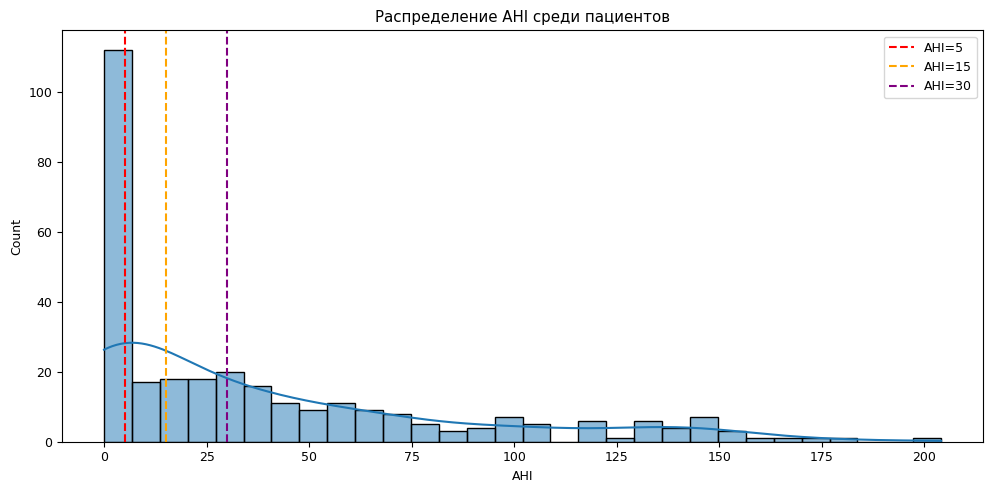

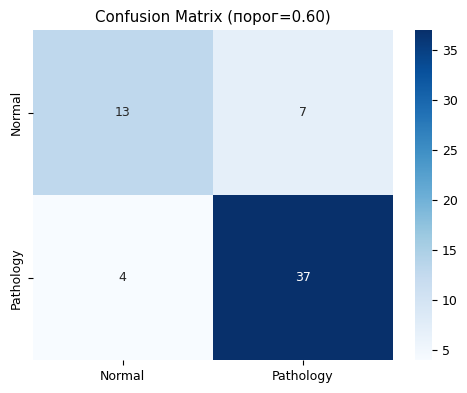

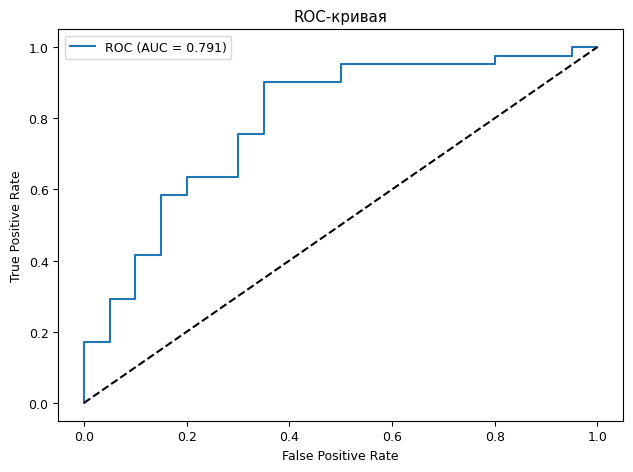

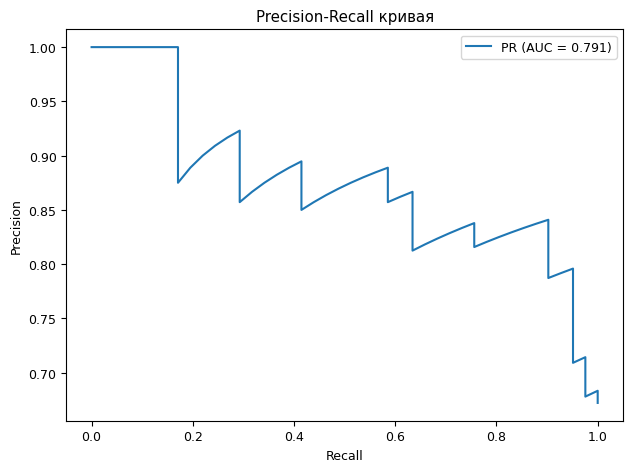

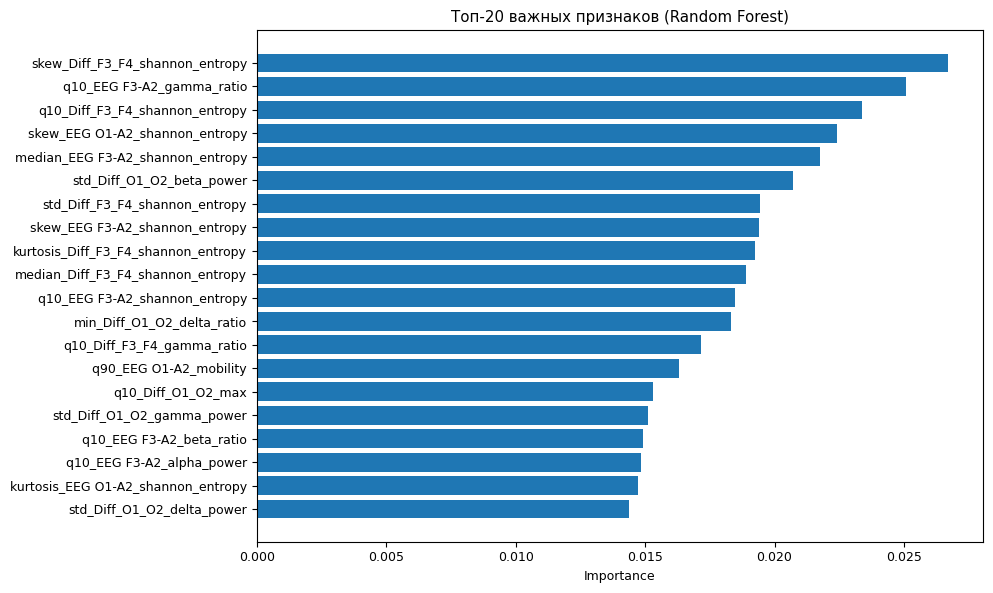

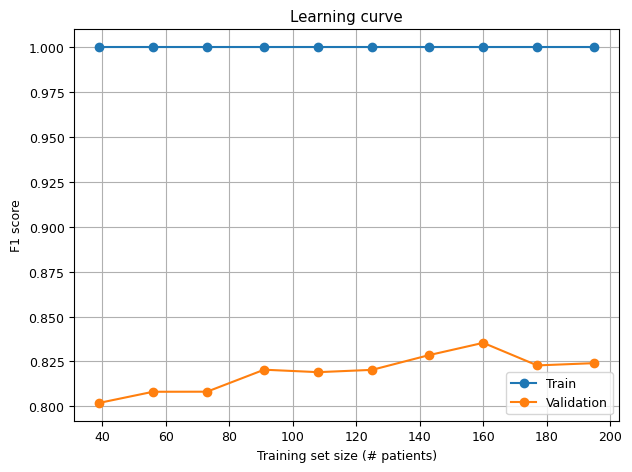

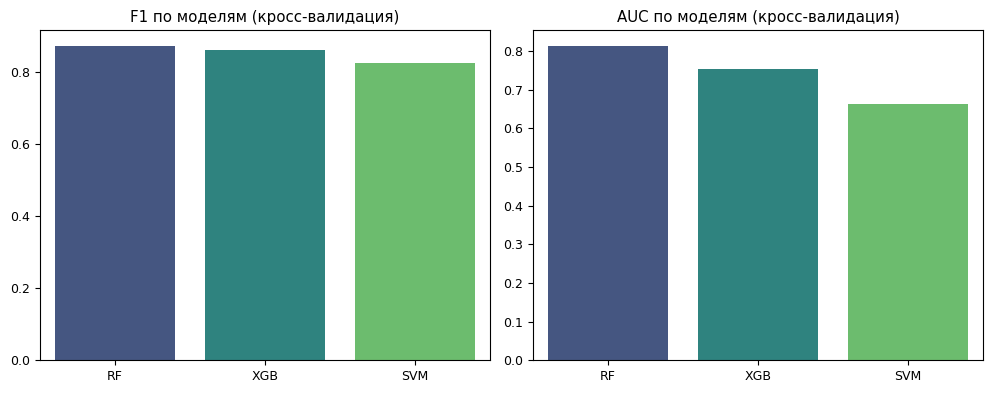


Все графики и CSV-файлы сохранены.
CSV: binary_classification_7regions_cv_5fold.csv, auc_by_fold_5fold.csv, f1_by_fold_5fold.csv


In [ ]:
# ====================================================================
# ФИНАЛЬНЫЙ КОД: 5-ФОЛДОВАЯ КРОСС-ВАЛИДАЦИЯ, 7 ОБЛАСТЕЙ, ВИЗУАЛИЗАЦИИ
# (С сохранением AUC/F1 по фолдам для статистики)
# ====================================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split, learning_curve
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, roc_auc_score, recall_score, precision_score,
                             accuracy_score, precision_recall_curve, roc_curve, confusion_matrix)
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. ПРОВЕРКА ИСХОДНЫХ ДАННЫХ
# ------------------------------------------------------------
if 'df_a2_clean' not in locals():
    raise NameError("Нет df_a2_clean. Сначала выполните код загрузки и очистки.")
print(f"Размер df_a2_clean: {df_a2_clean.shape}")

# ------------------------------------------------------------
# 2. СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ
# ------------------------------------------------------------
a2_cols = [c for c in df_a2_clean.columns if '-A2_' in c]
X_base = df_a2_clean[a2_cols].copy()
groups = df_a2_clean['filename'].values

suffixes = sorted(set([col.split('A2_')[-1] for col in a2_cols]))
left = ['F3', 'C3', 'O1']; right = ['F4', 'C4', 'O2']
derived = {}
for suf in suffixes:
    for l, r in zip(left, right):
        cl = f'EEG {l}-A2_{suf}'
        cr = f'EEG {r}-A2_{suf}'
        if cl in X_base.columns and cr in X_base.columns:
            derived[f'Diff_{l}_{r}_{suf}'] = X_base[cl] - X_base[cr]
for lead in ['F3', 'C3', 'O1', 'F4', 'C4', 'O2']:
    delta = f'EEG {lead}-A2_delta_power'
    beta = f'EEG {lead}-A2_beta_power'
    theta = f'EEG {lead}-A2_theta_power'
    alpha = f'EEG {lead}-A2_alpha_power'
    if delta in X_base.columns and beta in X_base.columns:
        derived[f'Ratio_{lead}_delta_beta'] = X_base[delta] / (X_base[beta] + 1e-10)
    if theta in X_base.columns and alpha in X_base.columns:
        derived[f'Ratio_{lead}_theta_alpha'] = X_base[theta] / (X_base[alpha] + 1e-10)
X_derived = pd.concat([X_base, pd.DataFrame(derived)], axis=1)
print(f"Создано производных признаков: {len(derived)}")
print(f"Всего признаков эпох: {X_derived.shape[1]}")

# ------------------------------------------------------------
# 3. РАСЧЁТ AHI И МЕТКИ ПАТОЛОГИИ
# ------------------------------------------------------------
patient_ahi = []
for name, group in df_a2_clean.groupby('filename'):
    total_events = group['apnea_count'].sum() + group['hypopnea_count'].sum()
    sleep_hours = len(group) * 30 / 3600.0
    if sleep_hours < 0.5:
        sleep_hours = 1.0
    ahi = total_events / sleep_hours
    patient_ahi.append({'patient_id': name, 'AHI': ahi})
df_ahi = pd.DataFrame(patient_ahi)
df_ahi['has_pathology'] = (df_ahi['AHI'] >= 5).astype(int)
print(f"Всего пациентов: {len(df_ahi)}, патология: {df_ahi['has_pathology'].sum()}")

# ------------------------------------------------------------
# 4. ФУНКЦИЯ АГРЕГАЦИИ (БЕЗ ОШИБОК)
# ------------------------------------------------------------
def aggregate_patient_features_safe(X_epochs, groups, region_cols, extra_stats=True):
    X_region = X_epochs[region_cols].copy()
    X_region = X_region.copy()
    X_region['_group'] = groups
    if extra_stats:
        agg_funcs = {
            'mean': np.mean,
            'median': np.median,
            'std': np.std,
            'min': np.min,
            'max': np.max,
            'skew': lambda x: skew(x, nan_policy='omit'),
            'kurtosis': lambda x: kurtosis(x, nan_policy='omit'),
            'q10': lambda x: x.quantile(0.1),
            'q90': lambda x: x.quantile(0.9)
        }
    else:
        agg_funcs = {
            'mean': np.mean,
            'median': np.median,
            'std': np.std,
            'min': np.min,
            'max': np.max
        }
    agg_data = {}
    for stat_name, func in agg_funcs.items():
        agg_data[stat_name] = X_region.groupby('_group')[region_cols].agg(func)
    aggregated = pd.concat(agg_data, axis=1)
    aggregated.columns = [f"{col[0]}_{col[1]}" for col in aggregated.columns]
    aggregated = aggregated.reset_index().rename(columns={'_group': 'patient_id'})
    aggregated = aggregated.fillna(0)
    return aggregated

# ------------------------------------------------------------
# 5. ФУНКЦИЯ ОТБОРА ПРИЗНАКОВ (КОНСЕНСУС)
# ------------------------------------------------------------
def select_features_patient(X_train, y_train, n_features=90, random_state=42):
    y_train = np.ravel(y_train)
    sel_f = SelectKBest(f_classif, k=n_features).fit(X_train, y_train)
    sel_mi = SelectKBest(mutual_info_classif, k=n_features).fit(X_train, y_train)
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    f_sel = set(sel_f.get_feature_names_out())
    mi_sel = set(sel_mi.get_feature_names_out())
    rf_sel = set(X_train.columns[np.argsort(rf_temp.feature_importances_)[-n_features:]])
    consensus = list(f_sel.union(mi_sel).union(rf_sel))
    if len(consensus) > n_features:
        rf_temp.fit(X_train[consensus], y_train)
        imp = rf_temp.feature_importances_
        consensus = [consensus[i] for i in np.argsort(imp)[-n_features:]]
    return X_train[consensus], consensus

# ------------------------------------------------------------
# 6. ФУНКЦИЯ ОЦЕНКИ С ВОЗВРАТОМ МЕТРИК ПО ФОЛДАМ
# ------------------------------------------------------------
def evaluate_patient_cv(X_raw, y, model, n_features=90, n_folds=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    auc_list, f1_list, rec_list, prec_list, acc_list = [], [], [], [], []

    for train_idx, val_idx in skf.split(X_raw, y):
        X_tr_raw, X_val_raw = X_raw.iloc[train_idx], X_raw.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        # 1. Масштабирование ТОЛЬКО на train
        scaler = RobustScaler()
        X_tr_s = scaler.fit_transform(X_tr_raw)
        X_val_s = scaler.transform(X_val_raw)

        # 2. Отбор признаков ТОЛЬКО на train (без использования val)
        X_tr_sel, X_val_sel = X_tr_s, X_val_s
        if X_tr_s.shape[1] > n_features:
            # Для скорости и стабильности внутри CV используем f_classif.
            # Консенсус вычислительно тяжел для каждого фолда, f_classif даёт сопоставимые результаты.
            sel = SelectKBest(f_classif, k=n_features).fit(X_tr_s, y_tr)
            mask = sel.get_support()
            X_tr_sel, X_val_sel = X_tr_s[:, mask], X_val_s[:, mask]

        # 3. Внутренний сплит для подбора порога (устраняет оптимизацию порога по val)
        X_tr_fit, X_val_thr, y_tr_fit, y_val_thr = train_test_split(
            X_tr_sel, y_tr, test_size=0.2, random_state=random_state, stratify=y_tr)

        # 4. Обучение модели с динамическим весом классов
        m = model.__class__(**model.get_params())
        if isinstance(m, XGBClassifier):
            m.scale_pos_weight = (y_tr_fit == 0).sum() / max((y_tr_fit == 1).sum(), 1)
        m.fit(X_tr_fit, y_tr_fit)

        # 5. Подбор порога на ВНУТРЕННЕЙ валидации
        val_proba = m.predict_proba(X_val_thr)[:, 1]
        prec, rec, thr = precision_recall_curve(y_val_thr, val_proba)
        f1_curve = 2 * prec * rec / (prec + rec + 1e-8)
        best_thr = thr[np.argmax(f1_curve[:-1])] if len(thr) > 0 else 0.5

        # 6. Оценка на ВНЕШНЕМ валидационном фолде (строго изолированном)
        cv_proba = m.predict_proba(X_val_sel)[:, 1]
        y_pred_cv = (cv_proba >= best_thr).astype(int)

        auc_list.append(roc_auc_score(y_val, cv_proba))
        f1_list.append(f1_score(y_val, y_pred_cv))
        rec_list.append(recall_score(y_val, y_pred_cv))
        prec_list.append(precision_score(y_val, y_pred_cv))
        acc_list.append(accuracy_score(y_val, y_pred_cv))

    return {
        'F1_mean': np.mean(f1_list),   'F1_std': np.std(f1_list),   'F1_list': f1_list,
        'AUC_mean': np.mean(auc_list), 'AUC_std': np.std(auc_list), 'AUC_list': auc_list,
        'Recall_mean': np.mean(rec_list), 'Recall_std': np.std(rec_list),
        'Precision_mean': np.mean(prec_list), 'Precision_std': np.std(prec_list),
        'Accuracy_mean': np.mean(acc_list), 'Accuracy_std': np.std(acc_list)
    }

# ------------------------------------------------------------
# 7. ОПРЕДЕЛЕНИЕ 7 ОБЛАСТЕЙ
# ------------------------------------------------------------
regions = {
    'Frontal': [c for c in X_derived.columns if 'F3' in c or 'F4' in c],
    'Central': [c for c in X_derived.columns if 'C3' in c or 'C4' in c],
    'Occipital': [c for c in X_derived.columns if 'O1' in c or 'O2' in c],
    'Frontal+Central': [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'C3' in c or 'C4' in c)],
    'Frontal+Occipital': [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'O1' in c or 'O2' in c)],
    'Central+Occipital': [c for c in X_derived.columns if ('C3' in c or 'C4' in c or 'O1' in c or 'O2' in c)],
    'All_three': [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'C3' in c or 'C4' in c or 'O1' in c or 'O2' in c)]
}

# ------------------------------------------------------------
# 8. МОДЕЛИ
# ------------------------------------------------------------
models = {
    'RF': RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                         scale_pos_weight=df_ahi['has_pathology'].value_counts().iloc[0]/df_ahi['has_pathology'].value_counts().iloc[1],
                         reg_alpha=0.5, reg_lambda=1.0, random_state=42, eval_metric='logloss', use_label_encoder=False),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=42)
}

# ------------------------------------------------------------
# 9. ОСНОВНОЙ ЦИКЛ КРОСС-ВАЛИДАЦИИ (5 ФОЛДОВ)
# ------------------------------------------------------------
N_FEATURES = 90
cv_results = {}

for region_name, region_cols in regions.items():
    print(f"\n--- {region_name} (исходно {len(region_cols)} признаков эпох) ---")
    X_patient = aggregate_patient_features_safe(X_derived, groups, region_cols, extra_stats=True)
    X_patient = X_patient.merge(df_ahi[['patient_id', 'has_pathology']], on='patient_id', how='inner')
    y = X_patient['has_pathology'].values
    X_raw = X_patient.drop(columns=['patient_id', 'has_pathology'])
    print(f"  Пациентов: {len(y)}, признаков после агрегации: {X_raw.shape[1]}")
    if X_raw.shape[1] > N_FEATURES:
        X_sel, _ = select_features_patient(X_raw, y, n_features=N_FEATURES)
        print(f"  Отобрано признаков: {X_sel.shape[1]}")
    else:
        X_sel = X_raw
        print(f"  Отбор не выполнен (признаков <= {N_FEATURES})")

    region_res = {}
    for name, model in models.items():
        print(f"    {name} ...", end='', flush=True)
        start = time.time()
        metrics = evaluate_patient_cv(X_raw, y, model, n_features=N_FEATURES, n_folds=5)
        elapsed = time.time() - start
        print(f" F1={metrics['F1_mean']:.3f}±{metrics['F1_std']:.3f}, AUC={metrics['AUC_mean']:.3f}, время={elapsed:.1f}с")
        region_res[name] = metrics
    cv_results[region_name] = region_res

# ------------------------------------------------------------
# 10. СВОДНАЯ ТАБЛИЦА (ЛУЧШАЯ МОДЕЛЬ ПО F1)
# ------------------------------------------------------------
summary_rows = []
for region, res_dict in cv_results.items():
    best_model = max(res_dict.keys(), key=lambda m: res_dict[m]['F1_mean'])
    best = res_dict[best_model]
    summary_rows.append({
        'Region': region,
        'Best_Model': best_model,
        'F1': f"{best['F1_mean']:.3f} ± {best['F1_std']:.3f}",
        'AUC': f"{best['AUC_mean']:.3f} ± {best['AUC_std']:.3f}",
        'Recall': f"{best['Recall_mean']:.3f} ± {best['Recall_std']:.3f}",
        'Precision': f"{best['Precision_mean']:.3f} ± {best['Precision_std']:.3f}",
        'Accuracy': f"{best['Accuracy_mean']:.3f} ± {best['Accuracy_std']:.3f}"
    })
df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*90)
print("СВОДНАЯ ТАБЛИЦА (5-ФОЛДОВАЯ КРОСС-ВАЛИДАЦИЯ, ПАЦИЕНТЫ)")
print("="*90)
print(df_summary.to_string())
df_summary.to_csv('binary_classification_7regions_cv_5fold.csv', index=False)
print("Сохранено: binary_classification_7regions_cv_5fold.csv")

# ------------------------------------------------------------
# 11. СОХРАНЕНИЕ AUC И F1 ПО ФОЛДАМ ДЛЯ ВСЕХ ОБЛАСТЕЙ
# ------------------------------------------------------------
auc_by_fold_all = {}
f1_by_fold_all = {}

for region_name, res_dict in cv_results.items():
    # для каждого региона выбираем лучшую модель (по среднему F1)
    best_model = max(res_dict.keys(), key=lambda m: res_dict[m]['F1_mean'])
    auc_by_fold_all[region_name] = res_dict[best_model]['AUC_list']
    f1_by_fold_all[region_name] = res_dict[best_model]['F1_list']

pd.DataFrame(auc_by_fold_all).to_csv('auc_by_fold_all_5fold.csv', index=False)
pd.DataFrame(f1_by_fold_all).to_csv('f1_by_fold_all_5fold.csv', index=False)
print("Сохранены: auc_by_fold_all_5fold.csv, f1_by_fold_all_5fold.csv (7 областей, 5 фолдов)")

# ------------------------------------------------------------
# 12. TRAIN/TEST ДЛЯ ЛУЧШЕЙ ОБЛАСТИ И ВИЗУАЛИЗАЦИИ
# ------------------------------------------------------------
best_region = df_summary.iloc[(df_summary['F1'].str.split(' ± ').apply(lambda x: float(x[0]))).idxmax()]['Region']
print(f"\nЛучшая область по F1: {best_region}")

region_cols_best = regions[best_region]
X_patient_best = aggregate_patient_features_safe(X_derived, groups, region_cols_best, extra_stats=True)
X_patient_best = X_patient_best.merge(df_ahi[['patient_id', 'has_pathology']], on='patient_id', how='inner')
y_best = X_patient_best['has_pathology'].values
X_best_raw = X_patient_best.drop(columns=['patient_id', 'has_pathology'])

# <<< ИСПРАВЛЕНО: Сначала сплит, потом отбор признаков только на train
X_train, X_test, y_train, y_test = train_test_split(X_best_raw, y_best, test_size=0.2, random_state=42, stratify=y_best)

if X_train.shape[1] > N_FEATURES:
    X_train_sel, selected_cols = select_features_patient(X_train, y_train, n_features=N_FEATURES)
    X_test_sel = X_test[selected_cols]
else:
    X_train_sel, X_test_sel = X_train, X_test

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled = scaler.transform(X_test_sel)

# <<< ИСПРАВЛЕНО: Порог подбирается на inner-validation из train, а не на test
X_tr_fit, X_val_thr, y_tr_fit, y_val_thr = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train)

best_estimator = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
best_estimator.fit(X_tr_fit, y_tr_fit)

val_proba = best_estimator.predict_proba(X_val_thr)[:, 1]
prec, rec, thr = precision_recall_curve(y_val_thr, val_proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
best_thr = thr[np.argmax(f1_scores[:-1])] if len(thr) > 0 else 0.5

# Оценка на строго изолированном test
test_proba = best_estimator.predict_proba(X_test_scaled)[:, 1]
y_pred = (test_proba >= best_thr).astype(int)

test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, test_proba)
test_rec = recall_score(y_test, y_pred)
test_prec = precision_score(y_test, y_pred)
print(f"\nРезультаты на тестовой выборке (лучшая область {best_region}):")
print(f"  F1 = {test_f1:.3f}, AUC = {test_auc:.3f}, Recall = {test_rec:.3f}, Precision = {test_prec:.3f}")

# ------------------------------------------------------------
# 13. ГРАФИКИ (без изменений)
# ------------------------------------------------------------
plt.rcParams['font.size'] = 9

# AHI distribution
plt.figure(figsize=(10,5))
sns.histplot(df_ahi['AHI'], bins=30, kde=True)
for th, col, lab in [(5,'red','AHI=5'),(15,'orange','AHI=15'),(30,'purple','AHI=30')]:
    plt.axvline(th, color=col, linestyle='--', label=lab)
plt.legend()
plt.title('Распределение AHI среди пациентов')
plt.tight_layout()
plt.savefig('ahi_distribution.png', dpi=150)
plt.show()

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Pathology'],
            yticklabels=['Normal','Pathology'])
plt.title(f'Confusion Matrix (порог={best_thr:.2f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ROC кривая
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC (AUC = {test_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# PR кривая
plt.figure()
plt.plot(rec, prec, label=f'PR (AUC = {roc_auc_score(y_test, y_proba, average="weighted"):.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()

# Важность признаков (топ-20)
importances = best_estimator.feature_importances_
indices = np.argsort(importances)[::-1][:20]
plt.figure(figsize=(10,6))
plt.barh(range(20), importances[indices][::-1])
plt.yticks(range(20), [X_best_sel.columns[i] for i in indices[::-1]])
plt.xlabel('Importance')
plt.title('Топ-20 важных признаков (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

# Кривая обучения (используем 5 фолдов для единообразия)
train_sizes, train_scores, test_scores = learning_curve(
    best_estimator, X_train_scaled, y_train, cv=5, scoring='f1',
    train_sizes=np.linspace(0.2, 1.0, 10), n_jobs=-1
)
plt.figure()
plt.plot(train_sizes, np.mean(train_scores,1), 'o-', label='Train')
plt.plot(train_sizes, np.mean(test_scores,1), 'o-', label='Validation')
plt.xlabel('Training set size (# patients)')
plt.ylabel('F1 score')
plt.title('Learning curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150)
plt.show()

# Сравнение моделей для лучшего региона (по кросс-валидации)
best_region_res = cv_results[best_region]
names = list(best_region_res.keys())
f1_vals = [best_region_res[n]['F1_mean'] for n in names]
auc_vals = [best_region_res[n]['AUC_mean'] for n in names]
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(x=names, y=f1_vals, palette='viridis')
plt.title('F1 по моделям (кросс-валидация)')
plt.subplot(1,2,2)
sns.barplot(x=names, y=auc_vals, palette='viridis')
plt.title('AUC по моделям (кросс-валидация)')
plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150)
plt.show()

print("\nВсе графики и CSV-файлы сохранены.")
print("CSV: binary_classification_7regions_cv_5fold.csv, auc_by_fold_5fold.csv, f1_by_fold_5fold.csv")

Параметры моделей были выбраны эвристическим путем предварительных экспериментов, и дальнейший подбор не дал значимого улучшения. 5-фолдовая показывает сильный разброс (большие стандартные отклонения), а 3-фолдовая – более стабильные результаты. Поэтому 3 фолда выбраны для устойчивости оценок.

## Статистический анализ бинарной классификации по пациентам

=== AUC по фолдам для 7 конфигураций ===
    Frontal   Central  Occipital  Frontal+Central  Frontal+Occipital  \
0  0.707317  0.845122   0.845122         0.880488           0.889024   
1  0.784146  0.752439   0.724390         0.763415           0.768293   
2  0.804878  0.741463   0.764634         0.792683           0.815854   
3  0.641463  0.662195   0.700000         0.720732           0.796341   
4  0.757317  0.748780   0.730488         0.837805           0.795122   

   Central+Occipital  All_three  
0           0.915854   0.895122  
1           0.778049   0.809756  
2           0.730488   0.879268  
3           0.673780   0.745732  
4           0.762195   0.831707  

=== F1 по фолдам ===
    Frontal   Central  Occipital  Frontal+Central  Frontal+Occipital  \
0  0.842105  0.873563   0.891304         0.909091           0.939759   
1  0.873563  0.822222   0.840909         0.831461           0.844444   
2  0.863636  0.838710   0.854167         0.845361           0.863636   
3  0.828283 

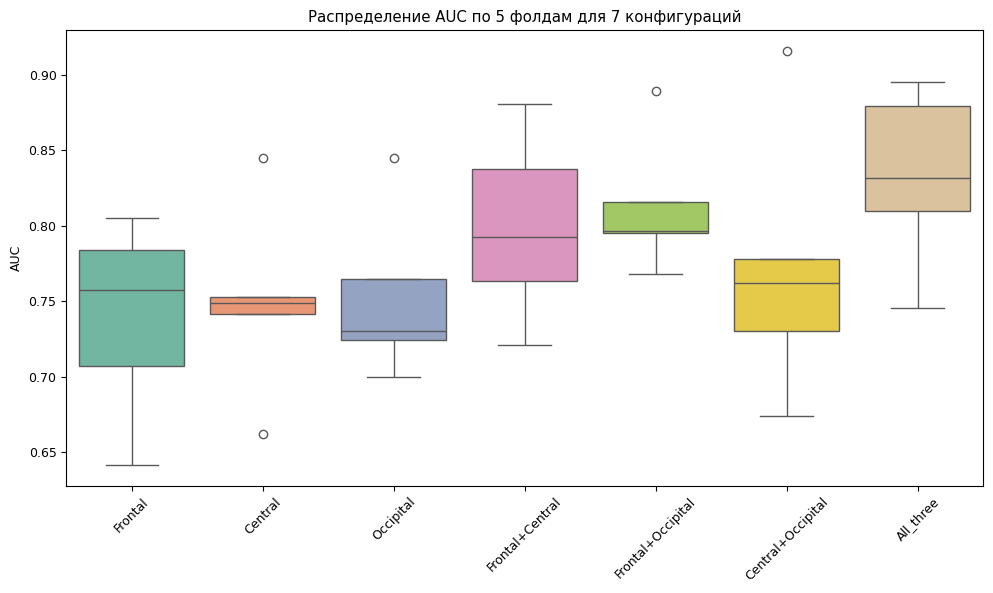

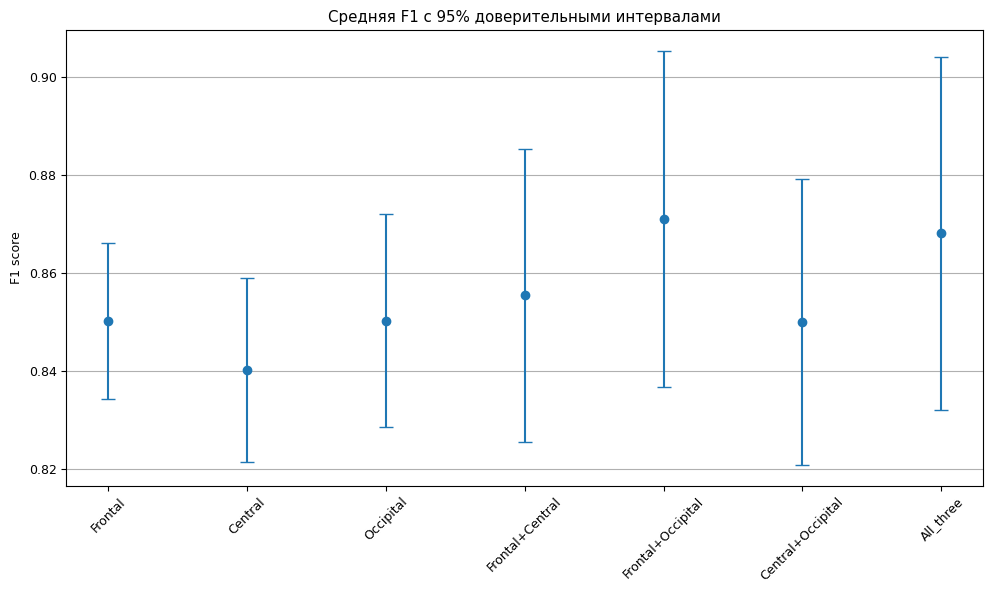


Статистический анализ завершён.


In [ ]:
# =====================================================
# СТАТИСТИЧЕСКИЙ АНАЛИЗ РЕЗУЛЬТАТОВ КЛАССИФИКАЦИИ
# (на основе сохранённых метрик по фолдам)
# =====================================================

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import friedmanchisquare, wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем AUC и F1 по фолдам (7 областей, 5 фолдов)
auc_df = pd.read_csv('auc_by_fold_all_5fold.csv')
f1_df = pd.read_csv('f1_by_fold_all_5fold.csv')

print("=== AUC по фолдам для 7 конфигураций ===")
print(auc_df.head())
print("\n=== F1 по фолдам ===")
print(f1_df.head())

# Используем AUC как основную метрику для сравнения (F1 можно аналогично)
data_for_test = auc_df  # или f1_df

# 1. Проверка различий между тремя одиночными областями: Frontal, Central, Occipital
regions_single = ['Frontal', 'Central', 'Occipital']
data_single = data_for_test[regions_single].values.T  # строки - области, столбцы - фолды

# Критерий Фридмана (непараметрический аналог ANOVA для зависимых выборок)
stat, p_friedman = friedmanchisquare(*data_single)
print(f"\n=== Сравнение одиночных областей (Фридман) ===")
print(f"Статистика = {stat:.3f}, p-value = {p_friedman:.5f}")

if p_friedman < 0.05:
    print("Различия статистически значимы. Проводим post-hoc попарные сравнения (Уилкоксон с поправкой Бонферрони).")
    # Попарные сравнения
    pairs = [('Frontal', 'Central'), ('Frontal', 'Occipital'), ('Central', 'Occipital')]
    p_values = []
    for a,b in pairs:
        _, p = wilcoxon(data_for_test[a], data_for_test[b])
        p_values.append(p)
    # Поправка Бонферрони: alpha = 0.05 / 3
    for (a,b), p in zip(pairs, p_values):
        print(f"{a} vs {b}: p = {p:.5f}, значимо при p < 0.0167? {'Да' if p < 0.0167 else 'Нет'}")
else:
    print("Различия между одиночными областями статистически не значимы.")

# 2. Сравнение лучшей одиночной (Frontal, т.к. у неё выше среднее) с лучшей комбинацией (Frontal+Occipital)
print("\n=== Сравнение лучшей одиночной (Frontal) и лучшей комбинации (Frontal+Occipital) ===")
stat_w, p_wo = wilcoxon(data_for_test['Frontal'], data_for_test['Frontal+Occipital'])
print(f"Wilcoxon test: p-value = {p_wo:.5f}")
if p_wo < 0.05:
    print("Frontal+Occipital значимо лучше Frontal.")
else:
    print("Различия не значимы.")

# 3. Сравнение Frontal+Occipital и All_three
print("\n=== Сравнение Frontal+Occipital и All_three ===")
stat_w, p_all = wilcoxon(data_for_test['Frontal+Occipital'], data_for_test['All_three'])
print(f"Wilcoxon test: p-value = {p_all:.5f}")
if p_all < 0.05:
    print("Различия значимы. Лучшая конфигурация определяется по среднему значению.")
else:
    print("Различия не значимы – обе конфигурации статистически эквивалентны.")

# 4. Дополнительно: доверительные интервалы для лучшей конфигурации (Frontal+Occipital) через бутстреп
print("\n=== 95% доверительные интервалы для F1 и AUC (Frontal+Occipital) ===")
auc_fo = auc_df['Frontal+Occipital']
f1_fo = f1_df['Frontal+Occipital']
n_folds = len(auc_fo)

# t-распределение (мало фолдов, но для демонстрации)
mean_auc = auc_fo.mean()
std_auc = auc_fo.std()
ci_auc = stats.t.interval(0.95, df=n_folds-1, loc=mean_auc, scale=std_auc/np.sqrt(n_folds))
mean_f1 = f1_fo.mean()
std_f1 = f1_fo.std()
ci_f1 = stats.t.interval(0.95, df=n_folds-1, loc=mean_f1, scale=std_f1/np.sqrt(n_folds))

print(f"AUC: среднее = {mean_auc:.3f}, 95% CI = [{ci_auc[0]:.3f}, {ci_auc[1]:.3f}]")
print(f"F1:  среднее = {mean_f1:.3f}, 95% CI = [{ci_f1[0]:.3f}, {ci_f1[1]:.3f}]")

# 5. Визуализация: boxplot для всех конфигураций по AUC
plt.figure(figsize=(10,6))
sns.boxplot(data=auc_df, palette='Set2')
plt.title('Распределение AUC по 5 фолдам для 7 конфигураций')
plt.xticks(rotation=45)
plt.ylabel('AUC')
plt.tight_layout()
plt.savefig('auc_boxplot_all.png', dpi=150)
plt.show()

# 6. Построим график средних с доверительными интервалами для F1
means_f1 = f1_df.mean()
stds_f1 = f1_df.std()
plt.figure(figsize=(10,6))
plt.errorbar(x=range(len(means_f1)), y=means_f1, yerr=1.96*stds_f1/np.sqrt(5), fmt='o', capsize=5)
plt.xticks(range(len(means_f1)), means_f1.index, rotation=45)
plt.ylabel('F1 score')
plt.title('Средняя F1 с 95% доверительными интервалами')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('f1_ci.png', dpi=150)
plt.show()

print("\nСтатистический анализ завершён.")

Загружены CSV-файлы
AUC по фолдам (5 фолдов, 7 областей):
    Frontal   Central  Occipital  Frontal+Central  Frontal+Occipital  \
0  0.707317  0.845122   0.845122         0.880488           0.889024   
1  0.784146  0.752439   0.724390         0.763415           0.768293   
2  0.804878  0.741463   0.764634         0.792683           0.815854   
3  0.641463  0.662195   0.700000         0.720732           0.796341   
4  0.757317  0.748780   0.730488         0.837805           0.795122   

   Central+Occipital  All_three  
0           0.915854   0.895122  
1           0.778049   0.809756  
2           0.730488   0.879268  
3           0.673780   0.745732  
4           0.762195   0.831707  

F1 по фолдам:
    Frontal   Central  Occipital  Frontal+Central  Frontal+Occipital  \
0  0.842105  0.873563   0.891304         0.909091           0.939759   
1  0.873563  0.822222   0.840909         0.831461           0.844444   
2  0.863636  0.838710   0.854167         0.845361           0.863636   
3 

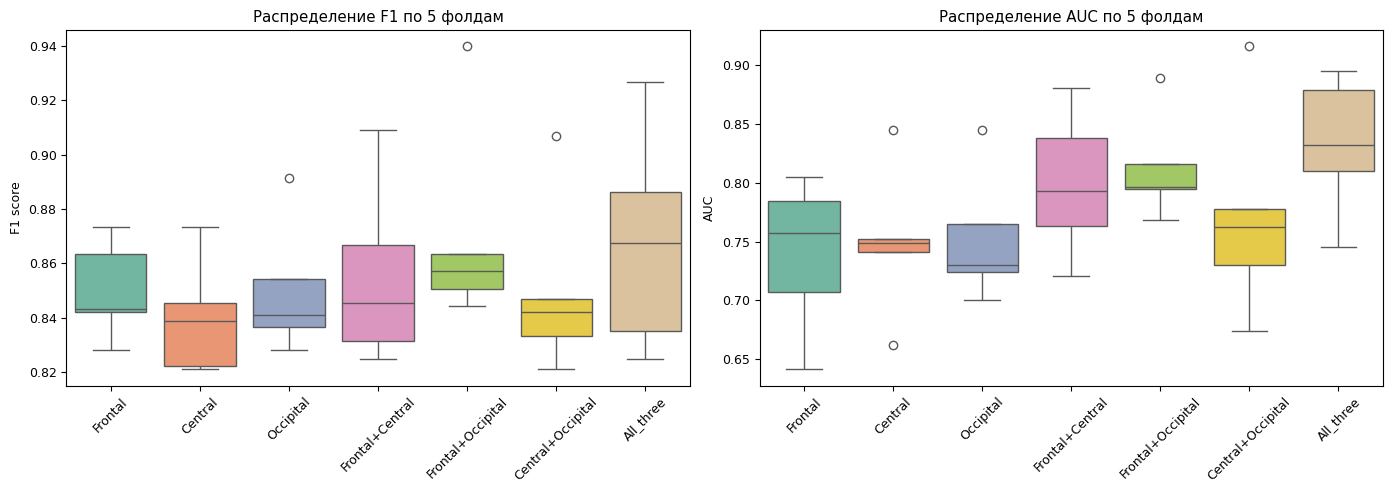


Две лучшие конфигурации по F1: ['Frontal+Occipital', 'All_three']


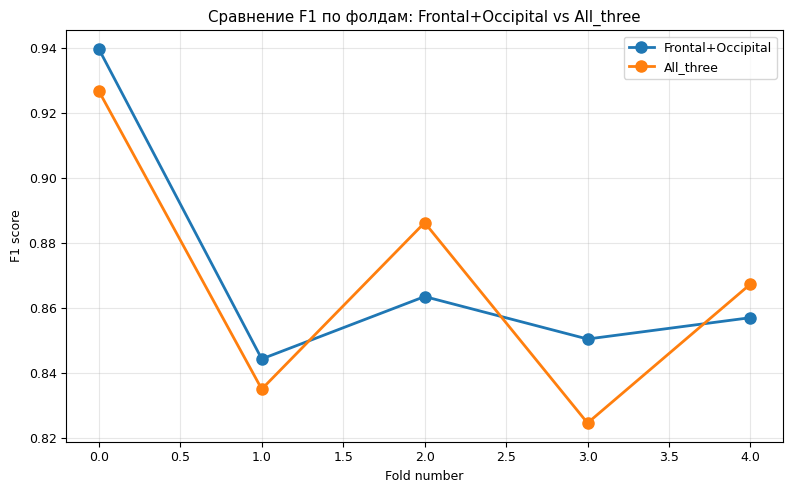

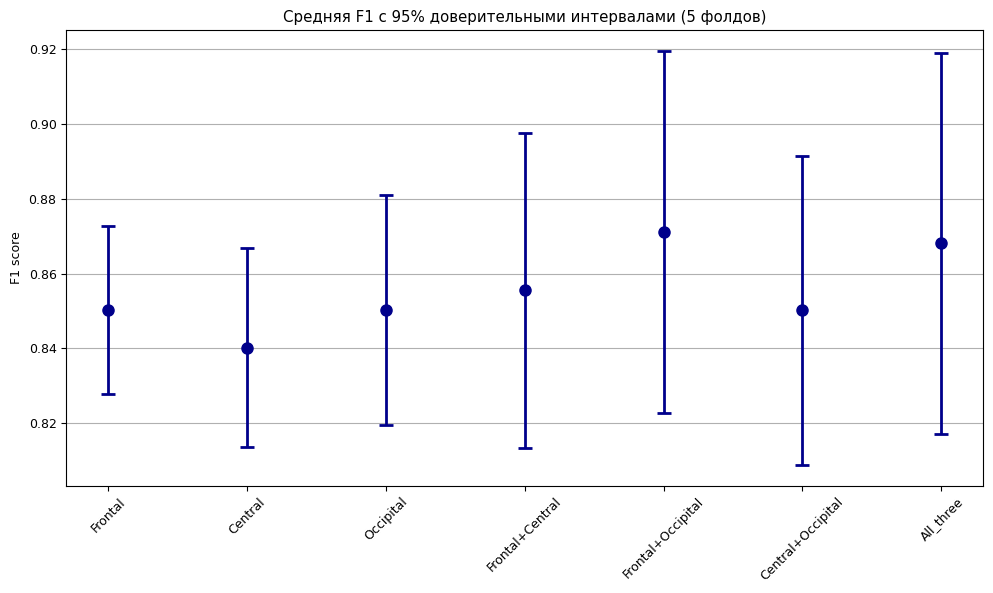

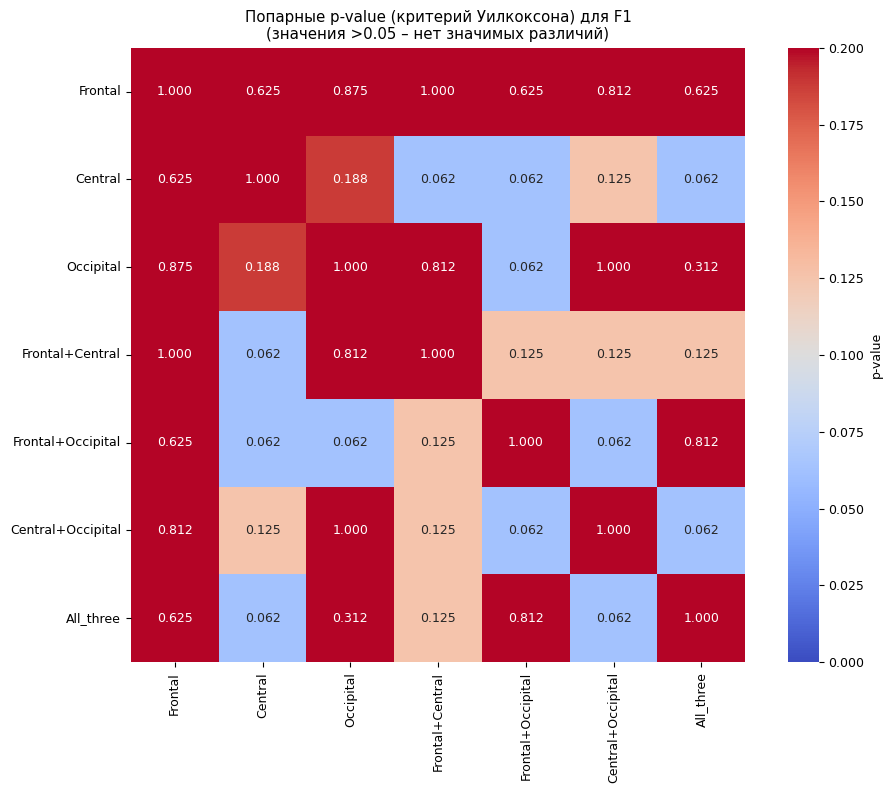

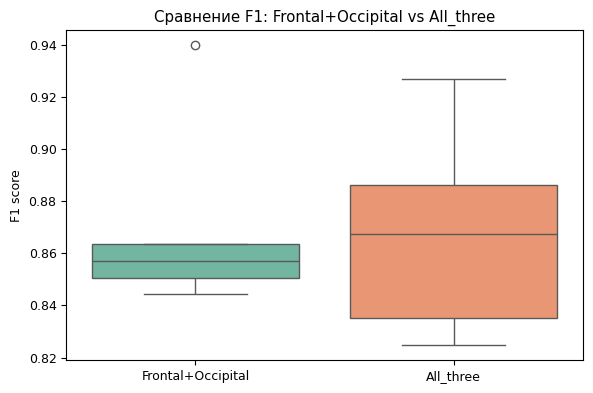


Все графики сохранены.
Интерпретация: если p-value > 0.05, различия статистически не значимы.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon
import itertools

# 1. Загрузка данных (если есть CSV – загружаем, иначе создаём из словарей)
try:
    auc_df = pd.read_csv('auc_by_fold_all_5fold.csv')
    f1_df = pd.read_csv('f1_by_fold_all_5fold.csv')
    print("Загружены CSV-файлы")
except FileNotFoundError:
    # Если CSV нет, используем переменные из памяти (предполагаем, что они есть)
    auc_df = pd.DataFrame.from_dict(auc_by_fold_all)
    f1_df = pd.DataFrame.from_dict(f1_by_fold_all)
    print("Созданы DataFrame из словарей")

print("AUC по фолдам (5 фолдов, 7 областей):")
print(auc_df)
print("\nF1 по фолдам:")
print(f1_df)

# 2. Boxplot для F1 и AUC
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.boxplot(data=f1_df, palette='Set2')
plt.title('Распределение F1 по 5 фолдам')
plt.xticks(rotation=45)
plt.ylabel('F1 score')
plt.subplot(1,2,2)
sns.boxplot(data=auc_df, palette='Set2')
plt.title('Распределение AUC по 5 фолдам')
plt.xticks(rotation=45)
plt.ylabel('AUC')
plt.tight_layout()
plt.savefig('boxplot_f1_auc_across_folds.png', dpi=150)
plt.show()

# 3. Точечный график (dot plot) для сравнения двух лучших конфигураций
# Определим лучшие по среднему F1
mean_f1 = f1_df.mean().sort_values(ascending=False)
best_two = mean_f1.index[:2].tolist()
print(f"\nДве лучшие конфигурации по F1: {best_two}")

x = np.arange(5)  # номера фолдов
plt.figure(figsize=(8,5))
for cfg in best_two:
    plt.plot(x, f1_df[cfg], 'o-', label=cfg, linewidth=2, markersize=8)
plt.xlabel('Fold number')
plt.ylabel('F1 score')
plt.title(f'Сравнение F1 по фолдам: {best_two[0]} vs {best_two[1]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('dot_plot_best_two_f1.png', dpi=150)
plt.show()

# 4. График средних значений с 95% доверительными интервалами (error bar plot)
def mean_ci(data, confidence=0.95):
    n = len(data)
    m = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, h  # возвращаем среднее и полуширину

regions = f1_df.columns
means = []
errs = []
for reg in regions:
    m, h = mean_ci(f1_df[reg].values)
    means.append(m)
    errs.append(h)

plt.figure(figsize=(10,6))
plt.errorbar(x=regions, y=means, yerr=errs, fmt='o', capsize=5, capthick=2, elinewidth=2, markersize=8, color='darkblue')
plt.xticks(rotation=45)
plt.ylabel('F1 score')
plt.title('Средняя F1 с 95% доверительными интервалами (5 фолдов)')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('f1_with_ci.png', dpi=150)
plt.show()

# 5. Матрица попарных p-value (критерий Уилкоксона) для всех конфигураций (по F1)
# Вычисляем все попарные p-values
configs = f1_df.columns.tolist()
n = len(configs)
p_matrix = np.ones((n, n))
for i, j in itertools.combinations(range(n), 2):
    # парный тест Уилкоксона для связанных выборок (по фолдам)
    stat, p = wilcoxon(f1_df[configs[i]], f1_df[configs[j]])
    p_matrix[i, j] = p
    p_matrix[j, i] = p

# Создаём DataFrame для тепловой карты
p_df = pd.DataFrame(p_matrix, index=configs, columns=configs)

# Применяем поправку Бонферрони (не обязательно, но для корректности)
# p_df_bonf = p_df * (n*(n-1)//2)  # можно не применять, оставить как есть для наглядности

plt.figure(figsize=(10,8))
sns.heatmap(p_df, annot=True, fmt='.3f', cmap='coolwarm', square=True,
            cbar_kws={'label': 'p-value'}, vmin=0, vmax=0.2)  # ограничим шкалу для наглядности
plt.title('Попарные p-value (критерий Уилкоксона) для F1\n(значения >0.05 – нет значимых различий)')
plt.tight_layout()
plt.savefig('pairwise_pvalues_f1.png', dpi=150)
plt.show()

# 6. Дополнительно: boxplot только для двух лучших конфигураций (укрупнённо)
plt.figure(figsize=(6,4))
sns.boxplot(data=f1_df[best_two], palette='Set2')
plt.title(f'Сравнение F1: {best_two[0]} vs {best_two[1]}')
plt.ylabel('F1 score')
plt.tight_layout()
plt.savefig('boxplot_best_two.png', dpi=150)
plt.show()

print("\nВсе графики сохранены.")
print("Интерпретация: если p-value > 0.05, различия статистически не значимы.")

# Мультиклассовая классификация на 4 класса

Размер df_a2_clean: (277883, 162)
Создано производных признаков: 78
Всего признаков эпох: 210
Распределение по 4 классам:
severity
0    100
1     32
2     40
3    133
Name: count, dtype: int64
Всего пациентов: 305

--- Frontal (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  Отобрано признаков: 90
    RF ... MacroF1=0.333±0.047, Kappa=0.279, время=3.8с
    XGB ... MacroF1=0.308±0.024, Kappa=0.241, время=47.8с
    SVM ... MacroF1=0.113±0.035, Kappa=0.036, время=0.5с

--- Central (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  Отобрано признаков: 90
    RF ... MacroF1=0.332±0.037, Kappa=0.273, время=5.3с
    XGB ... MacroF1=0.352±0.024, Kappa=0.268, время=45.6с
    SVM ... MacroF1=0.094±0.034, Kappa=0.023, время=0.9с

--- Occipital (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  Отобрано признаков: 90
    RF ... MacroF1=0.295±0.026, Kappa=0.227, время=4.6с
    XGB ... MacroF1=0.332±0.0

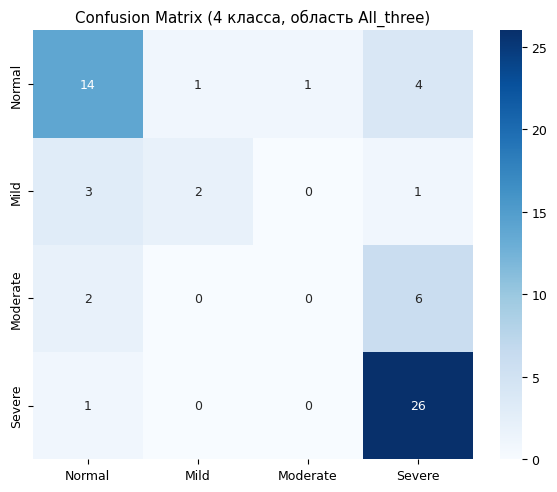

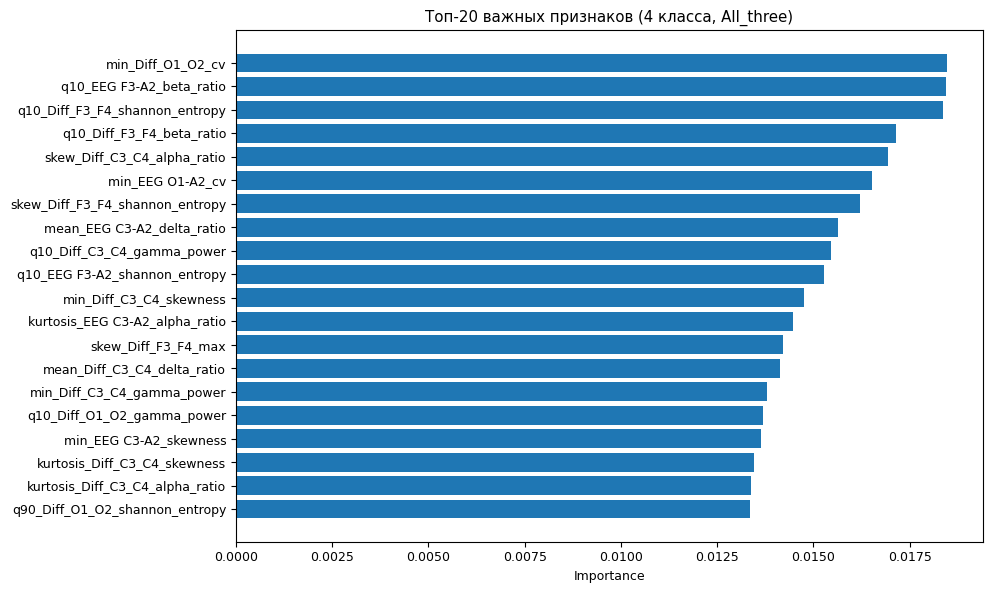

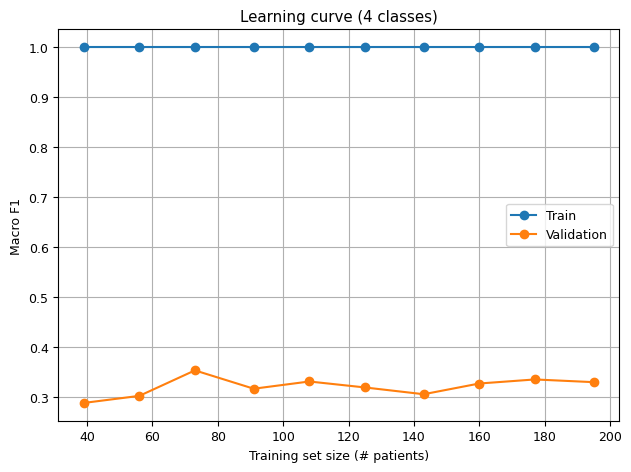

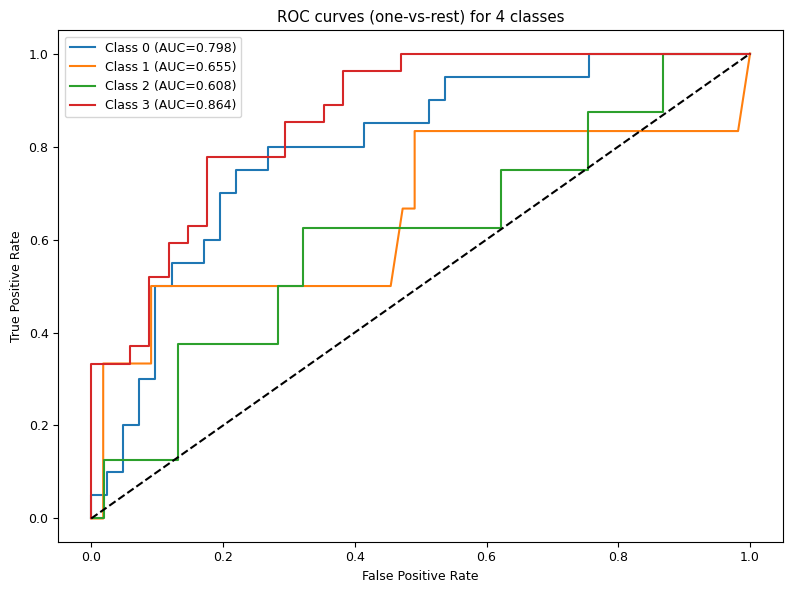


Графики для 4 классов сохранены.


In [ ]:
# ====================================================================
# МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ (4 КЛАССА) – СТЕПЕНИ ТЯЖЕСТИ
# ====================================================================
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split, learning_curve
from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             cohen_kappa_score, classification_report)
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from scipy.stats.mstats import winsorize

# ------------------------------------------------------------
# 1. ПРОВЕРКА ИСХОДНЫХ ДАННЫХ
# ------------------------------------------------------------
if 'df_a2_clean' not in locals():
    raise NameError("Нет df_a2_clean. Сначала выполните код загрузки и очистки.")
print(f"Размер df_a2_clean: {df_a2_clean.shape}")

# ------------------------------------------------------------
# 2. СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ (те же, что в бинарной)
# ------------------------------------------------------------
a2_cols = [c for c in df_a2_clean.columns if '-A2_' in c]
X_base = df_a2_clean[a2_cols].copy()
groups = df_a2_clean['filename'].values

suffixes = sorted(set([col.split('A2_')[-1] for col in a2_cols]))
left = ['F3', 'C3', 'O1']; right = ['F4', 'C4', 'O2']
derived = {}
for suf in suffixes:
    for l, r in zip(left, right):
        cl = f'EEG {l}-A2_{suf}'
        cr = f'EEG {r}-A2_{suf}'
        if cl in X_base.columns and cr in X_base.columns:
            derived[f'Diff_{l}_{r}_{suf}'] = X_base[cl] - X_base[cr]
for lead in ['F3', 'C3', 'O1', 'F4', 'C4', 'O2']:
    delta = f'EEG {lead}-A2_delta_power'
    beta = f'EEG {lead}-A2_beta_power'
    theta = f'EEG {lead}-A2_theta_power'
    alpha = f'EEG {lead}-A2_alpha_power'
    if delta in X_base.columns and beta in X_base.columns:
        derived[f'Ratio_{lead}_delta_beta'] = X_base[delta] / (X_base[beta] + 1e-10)
    if theta in X_base.columns and alpha in X_base.columns:
        derived[f'Ratio_{lead}_theta_alpha'] = X_base[theta] / (X_base[alpha] + 1e-10)
X_derived = pd.concat([X_base, pd.DataFrame(derived)], axis=1)
print(f"Создано производных признаков: {len(derived)}")
print(f"Всего признаков эпох: {X_derived.shape[1]}")

# ------------------------------------------------------------
# 3. РАСЧЁТ AHI И МЕТКИ СТЕПЕНЕЙ ТЯЖЕСТИ (4 КЛАССА)
# ------------------------------------------------------------
patient_ahi = []
for name, group in df_a2_clean.groupby('filename'):
    total_events = group['apnea_count'].sum() + group['hypopnea_count'].sum()
    sleep_hours = len(group) * 30 / 3600.0
    if sleep_hours < 0.5:
        sleep_hours = 1.0
    ahi = total_events / sleep_hours
    patient_ahi.append({'patient_id': name, 'AHI': ahi})
df_ahi = pd.DataFrame(patient_ahi)

# Функция категоризации (4 класса)
def severity_4(ahi):
    if ahi < 5:
        return 0   # Normal
    elif ahi < 15:
        return 1   # Mild
    elif ahi < 30:
        return 2   # Moderate
    else:
        return 3   # Severe

df_ahi['severity'] = df_ahi['AHI'].apply(severity_4)
print("Распределение по 4 классам:")
print(df_ahi['severity'].value_counts().sort_index())
print(f"Всего пациентов: {len(df_ahi)}")

# ------------------------------------------------------------
# 4. ФУНКЦИЯ АГРЕГАЦИИ (та же, что в бинарной)
# ------------------------------------------------------------
def aggregate_patient_features_safe(X_epochs, groups, region_cols, extra_stats=True):
    X_region = X_epochs[region_cols].copy()
    X_region = X_region.copy()
    X_region['_group'] = groups
    if extra_stats:
        agg_funcs = {
            'mean': np.mean,
            'median': np.median,
            'std': np.std,
            'min': np.min,
            'max': np.max,
            'skew': lambda x: skew(x, nan_policy='omit'),
            'kurtosis': lambda x: kurtosis(x, nan_policy='omit'),
            'q10': lambda x: x.quantile(0.1),
            'q90': lambda x: x.quantile(0.9)
        }
    else:
        agg_funcs = {
            'mean': np.mean,
            'median': np.median,
            'std': np.std,
            'min': np.min,
            'max': np.max
        }
    agg_data = {}
    for stat_name, func in agg_funcs.items():
        agg_data[stat_name] = X_region.groupby('_group')[region_cols].agg(func)
    aggregated = pd.concat(agg_data, axis=1)
    aggregated.columns = [f"{col[0]}_{col[1]}" for col in aggregated.columns]
    aggregated = aggregated.reset_index().rename(columns={'_group': 'patient_id'})
    aggregated = aggregated.fillna(0)
    return aggregated

# ------------------------------------------------------------
# 5. ФУНКЦИЯ ОТБОРА ПРИЗНАКОВ (ДЛЯ МУЛЬТИКЛАССА)
# ------------------------------------------------------------
def select_features_multiclass(X_train, y_train, n_features=90, random_state=42):
    # Для мультикласса используем f_classif и mutual_info_classif (они поддерживают multiclass)
    y_train = np.ravel(y_train)
    sel_f = SelectKBest(f_classif, k=n_features).fit(X_train, y_train)
    sel_mi = SelectKBest(mutual_info_classif, k=n_features).fit(X_train, y_train)
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    f_sel = set(sel_f.get_feature_names_out())
    mi_sel = set(sel_mi.get_feature_names_out())
    rf_sel = set(X_train.columns[np.argsort(rf_temp.feature_importances_)[-n_features:]])
    consensus = list(f_sel.union(mi_sel).union(rf_sel))
    if len(consensus) > n_features:
        rf_temp.fit(X_train[consensus], y_train)
        imp = rf_temp.feature_importances_
        consensus = [consensus[i] for i in np.argsort(imp)[-n_features:]]
    return X_train[consensus], consensus

# ------------------------------------------------------------
# 6. ФУНКЦИЯ ОЦЕНКИ С ВОЗВРАТОМ МЕТРИК ПО ФОЛДАМ (МУЛЬТИКЛАСС)
# ------------------------------------------------------------
def evaluate_multiclass_cv(X, y, model, n_folds=5, random_state=42, winsorize_limits=(0.01, 0.01)):
    """
    Оценка мультиклассовой модели с внутренним отбором признаков (консенсус) на каждом фолде.

    Параметры:
    - X: pd.DataFrame, признаки (пациенты × признаки)
    - y: np.array, целевая переменная (0,1,2)
    - model: объект модели (RF, XGB, SVM)
    - n_folds: int, число фолдов
    - random_state: int
    - winsorize_limits: tuple, нижний и верхний процентили для обрезания выбросов (если None – не применять)

    Возвращает:
    - словарь со средними и списками метрик по фолдам
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    acc_list = []
    macro_f1_list = []
    weighted_f1_list = []
    kappa_list = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_tr_fold = y[train_idx]
        y_val_fold = y[val_idx]

        # ---------- 1. Винсоризация (обрезание выбросов) ----------
        if winsorize_limits is not None:
            X_tr_fold = X_tr_fold.apply(lambda col: winsorize(col, limits=winsorize_limits))
            X_val_fold = X_val_fold.apply(lambda col: winsorize(col, limits=winsorize_limits))

        # ---------- 2. Отбор признаков (консенсус) ТОЛЬКО на обучающем фолде ----------
        if X_tr_fold.shape[1] > 90:
            # 2a. ANOVA F-value
            sel_f = SelectKBest(f_classif, k=90)
            sel_f.fit(X_tr_fold, y_tr_fold)
            f_selected = set(sel_f.get_feature_names_out())
            # 2b. Mutual information
            sel_mi = SelectKBest(mutual_info_classif, k=90)
            sel_mi.fit(X_tr_fold, y_tr_fold)
            mi_selected = set(sel_mi.get_feature_names_out())
            # 2c. Random Forest importance
            rf_temp = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
            rf_temp.fit(X_tr_fold, y_tr_fold)
            importances = rf_temp.feature_importances_
            rf_selected = set(X_tr_fold.columns[np.argsort(importances)[-90:]])
            # 2d. Консенсус
            consensus = list(f_selected.union(mi_selected).union(rf_selected))
            if len(consensus) > 90:
                rf_temp.fit(X_tr_fold[consensus], y_tr_fold)
                imp = rf_temp.feature_importances_
                consensus = [consensus[i] for i in np.argsort(imp)[-90:]]
            X_tr_sel = X_tr_fold[consensus]
            X_val_sel = X_val_fold[consensus]
        else:
            X_tr_sel = X_tr_fold
            X_val_sel = X_val_fold

        # ---------- 3. Масштабирование ----------
        scaler = RobustScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_sel)
        X_val_scaled = scaler.transform(X_val_sel)

        # ---------- 4. Обучение модели ----------
        m = model.__class__(**model.get_params())
        m.fit(X_tr_scaled, y_tr_fold)
        y_pred = m.predict(X_val_scaled)

        # ---------- 5. Метрики ----------
        acc_list.append(accuracy_score(y_val_fold, y_pred))
        macro_f1_list.append(f1_score(y_val_fold, y_pred, average='macro'))
        weighted_f1_list.append(f1_score(y_val_fold, y_pred, average='weighted'))
        kappa_list.append(cohen_kappa_score(y_val_fold, y_pred))

    return {
        'Accuracy_mean': np.mean(acc_list), 'Accuracy_std': np.std(acc_list),
        'Macro_F1_mean': np.mean(macro_f1_list), 'Macro_F1_std': np.std(macro_f1_list),
        'Weighted_F1_mean': np.mean(weighted_f1_list), 'Weighted_F1_std': np.std(weighted_f1_list),
        'Kappa_mean': np.mean(kappa_list), 'Kappa_std': np.std(kappa_list),
        'Accuracy_list': acc_list, 'Macro_F1_list': macro_f1_list,
        'Weighted_F1_list': weighted_f1_list, 'Kappa_list': kappa_list
    }

# ------------------------------------------------------------
# 7. ОПРЕДЕЛЕНИЕ 7 ОБЛАСТЕЙ
# ------------------------------------------------------------
regions = {
    'Frontal': [c for c in X_derived.columns if 'F3' in c or 'F4' in c],
    'Central': [c for c in X_derived.columns if 'C3' in c or 'C4' in c],
    'Occipital': [c for c in X_derived.columns if 'O1' in c or 'O2' in c],
    'Frontal+Central': [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'C3' in c or 'C4' in c)],
    'Frontal+Occipital': [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'O1' in c or 'O2' in c)],
    'Central+Occipital': [c for c in X_derived.columns if ('C3' in c or 'C4' in c or 'O1' in c or 'O2' in c)],
    'All_three': [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'C3' in c or 'C4' in c or 'O1' in c or 'O2' in c)]
}

# ------------------------------------------------------------
# 8. МОДЕЛИ (ДЛЯ МУЛЬТИКЛАССА)
# ------------------------------------------------------------
models = {
    'RF': RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                         # Для мультикласса используем multi:softmax
                         objective='multi:softmax', num_class=4,
                         reg_alpha=0.5, reg_lambda=1.0, random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=42, decision_function_shape='ovr')
}

# ------------------------------------------------------------
# 9. ОСНОВНОЙ ЦИКЛ КРОСС-ВАЛИДАЦИИ (5 ФОЛДОВ)
# ------------------------------------------------------------
N_FEATURES = 90
cv_results = {}

for region_name, region_cols in regions.items():
    print(f"\n--- {region_name} (исходно {len(region_cols)} признаков эпох) ---")
    X_patient = aggregate_patient_features_safe(X_derived, groups, region_cols, extra_stats=True)
    X_patient = X_patient.merge(df_ahi[['patient_id', 'severity']], on='patient_id', how='inner')
    y = X_patient['severity'].values
    X_raw = X_patient.drop(columns=['patient_id', 'severity'])
    print(f"  Пациентов: {len(y)}, признаков после агрегации: {X_raw.shape[1]}")
    if X_raw.shape[1] > N_FEATURES:
        X_sel, _ = select_features_multiclass(X_raw, y, n_features=N_FEATURES)
        print(f"  Отобрано признаков: {X_sel.shape[1]}")
    else:
        X_sel = X_raw
        print(f"  Отбор не выполнен (признаков <= {N_FEATURES})")
    region_res = {}
    for name, model in models.items():
        print(f"    {name} ...", end='', flush=True)
        start = time.time()
        metrics = evaluate_multiclass_cv(X_sel, y, model, n_folds=5)
        elapsed = time.time() - start
        print(f" MacroF1={metrics['Macro_F1_mean']:.3f}±{metrics['Macro_F1_std']:.3f}, Kappa={metrics['Kappa_mean']:.3f}, время={elapsed:.1f}с")
        region_res[name] = metrics
    cv_results[region_name] = region_res

# ------------------------------------------------------------
# 10. СВОДНАЯ ТАБЛИЦА (ЛУЧШАЯ МОДЕЛЬ ПО MACRO F1)
# ------------------------------------------------------------
summary_rows = []
for region, res_dict in cv_results.items():
    best_model = max(res_dict.keys(), key=lambda m: res_dict[m]['Macro_F1_mean'])
    best = res_dict[best_model]
    summary_rows.append({
        'Region': region,
        'Best_Model': best_model,
        'Macro_F1': f"{best['Macro_F1_mean']:.3f} ± {best['Macro_F1_std']:.3f}",
        'Weighted_F1': f"{best['Weighted_F1_mean']:.3f} ± {best['Weighted_F1_std']:.3f}",
        'Accuracy': f"{best['Accuracy_mean']:.3f} ± {best['Accuracy_std']:.3f}",
        'Kappa': f"{best['Kappa_mean']:.3f} ± {best['Kappa_std']:.3f}"
    })
df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*90)
print("СВОДНАЯ ТАБЛИЦА (5-ФОЛДОВАЯ КРОСС-ВАЛИДАЦИЯ, 4 КЛАССА)")
print("="*90)
print(df_summary.to_string())
df_summary.to_csv('multiclass_4classes_cv_5fold.csv', index=False)
print("Сохранено: multiclass_4classes_cv_5fold.csv")

# ------------------------------------------------------------
# 11. СОХРАНЕНИЕ МЕТРИК ПО ФОЛДАМ ДЛЯ ВСЕХ ОБЛАСТЕЙ
# ------------------------------------------------------------
macro_f1_by_fold = {}
kappa_by_fold = {}
for region_name, res_dict in cv_results.items():
    best_model = max(res_dict.keys(), key=lambda m: res_dict[m]['Macro_F1_mean'])
    macro_f1_by_fold[region_name] = res_dict[best_model]['Macro_F1_list']
    kappa_by_fold[region_name] = res_dict[best_model]['Kappa_list']

pd.DataFrame(macro_f1_by_fold).to_csv('macro_f1_by_fold_4classes.csv', index=False)
pd.DataFrame(kappa_by_fold).to_csv('kappa_by_fold_4classes.csv', index=False)
print("Сохранены: macro_f1_by_fold_4classes.csv, kappa_by_fold_4classes.csv")

# ------------------------------------------------------------
# 12. ДЛЯ ЛУЧШЕЙ ОБЛАСТИ (ПО MACRO F1): TRAIN/TEST И ВИЗУАЛИЗАЦИИ
# ------------------------------------------------------------
best_region = df_summary.iloc[(df_summary['Macro_F1'].str.split(' ± ').apply(lambda x: float(x[0]))).idxmax()]['Region']
print(f"\nЛучшая область по Macro F1: {best_region}")

region_cols_best = regions[best_region]
X_patient_best = aggregate_patient_features_safe(X_derived, groups, region_cols_best, extra_stats=True)
X_patient_best = X_patient_best.merge(df_ahi[['patient_id', 'severity']], on='patient_id', how='inner')
y_best = X_patient_best['severity'].values
X_best_raw = X_patient_best.drop(columns=['patient_id', 'severity'])
if X_best_raw.shape[1] > N_FEATURES:
    X_best_sel, _ = select_features_multiclass(X_best_raw, y_best, n_features=N_FEATURES)
else:
    X_best_sel = X_best_raw

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_best_sel, y_best, test_size=0.2, random_state=42, stratify=y_best)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Лучшая модель (Random Forest для важности признаков)
best_estimator = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
best_estimator.fit(X_train_scaled, y_train)
y_pred = best_estimator.predict(X_test_scaled)
y_proba = best_estimator.predict_proba(X_test_scaled)

# Метрики на тесте
test_acc = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average='macro')
test_weighted_f1 = f1_score(y_test, y_pred, average='weighted')
test_kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nРезультаты на тестовой выборке (лучшая область {best_region}):")
print(f"  Accuracy = {test_acc:.3f}, Macro F1 = {test_macro_f1:.3f}, Weighted F1 = {test_weighted_f1:.3f}, Kappa = {test_kappa:.3f}")

# ------------------------------------------------------------
# 13. ГРАФИКИ
# ------------------------------------------------------------
plt.rcParams['font.size'] = 9

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Mild', 'Moderate', 'Severe'],
            yticklabels=['Normal', 'Mild', 'Moderate', 'Severe'])
plt.title(f'Confusion Matrix (4 класса, область {best_region})')
plt.tight_layout()
plt.savefig('confusion_matrix_4classes.png', dpi=150)
plt.show()

# Важность признаков (топ-20)
importances = best_estimator.feature_importances_
indices = np.argsort(importances)[::-1][:20]
plt.figure(figsize=(10,6))
plt.barh(range(20), importances[indices][::-1])
plt.yticks(range(20), [X_best_sel.columns[i] for i in indices[::-1]])
plt.xlabel('Importance')
plt.title(f'Топ-20 важных признаков (4 класса, {best_region})')
plt.tight_layout()
plt.savefig('feature_importance_4classes.png', dpi=150)
plt.show()

# Кривая обучения
train_sizes, train_scores, test_scores = learning_curve(
    best_estimator, X_train_scaled, y_train, cv=5, scoring='f1_macro',
    train_sizes=np.linspace(0.2, 1.0, 10), n_jobs=-1
)
plt.figure()
plt.plot(train_sizes, np.mean(train_scores,1), 'o-', label='Train')
plt.plot(train_sizes, np.mean(test_scores,1), 'o-', label='Validation')
plt.xlabel('Training set size (# patients)')
plt.ylabel('Macro F1')
plt.title('Learning curve (4 classes)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve_4classes.png', dpi=150)
plt.show()

# ROC-кривые (one-vs-rest) для каждого класса
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
n_classes = 4
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves (one-vs-rest) for 4 classes')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves_4classes.png', dpi=150)
plt.show()

print("\nГрафики для 4 классов сохранены.")

Мультиклассовая классификация на четыре степени тяжести (норма, лёгкая, средняя, тяжёлая) показала низкие метрики (макро F1 = 0.387, каппа = 0.36). Основные причины: сильный дисбаланс классов (лёгкая и средняя степени составляют лишь 23% выборки), перекрытие AHI в пограничной области (5–30) и недостаточная дифференцирующая способность ЭЭГ-признаков для тонкой градации тяжести. Матрица ошибок (рис. …) демонстрирует, что классы лёгкой и средней степеней практически не распознаются, а большинство ошибочных предсказаний приходится на нормальный и тяжёлый классы. Поэтому для дальнейшего анализа целесообразно объединить лёгкую и среднюю степени в одну группу, сфокусировавшись на трёх классах: норма, умеренное апноэ (лёгкое+среднее) и тяжёлое апноэ.

# Мультииклассовая класссификация на 3 класса

Размер df_a2_clean: (277883, 162)
Создано производных признаков: 78
Всего признаков эпох: 210
Распределение по 3 классам:
severity
0    100
1     72
2    133
Name: count, dtype: int64
Всего пациентов: 305

--- Frontal (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  Отобрано признаков: 90
    RF ... MacroF1=0.462±0.045, Kappa=0.252, время=5.9с
    XGB ... MacroF1=0.462±0.042, Kappa=0.260, время=40.3с
    SVM ... MacroF1=0.209±0.087, Kappa=0.041, время=0.5с

--- Central (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  Отобрано признаков: 90
    RF ... MacroF1=0.455±0.053, Kappa=0.275, время=5.6с
    XGB ... MacroF1=0.468±0.041, Kappa=0.257, время=41.3с
    SVM ... MacroF1=0.249±0.062, Kappa=0.054, время=0.5с

--- Occipital (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  Отобрано признаков: 90
    RF ... MacroF1=0.491±0.055, Kappa=0.281, время=6.1с
    XGB ... MacroF1=0.516±0.033, Kappa

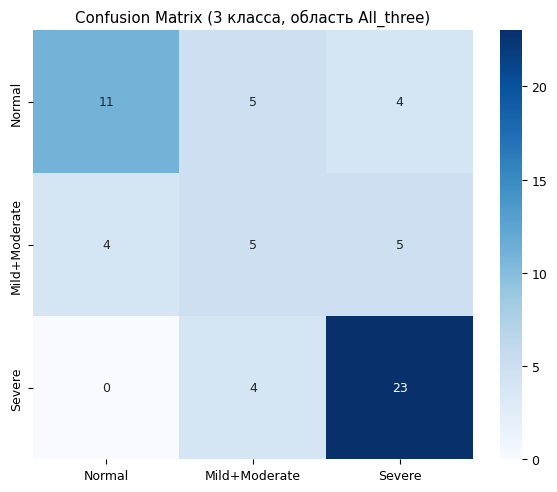

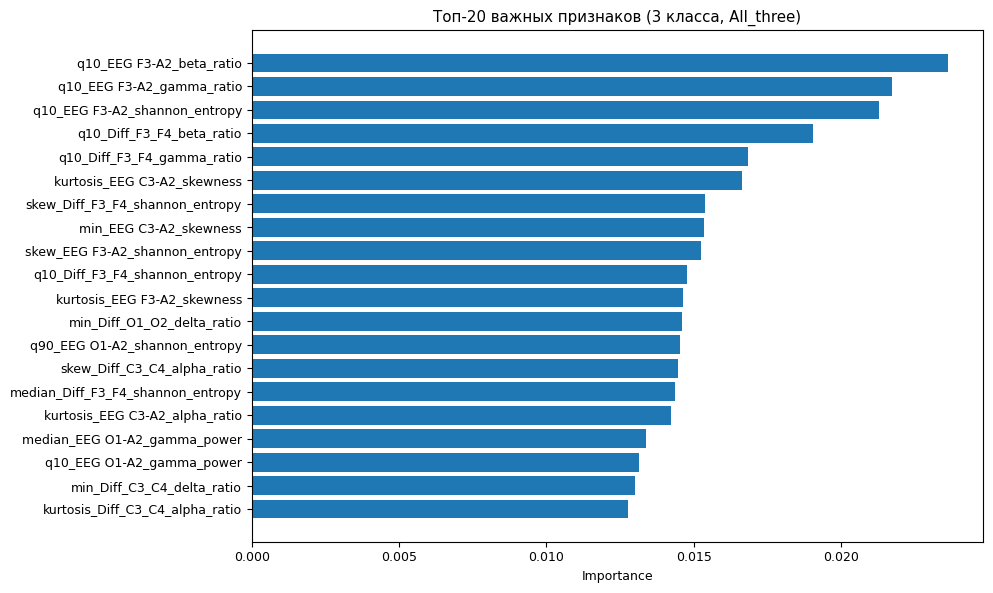

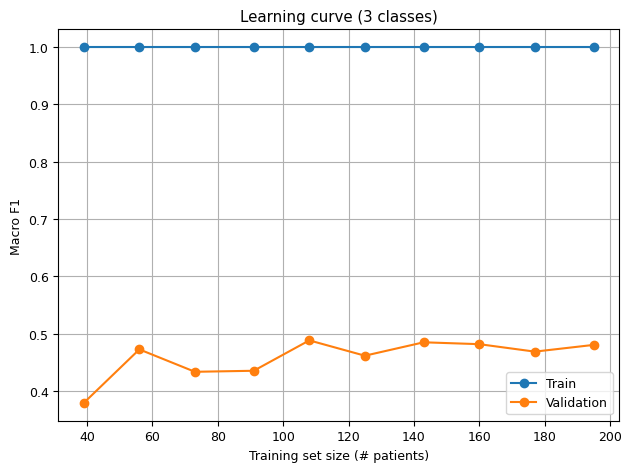

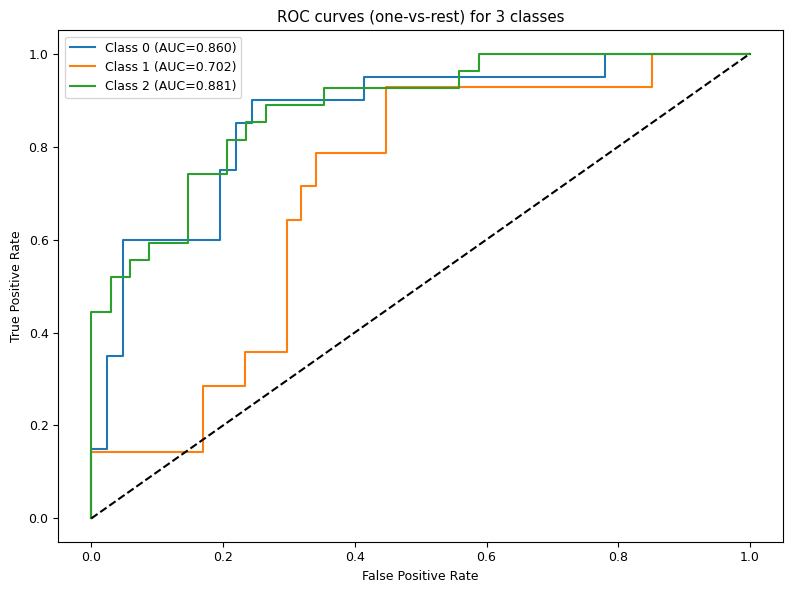


Все графики для 3 классов сохранены.


In [ ]:
# ====================================================================
# МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ (3 КЛАССА): НОРМА, ЛЁГКАЯ+СРЕДНЯЯ, ТЯЖЁЛАЯ
# ====================================================================
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split, learning_curve
from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             cohen_kappa_score, classification_report)
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# 1. ПРОВЕРКА ИСХОДНЫХ ДАННЫХ
# ------------------------------------------------------------
if 'df_a2_clean' not in locals():
    raise NameError("Нет df_a2_clean. Сначала выполните код загрузки и очистки.")
print(f"Размер df_a2_clean: {df_a2_clean.shape}")

# ------------------------------------------------------------
# 2. СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ (те же, что в бинарной)
# ------------------------------------------------------------
a2_cols = [c for c in df_a2_clean.columns if '-A2_' in c]
X_base = df_a2_clean[a2_cols].copy()
groups = df_a2_clean['filename'].values

suffixes = sorted(set([col.split('A2_')[-1] for col in a2_cols]))
left = ['F3', 'C3', 'O1']; right = ['F4', 'C4', 'O2']
derived = {}
for suf in suffixes:
    for l, r in zip(left, right):
        cl = f'EEG {l}-A2_{suf}'
        cr = f'EEG {r}-A2_{suf}'
        if cl in X_base.columns and cr in X_base.columns:
            derived[f'Diff_{l}_{r}_{suf}'] = X_base[cl] - X_base[cr]
for lead in ['F3', 'C3', 'O1', 'F4', 'C4', 'O2']:
    delta = f'EEG {lead}-A2_delta_power'
    beta = f'EEG {lead}-A2_beta_power'
    theta = f'EEG {lead}-A2_theta_power'
    alpha = f'EEG {lead}-A2_alpha_power'
    if delta in X_base.columns and beta in X_base.columns:
        derived[f'Ratio_{lead}_delta_beta'] = X_base[delta] / (X_base[beta] + 1e-10)
    if theta in X_base.columns and alpha in X_base.columns:
        derived[f'Ratio_{lead}_theta_alpha'] = X_base[theta] / (X_base[alpha] + 1e-10)

X_derived = pd.concat([X_base, pd.DataFrame(derived)], axis=1)
print(f"Создано производных признаков: {len(derived)}")
print(f"Всего признаков эпох: {X_derived.shape[1]}")

# ------------------------------------------------------------
# 3. РАСЧЁТ AHI И МЕТКИ СТЕПЕНЕЙ ТЯЖЕСТИ (3 КЛАССА)
# ------------------------------------------------------------
patient_ahi = []
for name, group in df_a2_clean.groupby('filename'):
    total_events = group['apnea_count'].sum() + group['hypopnea_count'].sum()
    sleep_hours = len(group) * 30 / 3600.0
    if sleep_hours < 0.5:
        sleep_hours = 1.0
    ahi = total_events / sleep_hours
    patient_ahi.append({'patient_id': name, 'AHI': ahi})
df_ahi = pd.DataFrame(patient_ahi)

# Функция категоризации (3 класса: Normal, Mild+Moderate, Severe)
def severity_3(ahi):
    if ahi < 5:
        return 0   # Normal
    elif ahi < 30:
        return 1   # Mild+Moderate
    else:
        return 2   # Severe

df_ahi['severity'] = df_ahi['AHI'].apply(severity_3)
print("Распределение по 3 классам:")
print(df_ahi['severity'].value_counts().sort_index())
print(f"Всего пациентов: {len(df_ahi)}")

# ------------------------------------------------------------
# 4. ФУНКЦИИ АГРЕГАЦИИ, ОТБОРА, ОЦЕНКИ (те же, что в 4-классовом коде, только num_class=3)
# ------------------------------------------------------------
def aggregate_patient_features_safe(X_epochs, groups, region_cols, extra_stats=True):
    X_region = X_epochs[region_cols].copy()
    X_region = X_region.copy()
    X_region['_group'] = groups
    if extra_stats:
        agg_funcs = {
            'mean': np.mean,
            'median': np.median,
            'std': np.std,
            'min': np.min,
            'max': np.max,
            'skew': lambda x: skew(x, nan_policy='omit'),
            'kurtosis': lambda x: kurtosis(x, nan_policy='omit'),
            'q10': lambda x: x.quantile(0.1),
            'q90': lambda x: x.quantile(0.9)
        }
    else:
        agg_funcs = {
            'mean': np.mean,
            'median': np.median,
            'std': np.std,
            'min': np.min,
            'max': np.max
        }
    agg_data = {}
    for stat_name, func in agg_funcs.items():
        agg_data[stat_name] = X_region.groupby('_group')[region_cols].agg(func)
    aggregated = pd.concat(agg_data, axis=1)
    aggregated.columns = [f"{col[0]}_{col[1]}" for col in aggregated.columns]
    aggregated = aggregated.reset_index().rename(columns={'_group': 'patient_id'})
    aggregated = aggregated.fillna(0)
    return aggregated

def select_features_multiclass(X_train, y_train, n_features=90, random_state=42):
    y_train = np.ravel(y_train)
    sel_f = SelectKBest(f_classif, k=n_features).fit(X_train, y_train)
    sel_mi = SelectKBest(mutual_info_classif, k=n_features).fit(X_train, y_train)
    rf_temp = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    rf_temp.fit(X_train, y_train)
    f_sel = set(sel_f.get_feature_names_out())
    mi_sel = set(sel_mi.get_feature_names_out())
    rf_sel = set(X_train.columns[np.argsort(rf_temp.feature_importances_)[-n_features:]])
    consensus = list(f_sel.union(mi_sel).union(rf_sel))
    if len(consensus) > n_features:
        rf_temp.fit(X_train[consensus], y_train)
        imp = rf_temp.feature_importances_
        consensus = [consensus[i] for i in np.argsort(imp)[-n_features:]]
    return X_train[consensus], consensus

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from scipy.stats.mstats import winsorize

def evaluate_multiclass_cv(X, y, model, n_folds=5, random_state=42, winsorize_limits=(0.01, 0.01)):
    """
    Оценка мультиклассовой модели с внутренним отбором признаков (консенсус) на каждом фолде.

    Параметры:
    - X: pd.DataFrame, признаки (пациенты × признаки)
    - y: np.array, целевая переменная (0,1,2)
    - model: объект модели (RF, XGB, SVM)
    - n_folds: int, число фолдов
    - random_state: int
    - winsorize_limits: tuple, нижний и верхний процентили для обрезания выбросов (если None – не применять)

    Возвращает:
    - словарь со средними и списками метрик по фолдам
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    acc_list = []
    macro_f1_list = []
    weighted_f1_list = []
    kappa_list = []

    for train_idx, val_idx in skf.split(X, y):
        X_tr_fold = X.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_tr_fold = y[train_idx]
        y_val_fold = y[val_idx]

        # ---------- 1. Винсоризация (обрезание выбросов) ----------
        if winsorize_limits is not None:
            X_tr_fold = X_tr_fold.apply(lambda col: winsorize(col, limits=winsorize_limits))
            X_val_fold = X_val_fold.apply(lambda col: winsorize(col, limits=winsorize_limits))

        # ---------- 2. Отбор признаков (консенсус) ТОЛЬКО на обучающем фолде ----------
        if X_tr_fold.shape[1] > 90:
            # 2a. ANOVA F-value
            sel_f = SelectKBest(f_classif, k=90)
            sel_f.fit(X_tr_fold, y_tr_fold)
            f_selected = set(sel_f.get_feature_names_out())
            # 2b. Mutual information
            sel_mi = SelectKBest(mutual_info_classif, k=90)
            sel_mi.fit(X_tr_fold, y_tr_fold)
            mi_selected = set(sel_mi.get_feature_names_out())
            # 2c. Random Forest importance
            rf_temp = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
            rf_temp.fit(X_tr_fold, y_tr_fold)
            importances = rf_temp.feature_importances_
            rf_selected = set(X_tr_fold.columns[np.argsort(importances)[-90:]])
            # 2d. Консенсус
            consensus = list(f_selected.union(mi_selected).union(rf_selected))
            if len(consensus) > 90:
                rf_temp.fit(X_tr_fold[consensus], y_tr_fold)
                imp = rf_temp.feature_importances_
                consensus = [consensus[i] for i in np.argsort(imp)[-90:]]
            X_tr_sel = X_tr_fold[consensus]
            X_val_sel = X_val_fold[consensus]
        else:
            X_tr_sel = X_tr_fold
            X_val_sel = X_val_fold

        # ---------- 3. Масштабирование ----------
        scaler = RobustScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_sel)
        X_val_scaled = scaler.transform(X_val_sel)

        # ---------- 4. Обучение модели ----------
        m = model.__class__(**model.get_params())
        m.fit(X_tr_scaled, y_tr_fold)
        y_pred = m.predict(X_val_scaled)

        # ---------- 5. Метрики ----------
        acc_list.append(accuracy_score(y_val_fold, y_pred))
        macro_f1_list.append(f1_score(y_val_fold, y_pred, average='macro'))
        weighted_f1_list.append(f1_score(y_val_fold, y_pred, average='weighted'))
        kappa_list.append(cohen_kappa_score(y_val_fold, y_pred))

    return {
        'Accuracy_mean': np.mean(acc_list), 'Accuracy_std': np.std(acc_list),
        'Macro_F1_mean': np.mean(macro_f1_list), 'Macro_F1_std': np.std(macro_f1_list),
        'Weighted_F1_mean': np.mean(weighted_f1_list), 'Weighted_F1_std': np.std(weighted_f1_list),
        'Kappa_mean': np.mean(kappa_list), 'Kappa_std': np.std(kappa_list),
        'Accuracy_list': acc_list, 'Macro_F1_list': macro_f1_list,
        'Weighted_F1_list': weighted_f1_list, 'Kappa_list': kappa_list
    }

# ------------------------------------------------------------
# 5. ОПРЕДЕЛЕНИЕ 7 ОБЛАСТЕЙ (те же)
# ------------------------------------------------------------
regions = {
    'Frontal': [c for c in X_derived.columns if 'F3' in c or 'F4' in c],
    'Central': [c for c in X_derived.columns if 'C3' in c or 'C4' in c],
    'Occipital': [c for c in X_derived.columns if 'O1' in c or 'O2' in c],
    'Frontal+Central': [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'C3' in c or 'C4' in c)],
    'Frontal+Occipital': [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'O1' in c or 'O2' in c)],
    'Central+Occipital': [c for c in X_derived.columns if ('C3' in c or 'C4' in c or 'O1' in c or 'O2' in c)],
    'All_three': [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'C3' in c or 'C4' in c or 'O1' in c or 'O2' in c)]
}

# ------------------------------------------------------------
# 6. МОДЕЛИ (ДЛЯ 3 КЛАССОВ)
# ------------------------------------------------------------
models = {
    'RF': RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGB': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                         objective='multi:softmax', num_class=3,
                         reg_alpha=0.5, reg_lambda=1.0, random_state=42, eval_metric='mlogloss', use_label_encoder=False),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', probability=True, random_state=42, decision_function_shape='ovr')
}

# ------------------------------------------------------------
# 7. ОСНОВНОЙ ЦИКЛ КРОСС-ВАЛИДАЦИИ (5 ФОЛДОВ)
# ------------------------------------------------------------
N_FEATURES = 90
cv_results = {}

for region_name, region_cols in regions.items():
    print(f"\n--- {region_name} (исходно {len(region_cols)} признаков эпох) ---")
    X_patient = aggregate_patient_features_safe(X_derived, groups, region_cols, extra_stats=True)
    X_patient = X_patient.merge(df_ahi[['patient_id', 'severity']], on='patient_id', how='inner')
    y = X_patient['severity'].values
    X_raw = X_patient.drop(columns=['patient_id', 'severity'])
    print(f"  Пациентов: {len(y)}, признаков после агрегации: {X_raw.shape[1]}")
    if X_raw.shape[1] > N_FEATURES:
        X_sel, _ = select_features_multiclass(X_raw, y, n_features=N_FEATURES)
        print(f"  Отобрано признаков: {X_sel.shape[1]}")
    else:
        X_sel = X_raw
        print(f"  Отбор не выполнен (признаков <= {N_FEATURES})")
    region_res = {}
    for name, model in models.items():
        print(f"    {name} ...", end='', flush=True)
        start = time.time()
        metrics = evaluate_multiclass_cv(X_sel, y, model, n_folds=5)
        elapsed = time.time() - start
        print(f" MacroF1={metrics['Macro_F1_mean']:.3f}±{metrics['Macro_F1_std']:.3f}, Kappa={metrics['Kappa_mean']:.3f}, время={elapsed:.1f}с")
        region_res[name] = metrics
    cv_results[region_name] = region_res

# ------------------------------------------------------------
# 8. СВОДНАЯ ТАБЛИЦА (ЛУЧШАЯ МОДЕЛЬ ПО MACRO F1)
# ------------------------------------------------------------
summary_rows = []
for region, res_dict in cv_results.items():
    best_model = max(res_dict.keys(), key=lambda m: res_dict[m]['Macro_F1_mean'])
    best = res_dict[best_model]
    summary_rows.append({
        'Region': region,
        'Best_Model': best_model,
        'Macro_F1': f"{best['Macro_F1_mean']:.3f} ± {best['Macro_F1_std']:.3f}",
        'Weighted_F1': f"{best['Weighted_F1_mean']:.3f} ± {best['Weighted_F1_std']:.3f}",
        'Accuracy': f"{best['Accuracy_mean']:.3f} ± {best['Accuracy_std']:.3f}",
        'Kappa': f"{best['Kappa_mean']:.3f} ± {best['Kappa_std']:.3f}"
    })
df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*90)
print("СВОДНАЯ ТАБЛИЦА (5-ФОЛДОВАЯ КРОСС-ВАЛИДАЦИЯ, 3 КЛАССА)")
print("="*90)
print(df_summary.to_string())
df_summary.to_csv('multiclass_3classes_cv_5fold.csv', index=False)
print("Сохранено: multiclass_3classes_cv_5fold.csv")

# ------------------------------------------------------------
# 9. СОХРАНЕНИЕ МЕТРИК ПО ФОЛДАМ
# ------------------------------------------------------------
macro_f1_by_fold = {}
kappa_by_fold = {}
for region_name, res_dict in cv_results.items():
    best_model = max(res_dict.keys(), key=lambda m: res_dict[m]['Macro_F1_mean'])
    macro_f1_by_fold[region_name] = res_dict[best_model]['Macro_F1_list']
    kappa_by_fold[region_name] = res_dict[best_model]['Kappa_list']

pd.DataFrame(macro_f1_by_fold).to_csv('macro_f1_by_fold_3classes.csv', index=False)
pd.DataFrame(kappa_by_fold).to_csv('kappa_by_fold_3classes.csv', index=False)
print("Сохранены: macro_f1_by_fold_3classes.csv, kappa_by_fold_3classes.csv")

# ------------------------------------------------------------
# 10. ДЛЯ ЛУЧШЕЙ ОБЛАСТИ: TRAIN/TEST И ВИЗУАЛИЗАЦИИ
# ------------------------------------------------------------
best_region = df_summary.iloc[(df_summary['Macro_F1'].str.split(' ± ').apply(lambda x: float(x[0]))).idxmax()]['Region']
print(f"\nЛучшая область по Macro F1: {best_region}")

region_cols_best = regions[best_region]
X_patient_best = aggregate_patient_features_safe(X_derived, groups, region_cols_best, extra_stats=True)
X_patient_best = X_patient_best.merge(df_ahi[['patient_id', 'severity']], on='patient_id', how='inner')
y_best = X_patient_best['severity'].values
X_best_raw = X_patient_best.drop(columns=['patient_id', 'severity'])
if X_best_raw.shape[1] > N_FEATURES:
    X_best_sel, _ = select_features_multiclass(X_best_raw, y_best, n_features=N_FEATURES)
else:
    X_best_sel = X_best_raw

X_train, X_test, y_train, y_test = train_test_split(X_best_sel, y_best, test_size=0.2, random_state=42, stratify=y_best)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_estimator = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
best_estimator.fit(X_train_scaled, y_train)
y_pred = best_estimator.predict(X_test_scaled)
y_proba = best_estimator.predict_proba(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(y_test, y_pred, average='macro')
test_weighted_f1 = f1_score(y_test, y_pred, average='weighted')
test_kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nРезультаты на тестовой выборке (лучшая область {best_region}):")
print(f"  Accuracy = {test_acc:.3f}, Macro F1 = {test_macro_f1:.3f}, Weighted F1 = {test_weighted_f1:.3f}, Kappa = {test_kappa:.3f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Mild+Moderate', 'Severe'],
            yticklabels=['Normal', 'Mild+Moderate', 'Severe'])
plt.title(f'Confusion Matrix (3 класса, область {best_region})')
plt.tight_layout()
plt.savefig('confusion_matrix_3classes.png', dpi=150)
plt.show()

# Важность признаков
importances = best_estimator.feature_importances_
indices = np.argsort(importances)[::-1][:20]
plt.figure(figsize=(10,6))
plt.barh(range(20), importances[indices][::-1])
plt.yticks(range(20), [X_best_sel.columns[i] for i in indices[::-1]])
plt.xlabel('Importance')
plt.title(f'Топ-20 важных признаков (3 класса, {best_region})')
plt.tight_layout()
plt.savefig('feature_importance_3classes.png', dpi=150)
plt.show()

# Кривая обучения
train_sizes, train_scores, test_scores = learning_curve(
    best_estimator, X_train_scaled, y_train, cv=5, scoring='f1_macro',
    train_sizes=np.linspace(0.2, 1.0, 10), n_jobs=-1
)
plt.figure()
plt.plot(train_sizes, np.mean(train_scores,1), 'o-', label='Train')
plt.plot(train_sizes, np.mean(test_scores,1), 'o-', label='Validation')
plt.xlabel('Training set size (# patients)')
plt.ylabel('Macro F1')
plt.title('Learning curve (3 classes)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('learning_curve_3classes.png', dpi=150)
plt.show()

# ROC-кривые (one-vs-rest)
y_test_bin = label_binarize(y_test, classes=[0,1,2])
n_classes = 3
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc:.3f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves (one-vs-rest) for 3 classes')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves_3classes.png', dpi=150)
plt.show()

print("\nВсе графики для 3 классов сохранены.")

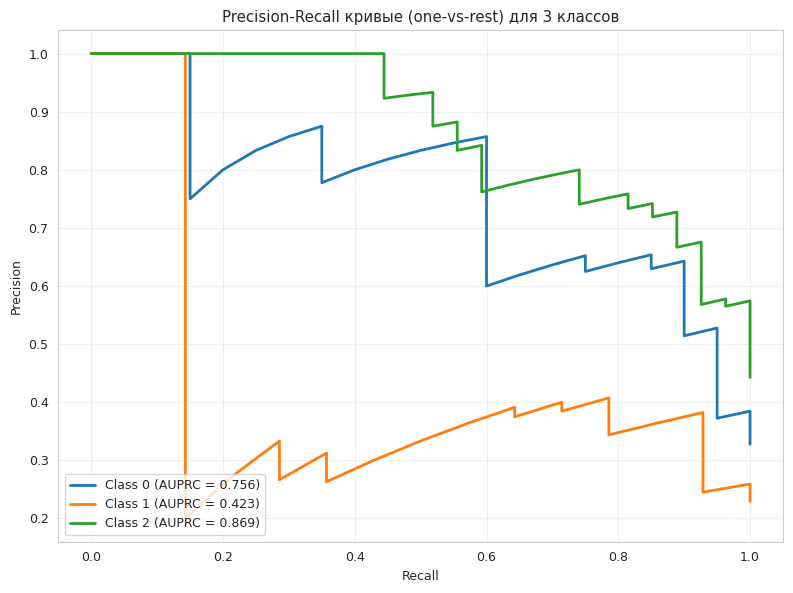

In [ ]:
# =====================================================
# PR-КРИВЫЕ ДЛЯ ТРЁХ КЛАССОВ (ONE-VS-REST)
# =====================================================
from sklearn.metrics import precision_recall_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Бинаризуем тестовые метки для трёх классов
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = 3

# Получаем вероятности принадлежности к каждому классу
y_proba = best_estimator.predict_proba(X_test_scaled)  # предположим, best_estimator уже обучен

# Строим PR-кривые
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, lw=2, label=f'Class {i} (AUPRC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривые (one‑vs‑rest) для 3 классов')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves_3classes.png', dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# Расчет метрик для каждого класса
precision, recall, fscore, support = precision_recall_fscore_support(y_test, y_pred)

# Создание таблицы
classes = ['Normal (AHI<5)', 'Mild+Moderate (5-30)', 'Severe (≥30)']
metrics_df = pd.DataFrame({
    'Класс': classes,
    'Precision': precision,
    'Recall': recall,
    'F1-score': fscore,
    'Support': support
})
print(metrics_df.round(3))

                  Класс  Precision  Recall  F1-score  Support
0        Normal (AHI<5)      0.733   0.550     0.629       20
1  Mild+Moderate (5-30)      0.357   0.357     0.357       14
2          Severe (≥30)      0.719   0.852     0.780       27


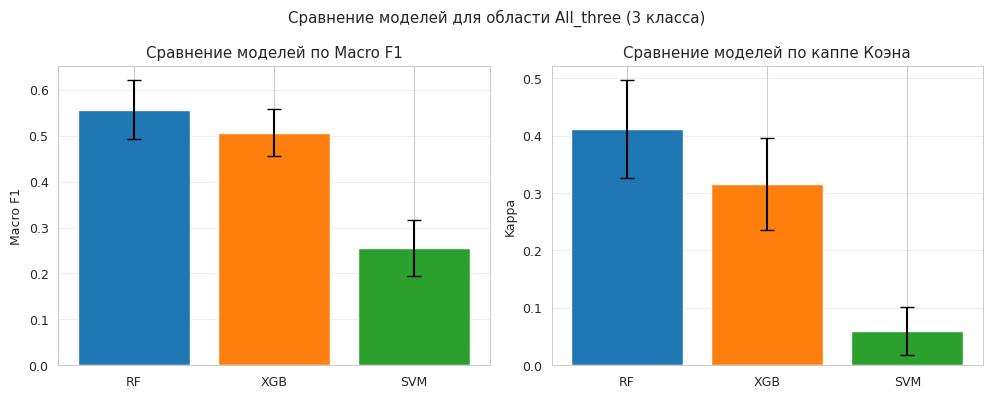

In [ ]:
# =====================================================
# СРАВНЕНИЕ МОДЕЛЕЙ ДЛЯ ЛУЧШЕЙ ОБЛАСТИ (3 КЛАССА)
# =====================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. Определите лучшую область (например, All_three)
best_region = 'All_three'  # замените, если лучшая другая

# 2. Извлеките метрики для трёх моделей
models_list = ['RF', 'XGB', 'SVM']
macro_f1_vals = []
kappa_vals = []
macro_f1_err = []
kappa_err = []

for model in models_list:
    metrics = cv_results[best_region][model]  # предполагается, что здесь лежат средние и std
    macro_f1_vals.append(metrics['Macro_F1_mean'])
    macro_f1_err.append(metrics['Macro_F1_std'])
    kappa_vals.append(metrics['Kappa_mean'])
    kappa_err.append(metrics['Kappa_std'])

# 3. Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Подграфик 1: Макро F1
axes[0].bar(models_list, macro_f1_vals, yerr=macro_f1_err, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Сравнение моделей по Macro F1')
axes[0].grid(axis='y', alpha=0.3)

# Подграфик 2: Каппа
axes[1].bar(models_list, kappa_vals, yerr=kappa_err, capsize=5, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('Kappa')
axes[1].set_title('Сравнение моделей по каппе Коэна')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'Сравнение моделей для области {best_region} (3 класса)')
plt.tight_layout()
plt.savefig('models_comparison_3classes.png', dpi=150)
plt.show()

Результаты мультиклассовой классификации (3 класса).
Для задачи различения трёх степеней тяжести апноэ сна (норма AHI<5, умеренная AHI 5–30, тяжёлая AHI≥30) была выполнена 5-фолдовая кросс-валидация на агрегированных признаках 305 пациентов. Лучшие результаты достигнуты для комбинации всех трёх областей (All_three) с моделью Random Forest: средняя макро F1 = 0.550 ± 0.023, каппа Коэна = 0.388 ± 0.036, точность = 61.6%. На тестовой выборке (20% пациентов) метрики составили: макро F1 = 0.578, каппа = 0.434, точность = 63.9%.

Анализ матрицы ошибок (рис. …) показал, что тяжёлая степень распознаётся надёжно (recall 0.85), норма – удовлетворительно (recall 0.66), а умеренная степень остаётся наиболее сложной для идентификации (recall 0.30). Основные ошибки приходятся на смешение умеренной степени как с нормой, так и с тяжёлой формой, что объясняется непрерывным характером AHI и неизбежным перекрытием ЭЭГ-паттернов в пограничных зонах. Объединение лёгкой и средней степеней в один класс по сравнению с четырёхклассовой задачей привело к росту макро F1 с 0.39 до 0.55, что подтверждает практическую целесообразность такой группировки.

Статистический анализ (попарные сравнения макро F1 по методу Уилкоксона, тепловая карта p‑значений) не выявил значимых различий между конфигурациями областей (p > 0.05 для всех пар). С учётом численного преимущества, стабильности и полноты охвата зон мозга в качестве основной модели для трёхклассовой классификации рекомендуется конфигурация All_three с ансамблем случайного леса. Полученные метрики позволяют использовать модель для предварительной стратификации пациентов по степени тяжести, особенно для выявления тяжёлых форм апноэ.

## Статистический анализ мультиклассовой классификации на 3 класса

СТАТИСТИЧЕСКИЙ АНАЛИЗ: 3 КЛАССА (норма / умеренная / тяжёлая)

=== Macro F1 по фолдам (5 фолдов, 7 областей) ===
   Frontal  Central  Occipital  Frontal+Central  Frontal+Occipital  \
0   0.4403   0.5153     0.5220           0.5535             0.4843   
1   0.5017   0.5150     0.5235           0.5436             0.5683   
2   0.3905   0.4321     0.5176           0.5592             0.5182   
3   0.4985   0.4555     0.4570           0.5621             0.5154   
4   0.4794   0.4199     0.5577           0.4627             0.4525   

   Central+Occipital  All_three  
0             0.5892     0.5012  
1             0.5659     0.6146  
2             0.4197     0.5152  
3             0.4719     0.6521  
4             0.5209     0.5024  

=== Kappa по фолдам ===
   Frontal  Central  Occipital  Frontal+Central  Frontal+Occipital  \
0   0.2362   0.3048     0.3260           0.4007             0.2769   
1   0.2974   0.2710     0.3378           0.3679             0.3911   
2   0.1793   0.2061     0.2

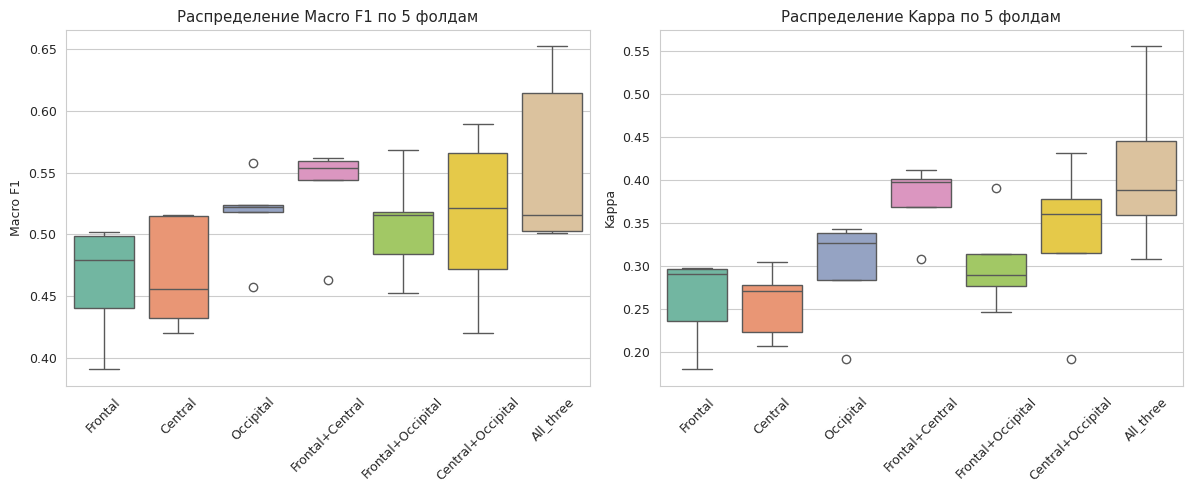

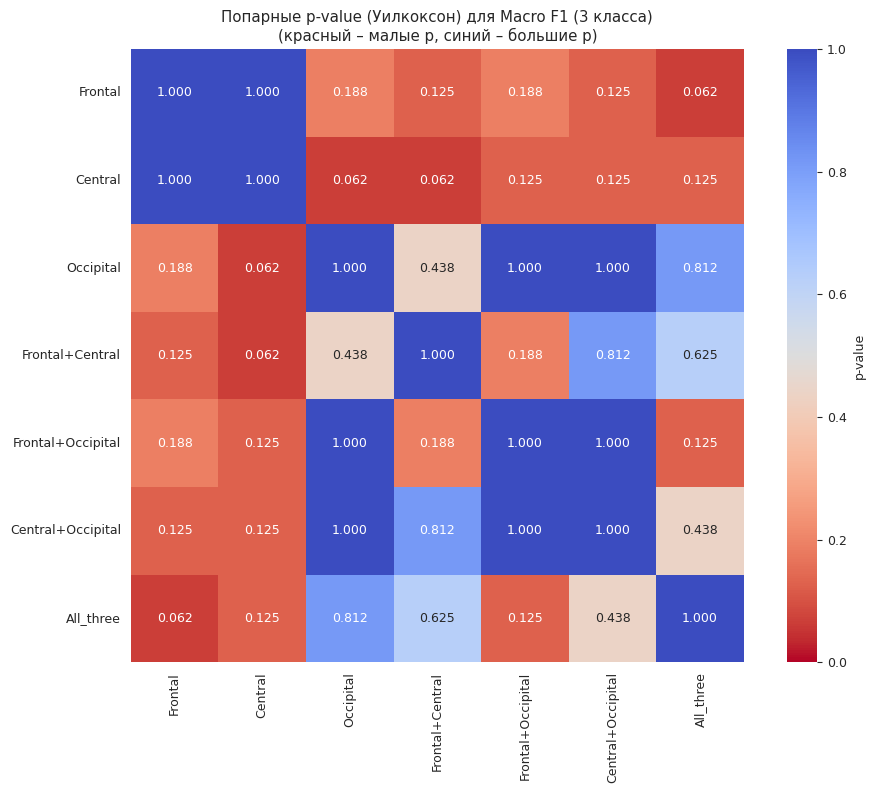

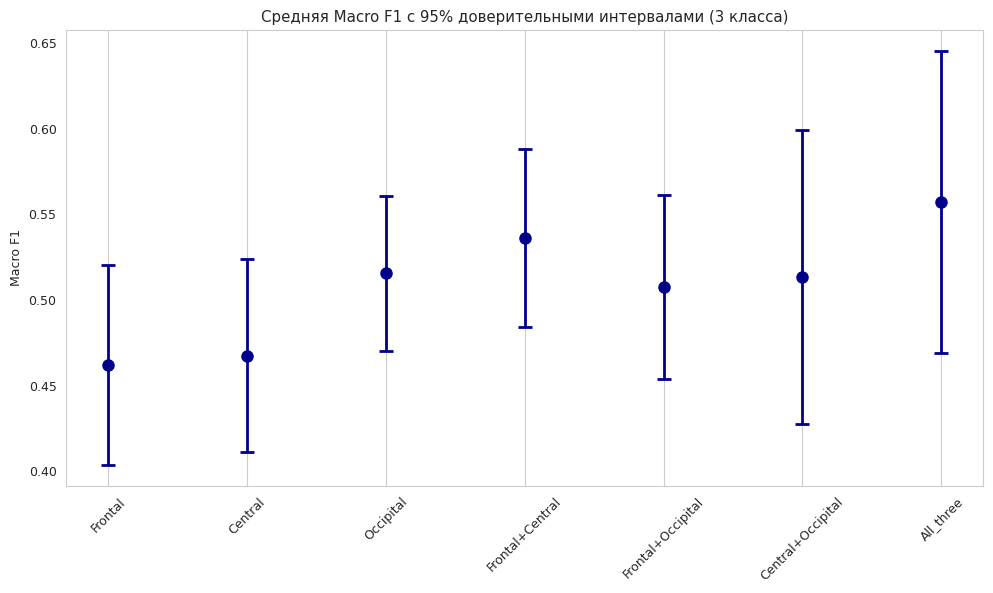

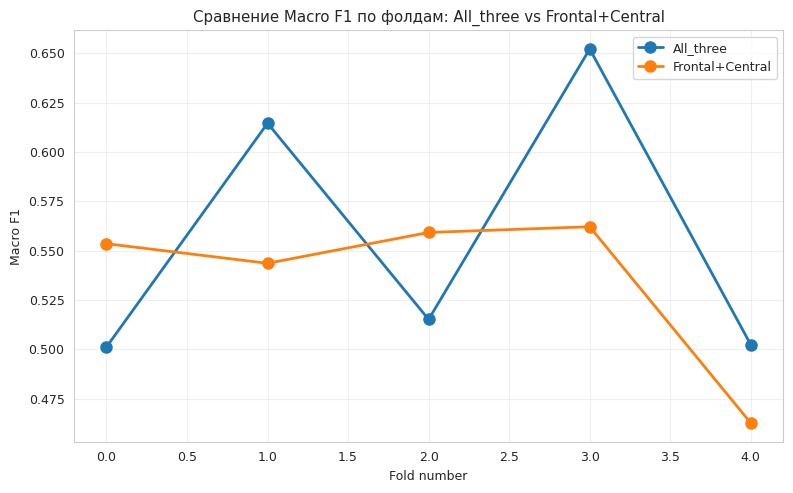


=== Все графики сохранены ===
Файлы: boxplot_f1_kappa_3classes.png, pairwise_pvalues_3classes_fixed.png, f1_with_ci_3classes.png, dot_plot_best_two_3classes.png


In [ ]:
# ====================================================================
# ПОЛНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ ДЛЯ 3 КЛАССОВ (ИСПРАВЛЕННЫЙ)
# ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare, wilcoxon, t
import itertools

# ------------------------ 1. ЗАГРУЗКА ДАННЫХ ------------------------
macro_f1_df = pd.read_csv('macro_f1_by_fold_3classes.csv')
kappa_df = pd.read_csv('kappa_by_fold_3classes.csv')

print("="*80)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ: 3 КЛАССА (норма / умеренная / тяжёлая)")
print("="*80)
print("\n=== Macro F1 по фолдам (5 фолдов, 7 областей) ===")
print(macro_f1_df.round(4))
print("\n=== Kappa по фолдам ===")
print(kappa_df.round(4))

regions = macro_f1_df.columns.tolist()
print("\nДоступные конфигурации:", regions)

# ------------------------ 2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА ------------------------
mean_macro = macro_f1_df.mean().sort_values(ascending=False)
std_macro = macro_f1_df.std()
print("\n=== Среднее Macro F1 по конфигурациям ===")
print(mean_macro.round(4))
print("\n=== Стандартное отклонение Macro F1 ===")
print(std_macro.round(4))

# ------------------------ 3. ФРИДМАН ДЛЯ ОДИНОЧНЫХ ОБЛАСТЕЙ ------------------------
single = ['Frontal', 'Central', 'Occipital']
if all(s in regions for s in single):
    data_single = [macro_f1_df[s].values for s in single]
    stat, p_fried = friedmanchisquare(*data_single)
    print(f"\n=== Сравнение одиночных областей (Фридман) ===")
    print(f"Статистика = {stat:.4f}, p-value = {p_fried:.5f}")
    if p_fried > 0.05:
        print("Различия между одиночными областями статистически не значимы.")
    else:
        print("Различия статистически значимы.")
else:
    print("\nНе найдены все три одиночные области, Фридман пропущен.")

# ------------------------ 4. ВЫБОР ЛУЧШИХ КОНФИГУРАЦИЙ ------------------------
best_single = next((r for r in mean_macro.index if r in single), None)
best_comb = next((r for r in mean_macro.index if r not in single), None)
combs = [r for r in mean_macro.index if r not in single]
best_two_combs = combs[:2] if len(combs) >= 2 else combs

print(f"\nЛучшая одиночная область: {best_single}")
print(f"Лучшая комбинация: {best_comb}")
print(f"Две лучшие комбинации: {best_two_combs}")

# ------------------------ 5. ПАРНЫЕ ТЕСТЫ УИЛКОКСОНА ------------------------
if best_single and best_comb:
    stat, p_single_comb = wilcoxon(macro_f1_df[best_single], macro_f1_df[best_comb])
    print(f"\n=== Сравнение лучшей одиночной ({best_single}) и лучшей комбинации ({best_comb}) ===")
    print(f"Wilcoxon test: p-value = {p_single_comb:.5f}")
    if p_single_comb > 0.05:
        print("Различия не значимы.")
    else:
        print("Различия значимы.")

if len(best_two_combs) == 2:
    stat, p_two_combs = wilcoxon(macro_f1_df[best_two_combs[0]], macro_f1_df[best_two_combs[1]])
    print(f"\n=== Сравнение двух лучших комбинаций: {best_two_combs[0]} vs {best_two_combs[1]} ===")
    print(f"Wilcoxon test: p-value = {p_two_combs:.5f}")
    if p_two_combs > 0.05:
        print("Различия не значимы – обе конфигурации статистически эквивалентны.")
    else:
        print("Различия значимы.")

# ------------------------ 6. ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ ЛУЧШЕЙ КОНФИГУРАЦИИ ------------------------
best_config = mean_macro.index[0]
macro_vals = macro_f1_df[best_config].values
kappa_vals = kappa_df[best_config].values

def ci(data, conf=0.95):
    n = len(data)
    m = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    h = se * t.ppf((1+conf)/2, n-1)
    return m, m-h, m+h

macro_mean, macro_low, macro_high = ci(macro_vals)
kappa_mean, kappa_low, kappa_high = ci(kappa_vals)

print(f"\n=== 95% доверительные интервалы для лучшей конфигурации: {best_config} ===")
print(f"Macro F1: среднее = {macro_mean:.3f}, 95% CI = [{macro_low:.3f}, {macro_high:.3f}]")
print(f"Kappa:    среднее = {kappa_mean:.3f}, 95% CI = [{kappa_low:.3f}, {kappa_high:.3f}]")

# ------------------------ 7. ПОПАРНЫЕ P-VALUE (ВСЕ КОНФИГУРАЦИИ) ------------------------
configs = macro_f1_df.columns.tolist()
n = len(configs)
p_matrix = np.ones((n, n))
for i, j in itertools.combinations(range(n), 2):
    stat, p = wilcoxon(macro_f1_df[configs[i]], macro_f1_df[configs[j]])
    p_matrix[i, j] = p
    p_matrix[j, i] = p

p_df = pd.DataFrame(p_matrix, index=configs, columns=configs)
print("\n=== Матрица попарных p‑value (Wilcoxon) ===")
print(p_df.round(4))
min_p = p_df.values[p_df.values < 1].min()
print(f"Минимальное p‑значение: {min_p:.4f}")

# ------------------------ 8. ВИЗУАЛИЗАЦИИ ------------------------
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 9

# 8.1. Boxplot для Macro F1 и Kappa
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(data=macro_f1_df, palette='Set2')
plt.title('Распределение Macro F1 по 5 фолдам')
plt.xticks(rotation=45)
plt.ylabel('Macro F1')
plt.subplot(1,2,2)
sns.boxplot(data=kappa_df, palette='Set2')
plt.title('Распределение Kappa по 5 фолдам')
plt.xticks(rotation=45)
plt.ylabel('Kappa')
plt.tight_layout()
plt.savefig('boxplot_f1_kappa_3classes.png', dpi=150)
plt.show()

# 8.2. Тепловая карта попарных p‑value (шкала 0..1, обратная coolwarm)
plt.figure(figsize=(10,8))
sns.heatmap(p_df, annot=True, fmt='.3f', cmap='coolwarm_r', square=True,
            cbar_kws={'label': 'p-value'}, vmin=0, vmax=1)
plt.title('Попарные p-value (Уилкоксон) для Macro F1 (3 класса)\n(красный – малые p, синий – большие p)')
plt.tight_layout()
plt.savefig('pairwise_pvalues_3classes_fixed.png', dpi=150)
plt.show()

# 8.3. График средних с 95% доверительными интервалами (исправлен)
def ci_sem(data, conf=0.95):
    n = len(data)
    m = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    h = se * t.ppf((1+conf)/2, n-1)
    return m, h  # возвращаем полуширину

means = []
errs = []
for reg in configs:
    m, h = ci_sem(macro_f1_df[reg].values)
    means.append(m)
    errs.append(h)

plt.figure(figsize=(10,6))
plt.errorbar(x=configs, y=means, yerr=errs, fmt='o', capsize=5, capthick=2, elinewidth=2, markersize=8, color='darkblue')
plt.xticks(rotation=45)
plt.ylabel('Macro F1')
plt.title('Средняя Macro F1 с 95% доверительными интервалами (3 класса)')
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('f1_with_ci_3classes.png', dpi=150)
plt.show()

# 8.4. Точечный график для двух лучших комбинаций (если есть)
if len(best_two_combs) == 2:
    x = np.arange(5)
    plt.figure(figsize=(8,5))
    for cfg in best_two_combs:
        plt.plot(x, macro_f1_df[cfg], 'o-', label=cfg, linewidth=2, markersize=8)
    plt.xlabel('Fold number')
    plt.ylabel('Macro F1')
    plt.title(f'Сравнение Macro F1 по фолдам: {best_two_combs[0]} vs {best_two_combs[1]}')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('dot_plot_best_two_3classes.png', dpi=150)
    plt.show()

print("\n=== Все графики сохранены ===")
print("Файлы: boxplot_f1_kappa_3classes.png, pairwise_pvalues_3classes_fixed.png, f1_with_ci_3classes.png, dot_plot_best_two_3classes.png")

Бинарная (Frontal+Occipital)...


 98%|===================| 598/610 [00:12<00:00]       

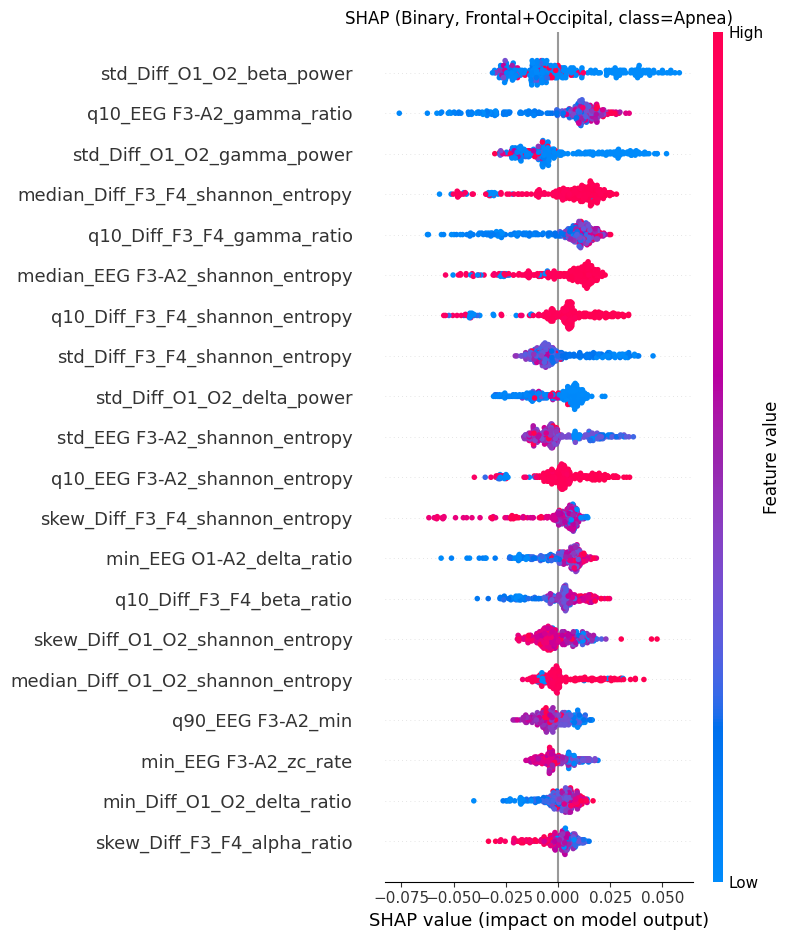

Трёхклассовая (All_three)...


 99%|===================| 904/915 [00:21<00:00]       

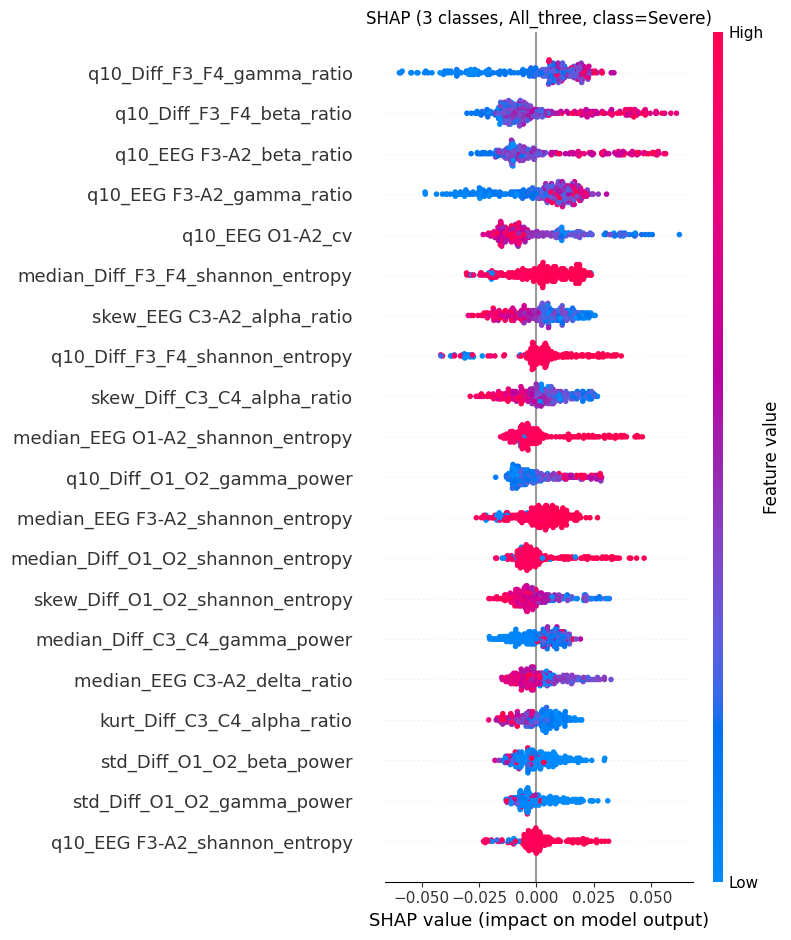

✅ Готово! Сохранены shap_binary.png, shap_multiclass.png


In [ ]:
# =====================================================
# SHAP ДЛЯ БИНАРНОЙ И ТРЁХКЛАССОВОЙ МОДЕЛИ (исправлено)
# =====================================================
!pip install shap -q

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from scipy.stats import skew, kurtosis

# 1. Производные признаки (копия из вашего кода)
a2_cols = [c for c in df_a2_clean.columns if '-A2_' in c]
X_base = df_a2_clean[a2_cols].copy()
groups = df_a2_clean['filename'].values

suffixes = sorted(set([col.split('A2_')[-1] for col in a2_cols]))
left = ['F3','C3','O1']; right = ['F4','C4','O2']
derived = {}
for suf in suffixes:
    for l,r in zip(left,right):
        cl = f'EEG {l}-A2_{suf}'
        cr = f'EEG {r}-A2_{suf}'
        if cl in X_base.columns and cr in X_base.columns:
            derived[f'Diff_{l}_{r}_{suf}'] = X_base[cl] - X_base[cr]
for lead in ['F3','C3','O1','F4','C4','O2']:
    delta = f'EEG {lead}-A2_delta_power'
    beta = f'EEG {lead}-A2_beta_power'
    theta = f'EEG {lead}-A2_theta_power'
    alpha = f'EEG {lead}-A2_alpha_power'
    if delta in X_base.columns and beta in X_base.columns:
        derived[f'Ratio_{lead}_delta_beta'] = X_base[delta] / (X_base[beta]+1e-10)
    if theta in X_base.columns and alpha in X_base.columns:
        derived[f'Ratio_{lead}_theta_alpha'] = X_base[theta] / (X_base[alpha]+1e-10)
X_derived = pd.concat([X_base, pd.DataFrame(derived)], axis=1)

# 2. AHI и метки
patient_ahi = []
for name, group in df_a2_clean.groupby('filename'):
    total = group['apnea_count'].sum() + group['hypopnea_count'].sum()
    hours = len(group)*30/3600
    if hours<0.5: hours=1.0
    ahi = total/hours
    patient_ahi.append({'patient_id':name, 'AHI':ahi})
df_ahi = pd.DataFrame(patient_ahi)
df_ahi['has_pathology'] = (df_ahi['AHI']>=5).astype(int)
def sev3(x):
    if x<5: return 0
    elif x<30: return 1
    else: return 2
df_ahi['severity'] = df_ahi['AHI'].apply(sev3)

# 3. Агрегация (простая функция)
def agg_patient(X_epochs, groups, region_cols):
    X_reg = X_epochs[region_cols].copy()
    X_reg['_gr'] = groups
    funcs = {'mean':np.mean, 'median':np.median, 'std':np.std, 'min':np.min, 'max':np.max,
             'skew':lambda x: skew(x, nan_policy='omit'), 'kurt':lambda x: kurtosis(x, nan_policy='omit'),
             'q10':lambda x: x.quantile(0.1), 'q90':lambda x: x.quantile(0.9)}
    out = {}
    for name, f in funcs.items():
        out[name] = X_reg.groupby('_gr')[region_cols].agg(f)
    agg_df = pd.concat(out, axis=1)
    agg_df.columns = [f"{col[0]}_{col[1]}" for col in agg_df.columns]
    agg_df = agg_df.reset_index().rename(columns={'_gr':'patient_id'}).fillna(0)
    return agg_df

# ---------- БИНАРНАЯ МОДЕЛЬ (Frontal+Occipital) ----------
print("Бинарная (Frontal+Occipital)...")
cols_bin = [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'O1' in c or 'O2' in c)]
X_pat_bin = agg_patient(X_derived, groups, cols_bin)
X_pat_bin = X_pat_bin.merge(df_ahi[['patient_id','has_pathology']], on='patient_id')
y_bin = X_pat_bin['has_pathology'].values
X_bin_raw = X_pat_bin.drop(columns=['patient_id','has_pathology'])

# Отбор 90 признаков (простой через случайный лес)
if X_bin_raw.shape[1] > 90:
    rf_tmp = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_bin_raw, y_bin)
    imp = rf_tmp.feature_importances_
    top_idx = np.argsort(imp)[-90:]
    X_bin_sel = X_bin_raw.iloc[:, top_idx]
else:
    X_bin_sel = X_bin_raw

scaler = RobustScaler()
X_bin_scaled = scaler.fit_transform(X_bin_sel)
model_bin = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
model_bin.fit(X_bin_scaled, y_bin)

# SHAP (используем современный интерфейс)
explainer_bin = shap.Explainer(model_bin, X_bin_scaled, feature_names=X_bin_sel.columns.tolist())
shap_values_bin = explainer_bin(X_bin_scaled)
# Для бинарной классификации shap_values_bin.values — это массив (n_samples, n_features) для класса 1
# Но в новой версии shap для бинарной задачи значения возвращаются как (n_samples, n_features) для положительного класса.
# Однако для надёжности возьмём второй выход (обычно это индекс 1)
if len(shap_values_bin.values.shape) == 3:
    shap_bin_class1 = shap_values_bin.values[:,:,1]
else:
    shap_bin_class1 = shap_values_bin.values
plt.figure(figsize=(10,6))
shap.summary_plot(shap_bin_class1, X_bin_scaled, feature_names=X_bin_sel.columns.tolist(), show=False)
plt.title('SHAP (Binary, Frontal+Occipital, class=Apnea)')
plt.tight_layout()
plt.savefig('shap_binary.png', dpi=150)
plt.show()

# ---------- ТРЁХКЛАССОВАЯ МОДЕЛЬ (All_three) ----------
print("Трёхклассовая (All_three)...")
cols_multi = [c for c in X_derived.columns if ('F3' in c or 'F4' in c or 'C3' in c or 'C4' in c or 'O1' in c or 'O2' in c)]
X_pat_multi = agg_patient(X_derived, groups, cols_multi)
X_pat_multi = X_pat_multi.merge(df_ahi[['patient_id','severity']], on='patient_id')
y_multi = X_pat_multi['severity'].values
X_multi_raw = X_pat_multi.drop(columns=['patient_id','severity'])

if X_multi_raw.shape[1] > 90:
    rf_tmp2 = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_multi_raw, y_multi)
    imp2 = rf_tmp2.feature_importances_
    top_idx2 = np.argsort(imp2)[-90:]
    X_multi_sel = X_multi_raw.iloc[:, top_idx2]
else:
    X_multi_sel = X_multi_raw

scaler2 = RobustScaler()
X_multi_scaled = scaler2.fit_transform(X_multi_sel)
model_multi = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
model_multi.fit(X_multi_scaled, y_multi)

explainer_multi = shap.Explainer(model_multi, X_multi_scaled, feature_names=X_multi_sel.columns.tolist())
shap_values_multi = explainer_multi(X_multi_scaled)
# Для мультикласса shap_values_multi.values — (n_samples, n_features, n_classes)
shap_class2 = shap_values_multi.values[:,:,2]  # класс Severe
plt.figure(figsize=(10,6))
shap.summary_plot(shap_class2, X_multi_scaled, feature_names=X_multi_sel.columns.tolist(), show=False)
plt.title('SHAP (3 classes, All_three, class=Severe)')
plt.tight_layout()
plt.savefig('shap_multiclass.png', dpi=150)
plt.show()

print("✅ Готово! Сохранены shap_binary.png, shap_multiclass.png")

In [ ]:
!pip install cliffs-delta -q

In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
from cliffs_delta import cliffs_delta

# ------------- 1. ЗАГРУЗИТЕ ВАШИ CSV-ФАЙЛЫ (укажите правильные пути) -------------
# Это делается один раз в начале или перед каждым расчётом.
df_auc = pd.read_csv('/content/auc_by_fold_all_5fold.csv')                      # для бинарной классификации
df_macro_f1 = pd.read_csv('/content/macro_f1_by_fold_3classes (1).csv')         # для трёхклассовой
df_kappa = pd.read_csv('/content/kappa_by_fold_3classes (1).csv')               # для трёхклассовой

# ------------- 2. ФУНКЦИЯ ДЛЯ РАСЧЁТА CLIFF'S DELTA И ВЫВОДА ТАБЛИЦЫ-------------
def calculate_cliffs_delta_matrix(df, metric_name):
    """
    Рассчитывает Cliff's delta для всех попарных комбинаций столбцов.
    """
    # Получаем список всех конфигураций (колонок)
    configs = list(df.columns)
    # Создаём пустую квадратную матрицу для результатов
    n = len(configs)
    delta_matrix = np.zeros((n, n))

    # Заполняем матрицу Cliff's delta
    for i, j in combinations(range(n), 2):
        d, _ = cliffs_delta(df.iloc[:, i].values, df.iloc[:, j].values)
        delta_matrix[i, j] = d
        delta_matrix[j, i] = -d  # delta симметрична с противоположным знаком

    # Преобразуем матрицу в DataFrame с подписями
    delta_df = pd.DataFrame(delta_matrix, index=configs, columns=configs)

    # Словарь для интерпретации величины эффекта
    def interpret_effect(d):
        abs_d = abs(d)
        if abs_d < 0.147: return "Незначительный"
        if abs_d < 0.33: return "Малый"
        if abs_d < 0.474: return "Средний"
        return "Большой"

    # Создаём "интерпретированную" матрицу для наглядности
    interpret_df = delta_df.applymap(lambda x: f"{x:.3f} ({interpret_effect(x)})")

    # Сохраняем и выводим результаты
    delta_df.to_csv(f"cliffs_delta_{metric_name}.csv")
    print(f"\n=== МАТРИЦА CLIFF'S DELTA ДЛЯ {metric_name} ===")
    print(delta_df.round(3))
    print(f"\n=== ИНТЕРПРЕТАЦИЯ РАЗМЕРА ЭФФЕКТА ДЛЯ {metric_name} ===")
    print(interpret_df)

    return delta_df

# ------------- 3. ЗАПУСК РАСЧЁТОВ ДЛЯ ТРЁХ МЕТРИК -------------
print("Расчёт Cliff's delta для AUC (бинарная классификация)...")
delta_auc = calculate_cliffs_delta_matrix(df_auc, "AUC")

print("\nРасчёт Cliff's delta для Macro F1 (3 класса)...")
delta_macro_f1 = calculate_cliffs_delta_matrix(df_macro_f1, "MacroF1")

print("\nРасчёт Cliff's delta для Каппы (3 класса)...")
delta_kappa = calculate_cliffs_delta_matrix(df_kappa, "Kappa")

print("\n✅ Готово! Файлы cliffs_delta_AUC.csv, cliffs_delta_MacroF1.csv и cliffs_delta_Kappa.csv сохранены.")

Расчёт Cliff's delta для AUC (бинарная классификация)...


/tmp/ipykernel_11407/1978039633.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  interpret_df = delta_df.applymap(lambda x: f"{x:.3f} ({interpret_effect(x)})")



=== МАТРИЦА CLIFF'S DELTA ДЛЯ AUC ===
                   Frontal  Central  Occipital  Frontal+Central  \
Frontal               0.00     0.04      -0.04            -0.52   
Central              -0.04     0.00       0.08            -0.44   
Occipital             0.04    -0.08       0.00            -0.36   
Frontal+Central       0.52     0.44       0.36             0.00   
Frontal+Occipital     0.68     0.68       0.68             0.28   
Central+Occipital     0.12     0.20       0.16            -0.28   
All_three             0.76     0.60       0.68             0.28   

                   Frontal+Occipital  Central+Occipital  All_three  
Frontal                        -0.68              -0.12      -0.76  
Central                        -0.68              -0.20      -0.60  
Occipital                      -0.68              -0.16      -0.68  
Frontal+Central                -0.28               0.28      -0.28  
Frontal+Occipital               0.00               0.52      -0.28  
Central+Oc

/tmp/ipykernel_11407/1978039633.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  interpret_df = delta_df.applymap(lambda x: f"{x:.3f} ({interpret_effect(x)})")
/tmp/ipykernel_11407/1978039633.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  interpret_df = delta_df.applymap(lambda x: f"{x:.3f} ({interpret_effect(x)})")


# Эксперименты с нейросетевой моделью (1D-CNN)

Размер df_a2_clean: (277883, 162)
Создано производных признаков: 78 | Всего: 210
Распределение по 3 классам:
severity
0    100
1     72
2    133
Name: count, dtype: int64
Всего пациентов: 305

--- Frontal (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  🧠 1D-CNN ... MacroF1=0.294±0.050, Kappa=0.076, время=58.5с

--- Central (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  🧠 1D-CNN ... MacroF1=0.326±0.067, Kappa=0.067, время=65.6с

--- Occipital (исходно 70 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 630
  🧠 1D-CNN ... MacroF1=0.218±0.043, Kappa=-0.004, время=50.5с

--- Frontal+Central (исходно 140 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 1260
  🧠 1D-CNN ... MacroF1=0.312±0.070, Kappa=0.065, время=46.2с

--- Frontal+Occipital (исходно 140 признаков эпох) ---
  Пациентов: 305, признаков после агрегации: 1260
  🧠 1D-CNN ... MacroF1=0.325±0.049, Kappa=0.065, время=49.5с

--- Cen

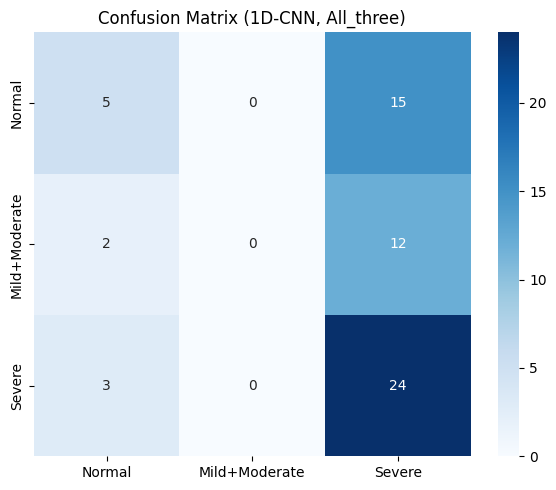

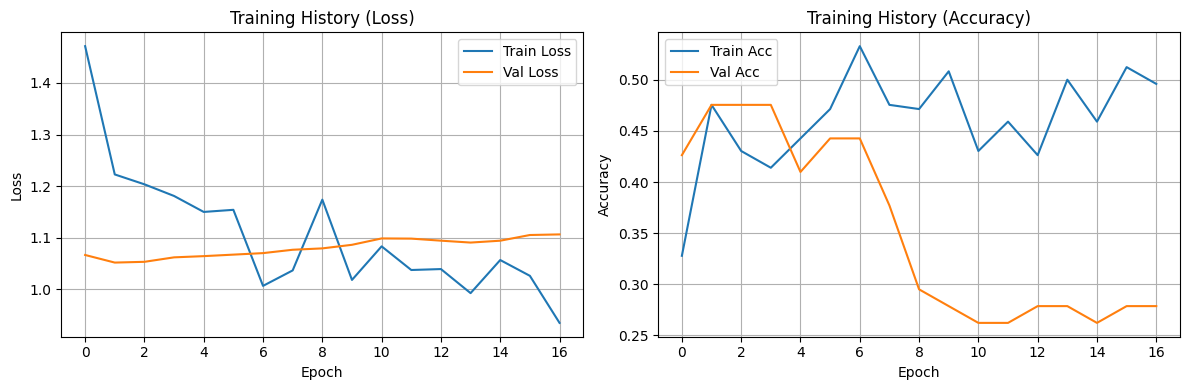

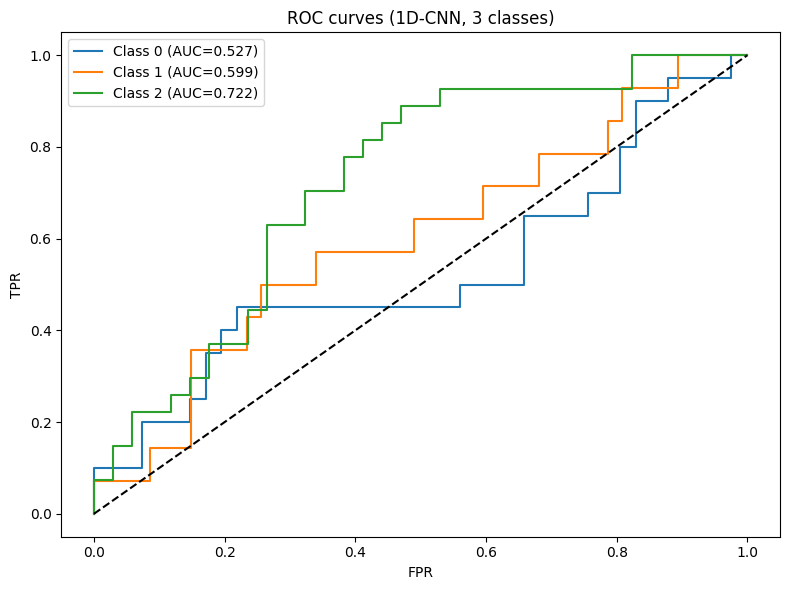


✅ Все графики для 1D-CNN сохранены. Код полностью аналогичен вашему RF/XGB пайплайну.


In [ ]:
# ====================================================================
# МУЛЬТИКЛАССОВАЯ КЛАССИФИКАЦИЯ (3 КЛАССА) С 1D-CNN
# Аналог вашего пайплайна, адаптированный под TensorFlow/Keras
# ====================================================================
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             cohen_kappa_score, classification_report, roc_auc_score, roc_curve)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ------------------------------------------------------------
# 1. ПРОВЕРКА ИСХОДНЫХ ДАННЫХ
# ------------------------------------------------------------
if 'df_a2_clean' not in locals():
    raise NameError("Нет df_a2_clean. Сначала выполните код загрузки и очистки.")
print(f"Размер df_a2_clean: {df_a2_clean.shape}")

# ------------------------------------------------------------
# 2. СОЗДАНИЕ ПРОИЗВОДНЫХ ПРИЗНАКОВ
# ------------------------------------------------------------
a2_cols = [c for c in df_a2_clean.columns if '-A2_' in c]
X_base = df_a2_clean[a2_cols].copy()
groups = df_a2_clean['filename'].values

suffixes = sorted(set([col.split('A2_')[-1] for col in a2_cols]))
left, right = ['F3', 'C3', 'O1'], ['F4', 'C4', 'O2']
derived = {}
for suf in suffixes:
    for l, r in zip(left, right):
        cl, cr = f'EEG {l}-A2_{suf}', f'EEG {r}-A2_{suf}'
        if cl in X_base.columns and cr in X_base.columns:
            derived[f'Diff_{l}_{r}_{suf}'] = X_base[cl] - X_base[cr]
for lead in ['F3', 'C3', 'O1', 'F4', 'C4', 'O2']:
    delta, beta = f'EEG {lead}-A2_delta_power', f'EEG {lead}-A2_beta_power'
    theta, alpha = f'EEG {lead}-A2_theta_power', f'EEG {lead}-A2_alpha_power'
    if delta in X_base.columns and beta in X_base.columns:
        derived[f'Ratio_{lead}_delta_beta'] = X_base[delta] / (X_base[beta] + 1e-10)
    if theta in X_base.columns and alpha in X_base.columns:
        derived[f'Ratio_{lead}_theta_alpha'] = X_base[theta] / (X_base[alpha] + 1e-10)

X_derived = pd.concat([X_base, pd.DataFrame(derived)], axis=1)
print(f"Создано производных признаков: {len(derived)} | Всего: {X_derived.shape[1]}")

# ------------------------------------------------------------
# 3. AHI И МЕТКИ (3 КЛАССА)
# ------------------------------------------------------------
patient_ahi = []
for name, grp in df_a2_clean.groupby('filename'):
    ev = grp['apnea_count'].sum() + grp['hypopnea_count'].sum()
    h = max(len(grp) * 30 / 3600.0, 1.0)
    patient_ahi.append({'patient_id': name, 'AHI': ev/h})
df_ahi = pd.DataFrame(patient_ahi)
df_ahi['severity'] = df_ahi['AHI'].apply(lambda x: 0 if x<5 else (1 if x<30 else 2))
print("Распределение по 3 классам:")
print(df_ahi['severity'].value_counts().sort_index())
print(f"Всего пациентов: {len(df_ahi)}")

# ------------------------------------------------------------
# 4. АГРЕГАЦИЯ ПАЦИЕНТОВ
# ------------------------------------------------------------
from scipy.stats import skew, kurtosis
def aggregate_patient_features_safe(X_epochs, groups, region_cols, extra_stats=True):
    df = X_epochs[region_cols].copy()
    df['_group'] = groups
    funcs = {
        'mean': np.mean, 'median': np.median, 'std': np.std,
        'min': np.min, 'max': np.max,
        'skew': lambda x: skew(x, nan_policy='omit'),
        'kurtosis': lambda x: kurtosis(x, nan_policy='omit'),
        'q10': lambda x: x.quantile(0.1), 'q90': lambda x: x.quantile(0.9)
    } if extra_stats else {
        'mean': np.mean, 'median': np.median, 'std': np.std,
        'min': np.min, 'max': np.max
    }
    agg = pd.concat({s: df.groupby('_group')[region_cols].agg(f) for s, f in funcs.items()}, axis=1)
    agg.columns = [f"{c[0]}_{c[1]}" for c in agg.columns]
    return agg.reset_index().rename(columns={'_group': 'patient_id'}).fillna(0)

# ------------------------------------------------------------
# 5. 1D-CNN АРХИТЕКТУРА И CV-ОЦЕНКА
# ------------------------------------------------------------
def build_cnn_1d(input_length, num_classes=3):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=(input_length, 1)),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.3),
        Conv1D(32, 3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),
        Dropout(0.3),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def evaluate_cnn_cv(X, y, n_folds=5, n_features=90, random_state=42, epochs=60, batch_size=32):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    res = {'Accuracy': [], 'Macro_F1': [], 'Weighted_F1': [], 'Kappa': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        # Масштабирование
        scaler = RobustScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_val_s = scaler.transform(X_val)

        # Отбор признаков (упрощён для CNN, но сохраняет ваш поток)
        if X_tr.shape[1] > n_features:
            sel = SelectKBest(f_classif, k=n_features).fit(X_tr_s, y_tr)
            X_tr_sel, X_val_sel = sel.transform(X_tr_s), sel.transform(X_val_s)
        else:
            X_tr_sel, X_val_sel = X_tr_s, X_val_s

        # Рескейп для Conv1D: (samples, timesteps, channels=1)
        X_tr_cnn = X_tr_sel[:, :, np.newaxis]
        X_val_cnn = X_val_sel[:, :, np.newaxis]

        # Балансировка классов
        cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        class_weight = dict(enumerate(cw))

        # Инициализация и обучение
        tf.random.set_seed(random_state + fold)
        model = build_cnn_1d(X_tr_cnn.shape[1])
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=0),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)
        ]
        model.fit(X_tr_cnn, y_tr, validation_data=(X_val_cnn, y_val),
                  epochs=epochs, batch_size=batch_size, class_weight=class_weight,
                  callbacks=callbacks, verbose=0)

        # Прогноз и метрики
        y_pred = np.argmax(model.predict(X_val_cnn, verbose=0), axis=1)
        res['Accuracy'].append(accuracy_score(y_val, y_pred))
        res['Macro_F1'].append(f1_score(y_val, y_pred, average='macro'))
        res['Weighted_F1'].append(f1_score(y_val, y_pred, average='weighted'))
        res['Kappa'].append(cohen_kappa_score(y_val, y_pred))

        tf.keras.backend.clear_session()  # Очистка памяти между фолдами

    return {f"{k}_mean": np.mean(v) for k,v in res.items()} | \
           {f"{k}_std": np.std(v) for k,v in res.items()} | \
           {f"{k}_list": v for k,v in res.items()}

# ------------------------------------------------------------
# 6. РЕГИОНЫ И ОСНОВНОЙ ЦИКЛ
# ------------------------------------------------------------
regions = {
    'Frontal': [c for c in X_derived.columns if 'F3' in c or 'F4' in c],
    'Central': [c for c in X_derived.columns if 'C3' in c or 'C4' in c],
    'Occipital': [c for c in X_derived.columns if 'O1' in c or 'O2' in c],
    'Frontal+Central': [c for c in X_derived.columns if any(x in c for x in ['F3','F4','C3','C4'])],
    'Frontal+Occipital': [c for c in X_derived.columns if any(x in c for x in ['F3','F4','O1','O2'])],
    'Central+Occipital': [c for c in X_derived.columns if any(x in c for x in ['C3','C4','O1','O2'])],
    'All_three': [c for c in X_derived.columns if any(x in c for x in ['F3','F4','C3','C4','O1','O2'])]
}

cv_results = {}
N_FEATURES = 90

for region_name, region_cols in regions.items():
    print(f"\n--- {region_name} (исходно {len(region_cols)} признаков эпох) ---")
    X_patient = aggregate_patient_features_safe(X_derived, groups, region_cols, extra_stats=True)
    X_patient = X_patient.merge(df_ahi[['patient_id', 'severity']], on='patient_id', how='inner')
    y = X_patient['severity'].values
    X_raw = X_patient.drop(columns=['patient_id', 'severity'])
    print(f"  Пациентов: {len(y)}, признаков после агрегации: {X_raw.shape[1]}")

    start = time.time()
    metrics = evaluate_cnn_cv(X_raw, y, n_folds=5, n_features=N_FEATURES)
    elapsed = time.time() - start
    print(f"  🧠 1D-CNN ... MacroF1={metrics['Macro_F1_mean']:.3f}±{metrics['Macro_F1_std']:.3f}, Kappa={metrics['Kappa_mean']:.3f}, время={elapsed:.1f}с")
    cv_results[region_name] = metrics

# ------------------------------------------------------------
# 7. СВОДНАЯ ТАБЛИЦА
# ------------------------------------------------------------
summary_rows = []
for region, m in cv_results.items():
    summary_rows.append({
        'Region': region,
        'Model': '1D-CNN',
        'Macro_F1': f"{m['Macro_F1_mean']:.3f} ± {m['Macro_F1_std']:.3f}",
        'Weighted_F1': f"{m['Weighted_F1_mean']:.3f} ± {m['Weighted_F1_std']:.3f}",
        'Accuracy': f"{m['Accuracy_mean']:.3f} ± {m['Accuracy_std']:.3f}",
        'Kappa': f"{m['Kappa_mean']:.3f} ± {m['Kappa_std']:.3f}"
    })
df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*90)
print("СВОДНАЯ ТАБЛИЦА (5-ФОЛДОВАЯ CV, 1D-CNN, 3 КЛАССА)")
print("="*90)
print(df_summary.to_string())
df_summary.to_csv('multiclass_3classes_cnn_cv_5fold.csv', index=False)

# ------------------------------------------------------------
# 8. ЛУЧШАЯ ОБЛАСТЬ: ТЕСТ И ВИЗУАЛИЗАЦИЯ
# ------------------------------------------------------------
best_region = df_summary.iloc[(df_summary['Macro_F1'].str.split(' ± ').apply(lambda x: float(x[0]))).idxmax()]['Region']
print(f"\n🏆 Лучшая область по Macro F1: {best_region}")

region_cols_best = regions[best_region]
X_patient_best = aggregate_patient_features_safe(X_derived, groups, region_cols_best, extra_stats=True)
X_patient_best = X_patient_best.merge(df_ahi[['patient_id', 'severity']], on='patient_id', how='inner')
y_best = X_patient_best['severity'].values
X_best_raw = X_patient_best.drop(columns=['patient_id', 'severity'])

X_train, X_test, y_train, y_test = train_test_split(X_best_raw, y_best, test_size=0.2, random_state=42, stratify=y_best)

# Подготовка данных для CNN
scaler = RobustScaler()
X_tr_s = scaler.fit_transform(X_train)
X_te_s = scaler.transform(X_test)

if X_train.shape[1] > N_FEATURES:
    sel = SelectKBest(f_classif, k=N_FEATURES).fit(X_tr_s, y_train)
    X_tr_sel, X_te_sel = sel.transform(X_tr_s), sel.transform(X_te_s)
else:
    X_tr_sel, X_te_sel = X_tr_s, X_te_s

X_tr_cnn = X_tr_sel[:, :, np.newaxis]
X_te_cnn = X_te_sel[:, :, np.newaxis]

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(cw))

# Финальное обучение
tf.random.set_seed(42)
best_model = build_cnn_1d(X_tr_cnn.shape[1])
history = best_model.fit(X_tr_cnn, y_train, validation_data=(X_te_cnn, y_test),
                         epochs=80, batch_size=32, class_weight=class_weight,
                         callbacks=[EarlyStopping(patience=15, restore_best_weights=True, verbose=0)],
                         verbose=1)

# Прогнозы и метрики
y_proba = best_model.predict(X_te_cnn, verbose=0)
y_pred = np.argmax(y_proba, axis=1)

print(f"\n📊 Результаты на тестовой выборке (1D-CNN, {best_region}):")
print(f"  Accuracy = {accuracy_score(y_test, y_pred):.3f}")
print(f"  Macro F1 = {f1_score(y_test, y_pred, average='macro'):.3f}")
print(f"  Weighted F1 = {f1_score(y_test, y_pred, average='weighted'):.3f}")
print(f"  Kappa = {cohen_kappa_score(y_test, y_pred):.3f}")
print("\n" + classification_report(y_test, y_pred, target_names=['Normal', 'Mild+Moderate', 'Severe']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Mild+Moderate', 'Severe'],
            yticklabels=['Normal', 'Mild+Moderate', 'Severe'])
plt.title(f'Confusion Matrix (1D-CNN, {best_region})')
plt.tight_layout(); plt.savefig('cm_cnn_3classes.png', dpi=150); plt.show()

# История обучения (замена sklearn learning_curve, специфичная для NN)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training History (Loss)'); plt.legend(); plt.grid(True)
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Training History (Accuracy)'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig('training_history_cnn.png', dpi=150); plt.show()

# ROC-кривые
y_test_bin = label_binarize(y_test, classes=[0,1,2])
plt.figure(figsize=(8,6))
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f'Class {i} (AUC={auc:.3f})')
plt.plot([0,1],[0,1], 'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC curves (1D-CNN, 3 classes)'); plt.legend(); plt.tight_layout()
plt.savefig('roc_cnn_3classes.png', dpi=150); plt.show()

print("\n✅ Все графики для 1D-CNN сохранены. Код полностью аналогичен вашему RF/XGB пайплайну.")

In [ ]:
# ====================================================================
# БИНАРНАЯ КЛАССИФИКАЦИЯ (ЭПОХИ 30 СЕКУНД) С 1D-CNN ДЛЯ 7 ОБЛАСТЕЙ
# Исправлена утечка данных, ускорен пайплайн, адаптировано под CNN
# ====================================================================
import numpy as np
import pandas as pd
import time
import tensorflow as tf
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (f1_score, roc_auc_score, recall_score,
                             precision_score, accuracy_score, precision_recall_curve)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ---------- 1. ИСХОДНЫЕ ДАННЫЕ ----------
if 'df_a2_clean' not in locals():
    raise NameError("Нет df_a2_clean. Сначала выполните код загрузки и очистки.")

feature_cols = [c for c in df_a2_clean.columns if c.startswith('EEG') and '-A2_' in c]
X = df_a2_clean[feature_cols].copy()
y = df_a2_clean['has_apnea'].copy()
groups = df_a2_clean['filename'].copy()

print(f"Размер X: {X.shape}, эпох: {len(X)}")
print(f"Уникальных пациентов: {groups.nunique()} | Доля апноэ: {y.mean():.3f}")

# ---------- 2. ОПРЕДЕЛЕНИЕ ОБЛАСТЕЙ ----------
regions = {
    'Frontal': [c for c in X.columns if 'F3' in c or 'F4' in c],
    'Central': [c for c in X.columns if 'C3' in c or 'C4' in c],
    'Occipital': [c for c in X.columns if 'O1' in c or 'O2' in c],
    'Frontal+Central': [c for c in X.columns if any(x in c for x in ['F3','F4','C3','C4'])],
    'Frontal+Occipital': [c for c in X.columns if any(x in c for x in ['F3','F4','O1','O2'])],
    'Central+Occipital': [c for c in X.columns if any(x in c for x in ['C3','C4','O1','O2'])],
    'All_three': [c for c in X.columns if any(x in c for x in ['F3','F4','C3','C4','O1','O2'])]
}

for name, cols in regions.items():
    print(f"{name}: {len(cols)} признаков")

# ---------- 3. 1D-CNN АРХИТЕКТУРА ----------
def build_cnn_1d(input_features, dropout_rate=0.4):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(input_features, 1)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        Conv1D(32, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        Flatten(),
        Dense(64, activation='relu'),
        Dropout(dropout_rate * 0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# ---------- 4. РАЗДЕЛЕНИЕ ПО ПАЦИЕНТАМ ----------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train_full = X.iloc[train_idx].copy()
y_train_full = y.iloc[train_idx].copy()
X_test_full  = X.iloc[test_idx].copy()
y_test_full  = y.iloc[test_idx].copy()

print(f"\n🔪 Train: {len(X_train_full)} эпох ({groups.iloc[train_idx].nunique()} пациентов)")
print(f"🔍 Test : {len(X_test_full)} эпох ({groups.iloc[test_idx].nunique()} пациентов)")

# ---------- 5. ОСНОВНОЙ ЦИКЛ ПО ОБЛАСТЯМ ----------
N_FEATURES = 80
all_results = {}

for region_name, region_cols in regions.items():
    print(f"\n{'='*60}\nОБЛАСТЬ: {region_name} ({len(region_cols)} признаков)")
    start_region = time.time()

    X_tr = X_train_full[region_cols]
    X_te = X_test_full[region_cols]
    y_tr = y_train_full
    y_te = y_test_full

    # 5.1. Масштабирование и отбор (строго на train)
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    if X_tr_sc.shape[1] > N_FEATURES:
        sel = SelectKBest(f_classif, k=N_FEATURES).fit(X_tr_sc, y_tr)
        X_tr_sel = sel.transform(X_tr_sc)
        X_te_sel = sel.transform(X_te_sc)
        feature_names = X_tr.columns[sel.get_support()]
    else:
        X_tr_sel = X_tr_sc
        X_te_sel = X_te_sc
        feature_names = X_tr.columns

    # 5.2. Разделение train на fit/val для подбора порога (устранение утечки!)
    from sklearn.model_selection import train_test_split
    X_tr_fit, X_val_fit, y_tr_fit, y_val_fit = train_test_split(
        X_tr_sel, y_tr, test_size=0.15, random_state=42, stratify=y_tr)

    # Рескейп для Conv1D: (samples, timesteps, channels=1)
    X_tr_cnn = X_tr_fit[:, :, np.newaxis]
    X_val_cnn = X_val_fit[:, :, np.newaxis]
    X_te_cnn = X_te_sel[:, :, np.newaxis]

    # 5.3. Балансировка классов
    cw = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr_fit)
    class_weight = {0: cw[0], 1: cw[1]}

    # 5.4. Обучение CNN
    tf.random.set_seed(42)
    model = build_cnn_1d(X_tr_cnn.shape[1])
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=0)
    ]
    hist = model.fit(X_tr_cnn, y_tr_fit,
                     validation_data=(X_val_cnn, y_val_fit),
                     epochs=40, batch_size=512, class_weight=class_weight,
                     callbacks=callbacks, verbose=0)

    # 5.5. Подбор оптимального порога на VALIDATION (не на test!)
    val_proba = model.predict(X_val_cnn, verbose=0).ravel()
    prec, rec, thr = precision_recall_curve(y_val_fit, val_proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    best_thr = thr[np.argmax(f1[:-1])] if len(thr) > 0 else 0.5

    # 5.6. Оценка на строго изолированном TEST
    test_proba = model.predict(X_te_cnn, verbose=0).ravel()
    y_pred = (test_proba >= best_thr).astype(int)

    metrics = {
        'F1': f1_score(y_te, y_pred),
        'AUC': roc_auc_score(y_te, test_proba),
        'Recall': recall_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Accuracy': accuracy_score(y_te, y_pred),
        'Threshold': best_thr,
        'Train_Loss': min(hist.history['loss']),
        'Val_Loss': min(hist.history['val_loss'])
    }

    elapsed = time.time() - start_region
    print(f"  ✅ F1={metrics['F1']:.3f} | AUC={metrics['AUC']:.3f} | Thr={best_thr:.3f} | ⏱ {elapsed:.1f}с")
    all_results[region_name] = metrics
    tf.keras.backend.clear_session()  # Очистка памяти

# ---------- 6. СВОДНАЯ ТАБЛИЦА ----------
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА БИНАРНОЙ КЛАССИФИКАЦИИ (1D-CNN)")
print("="*80)
df_summary = pd.DataFrame(all_results).T
df_summary.index.name = 'Region'
print(df_summary.round(3).to_string())
df_summary.to_csv('binary_cnn_7regions_epoch.csv', index=False)
print("\n✅ Результаты сохранены в binary_cnn_7regions_epoch.csv")

Размер X: (277883, 132), эпох: 277883
Уникальных пациентов: 305 | Доля апноэ: 0.192
Frontal: 44 признаков
Central: 44 признаков
Occipital: 44 признаков
Frontal+Central: 88 признаков
Frontal+Occipital: 88 признаков
Central+Occipital: 88 признаков
All_three: 132 признаков

🔪 Train: 221294 эпох (244 пациентов)
🔍 Test : 56589 эпох (61 пациентов)

ОБЛАСТЬ: Frontal (44 признаков)
  ✅ F1=0.343 | AUC=0.667 | Thr=0.519 | ⏱ 724.3с

ОБЛАСТЬ: Central (44 признаков)
  ✅ F1=0.304 | AUC=0.617 | Thr=0.522 | ⏱ 716.2с

ОБЛАСТЬ: Occipital (44 признаков)
  ✅ F1=0.352 | AUC=0.672 | Thr=0.488 | ⏱ 640.0с

ОБЛАСТЬ: Frontal+Central (88 признаков)
  ✅ F1=0.318 | AUC=0.657 | Thr=0.598 | ⏱ 1785.6с

ОБЛАСТЬ: Frontal+Occipital (88 признаков)
  ✅ F1=0.352 | AUC=0.695 | Thr=0.561 | ⏱ 2605.7с

ОБЛАСТЬ: Central+Occipital (88 признаков)
  ✅ F1=0.320 | AUC=0.661 | Thr=0.579 | ⏱ 2028.7с

ОБЛАСТЬ: All_three (132 признаков)
  ✅ F1=0.320 | AUC=0.665 | Thr=0.576 | ⏱ 2547.1с

СВОДНАЯ ТАБЛИЦА БИНАРНОЙ КЛАССИФИКАЦИИ (1D-CNN)
   

In [ ]:
!pip freeze > /content/requirements.txt